## Table of Contents

1.  **[Infrastructure & LLM Setup](#setup)**: Ollama, Llama 3.2, and Google Drive mounting.
2.  **[Dataset Management](#dataset)**: Loading embeddings and news data from Drive.
3.  **[Knowledge Graph Integration](#kg)**: PyKEEN (RotatE) model loading and entity mapping.
4.  **[Query & NER Module](#ner)**: Input query processing and Named Entity Recognition using BNLP.
5.  **[Hybrid Search Engine](#search)**:
    *   Semantic Search (BGE-M3)
    *   Keyword Search (BM25)
    *   Domain/Sub-Domain from pre-tranied model

6.  **[Summarization Engine](#summary)**: mT5 Multilingual Summarization.
7.  **[Evaluation & Diagnostics](#eval)**: Similarity distribution and threshold analysis.

In [ ]:
# !pip install colab-xterm
# %load_ext colabxterm
# %xterm

<a name="setup"></a>
### 1. Infrastructure & LLM Setup

In [ ]:
import time
import os
os.environ['OLLAMA_KEEP_ALIVE'] = '-1'

!curl -fsSL https://ollama.com/install.sh | sh
!nohup ollama serve &
time.sleep(15) # Give Ollama server more time to start
!ollama pull llama3.2:3b
!ollama pull llama3.1:8b
!ollama pull qwen2.5:14b
!ollama pull bge-m3
#!ollama run  llama3.2:3b # llama3.2 ollama run llama3.2:3b

>>> Installing ollama to /usr/local
ERROR: This version requires zstd for extraction. Please install zstd and try again:
  - Debian/Ubuntu: sudo apt-get install zstd
  - RHEL/CentOS/Fedora: sudo dnf install zstd
  - Arch: sudo pacman -S zstd
nohup: appending output to 'nohup.out'
nohup: failed to run command 'ollama': No such file or directory
/bin/bash: line 1: ollama: command not found
/bin/bash: line 1: ollama: command not found
/bin/bash: line 1: ollama: command not found
/bin/bash: line 1: ollama: command not found


In [ ]:
!pip install requests

In [ ]:
!pip install ollama

### Correctly Save Ollama Models to Google Drive

To ensure Ollama models are saved to your Google Drive for persistence, you must set the `OLLAMA_MODELS` environment variable *before* pulling the models. We will first stop any running Ollama processes, set the environment variable, and then re-pull the `bge-m3` model.

In [ ]:
# 1. Stop any running Ollama processes to prevent 'address already in use' errors
!kill $(lsof -t -i:11434)

!sudo apt-get install zstd -y
!curl -fsSL https://ollama.com/install.sh | sh

import os
os.environ['OLLAMA_KEEP_ALIVE'] = '-1'   # ← add this
!nohup ollama serve &

import time
time.sleep(15)

kill: usage: kill [-s sigspec | -n signum | -sigspec] pid | jobspec ... or kill -l [sigspec]
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 52 not upgraded.
Need to get 644 kB of archives.
After this operation, 1,845 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 zstd amd64 1.5.5+dfsg2-2build1.1 [644 kB]
Fetched 644 kB in 2s (385 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 

Now, the `bge-m3` model should be stored within the `ollama_models` folder in your Google Drive. This means if your Colab runtime disconnects, the model won't need to be re-downloaded next time you connect and set up the `OLLAMA_MODELS` environment variable correctly.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True) # Remount to ensure proper permissions if needed

# Define the path in your Google Drive where models will be stored
ollama_models_path = '/content/drive/MyDrive/ollama_models/Bge-m3'
os.environ['OLLAMA_MODELS'] = ollama_models_path

# Create the directory in Drive if it doesn't exist
!mkdir -p "{ollama_models_path}"

print(f"OLLAMA_MODELS environment variable set to: {os.environ['OLLAMA_MODELS']}")
print(f"Created or ensured directory: {ollama_models_path}")

Mounted at /content/drive
OLLAMA_MODELS environment variable set to: /content/drive/MyDrive/ollama_models/Bge-m3
Created or ensured directory: /content/drive/MyDrive/ollama_models/Bge-m3


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True) # Remount to ensure proper permissions if needed

# Define the path in your Google Drive where models will be stored
ollama_models_llama3b_path = '/content/drive/MyDrive/ollama_models/LLama3.2'
os.environ['OLLAMA_MODELS'] = ollama_models_llama3b_path

# Create the directory in Drive if it doesn't exist
!mkdir -p "{ollama_models_llama3b_path}"

print(f"OLLAMA_MODELS environment variable set to: {os.environ['OLLAMA_MODELS']}")
print(f"Created or ensured directory: {ollama_models_llama3b_path}")

Mounted at /content/drive
OLLAMA_MODELS environment variable set to: /content/drive/MyDrive/ollama_models/LLama3.2
Created or ensured directory: /content/drive/MyDrive/ollama_models/LLama3.2


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True) # Remount to ensure proper permissions if needed

# Define the path in your Google Drive where models will be stored
ollama_models_llama8b_path ='/content/drive/MyDrive/llama3.1:8b'
os.environ['OLLAMA_MODELS'] = ollama_models_llama8b_path

# Create the directory in Drive if it doesn't exist
!mkdir -p "{ollama_models_llama3b_path}"

print(f"OLLAMA_MODELS environment variable set to: {os.environ['OLLAMA_MODELS']}")
print(f"Created or ensured directory: {ollama_models_llama8b_path}")

Mounted at /content/drive
OLLAMA_MODELS environment variable set to: /content/drive/MyDrive/llama3.1:8b
Created or ensured directory: /content/drive/MyDrive/llama3.1:8b


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True) # Remount to ensure proper permissions if needed

# Define the path in your Google Drive where models will be stored
ollama_models_qwen14b_path = '/content/drive/MyDrive/ollama_models/qwen2.5:14b'
os.environ['OLLAMA_MODELS'] = ollama_models_qwen14b_path

# Create the directory in Drive if it doesn't exist
!mkdir -p "{ollama_models_llama3b_path}"

print(f"OLLAMA_MODELS environment variable set to: {os.environ['OLLAMA_MODELS']}")
print(f"Created or ensured directory: {ollama_models_qwen14b_path}")

Mounted at /content/drive
OLLAMA_MODELS environment variable set to: /content/drive/MyDrive/ollama_models/qwen2.5:14b
Created or ensured directory: /content/drive/MyDrive/ollama_models/qwen2.5:14b


In [ ]:
# 2. Install zstd (required for Ollama extraction), then Ollama binary, restart Ollama server, and pull the model.
!sudo apt-get install zstd -y
!curl -fsSL https://ollama.com/install.sh | sh

import os
os.environ['OLLAMA_KEEP_ALIVE'] = '-1'

!nohup ollama serve &

import time
time.sleep(15) # Give Ollama server time to start

print("Ollama server restarted.")

# 3. Pull the bge-m3 model. It should now be saved in your Google Drive.
!ollama pull bge-m3
!ollama pull llama3.1:8b
!ollama pull llama3.2:3b

print("bge-m3 model pulled. It should now be saved in your Google Drive at the path specified by OLLAMA_MODELS.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.5.5+dfsg2-2build1.1).
0 upgraded, 0 newly installed, 0 to remove and 52 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
nohup: appending output to 'nohup.out'
Ollama server restarted.



bge-m3 model pulled. It should now be saved in your Google Drive at the path specified by OLLAMA_MODELS.


In [ ]:
import pandas as pd
import json
import ollama # is used for converting text into vector
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install -q transformers==4.41.2 huggingface_hub==0.23.2 accelerate==0.30.1 tokenizers==0.19.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.0/321.0 kB 30.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 147.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 31.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


<a name="dataset"></a>
### 2. Dataset Management

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import ast # For safely evaluating string representations of lists

drive.mount('/content/drive', force_remount=True)

# Define the path to your df_with_embeddings.csv file in Google Drive
drive_path = '/content/drive/MyDrive/Thesis/Datasets/df_with_embeddings.csv' # Adjust this path if your file is in a different location

print(f"Loading data from: {drive_path}")

try:
    # Load the DataFrame with embeddings
    df_loaded = pd.read_csv(drive_path)

    # Convert the string representation of embeddings back to a list of lists
    df_loaded['embeddings'] = df_loaded['embeddings'].apply(ast.literal_eval)

    # Reconstruct the original df (without the embeddings column)
    # Assuming 'embeddings' was added after 'Text' and is not an original column
    df = df_loaded.drop(columns=['embeddings']).copy()

    # Reconstruct the vectors list
    vectors = df_loaded['embeddings'].tolist()

    print("df and vectors successfully loaded and reconstructed from Google Drive.")
    print(f"Original df shape: {df.shape}")
    print(f"Number of vectors: {len(vectors)}")
    display(df.head())
    print("First 5 elements of the first vector:")
    print(vectors[0][:5])

except FileNotFoundError:
    print(f"Error: The file '{drive_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred during loading or reconstruction: {e}")

Mounted at /content/drive
Loading data from: /content/drive/MyDrive/Thesis/Datasets/df_with_embeddings.csv
df and vectors successfully loaded and reconstructed from Google Drive.
Original df shape: (10761, 11)
Number of vectors: 10761


,Language,Text,Translated_Text,Domain,Domain_ID,Translated_Domain,Translated_Domain_ID,Sub-Domain,Sub-Domain_ID,Translated_Sub-Domain,Translated_Sub-Domain_ID
0,en,The terms of the trade agreement between Bangl...,বিশেষ করে স্থানীয় শিল্প ও কৃষকদের স্বার্থ রক্...,Agriculture,3,কৃষি,3,Markets and products,11,বাজার এবং পণ্য,11
1,bn,নড়াইল সদর উপজেলায় পাল্টাপাল্টি হামলায় বাবা-ছেল...,"The killing of four people, including a father...",অপরাধ,1,Crime,1,সহিংস অপরাধ,3,Violent crime,3
2,en,The government has amended the labour law by l...,সরকার ট্রেড ইউনিয়ন গঠনের শর্ত শিথিল করে শ্রম ...,Business,4,ব্যবসা,4,Finance and companies,14,অর্থায়ন এবং কোম্পানি,14
3,bn,সর্বাধুনিক ওএলইডি প্রযুক্তির টিভি সিরিজ নিয়ে এ...,Samsung has brought a TV series with the lates...,ব্যবসা,4,Business,4,অর্থায়ন এবং কোম্পানি,14,Finance and companies,14
4,bn,অপারেশন ডেভিল হান্ট ফেজ-২–এর আওতায় ২৪ ঘণ্টায় র...,Dhaka Metropolitan Police (DMP) has arrested 3...,অপরাধ,1,Crime,1,মাদক ও পাচার,5,Drugs and trafficking,5


First 5 elements of the first vector:
[-0.004954437, -0.03260599, -0.046228062, 0.0142784985, -0.013562873]


#Save Embeddings to a CSV File

Saving to a CSV file is useful for tabular data. Each row will represent an embedding, and each column a dimension. We'll use `pandas` for this.

### Save Embeddings to a DF



In [ ]:
import pandas as pd

# Match the DataFrame rows to the number of generated vectors
df_subset = df.head(len(vectors)).copy()

# Add the embeddings column
df_subset['embeddings'] = vectors

# Reorder columns to place 'embeddings' next to 'Text' for better visibility
cols = list(df_subset.columns)
text_idx = cols.index('Text')
cols.insert(text_idx + 1, cols.pop(cols.index('embeddings')))
df_subset = df_subset[cols]

# Save the combined DataFrame
df_subset.to_csv('df_with_embeddings.csv', index=False)

print(f"Added 'embeddings' column to {len(df_subset)} rows.")
display(df_subset[['Text', 'embeddings','Language','Translated_Text', 'Domain','Domain_ID','Translated_Domain','Translated_Domain_ID' ,'Sub-Domain','Sub-Domain_ID','Translated_Sub-Domain','Translated_Sub-Domain_ID']].head())

Added 'embeddings' column to 10761 rows.


,Text,embeddings,Language,Translated_Text,Domain,Domain_ID,Translated_Domain,Translated_Domain_ID,Sub-Domain,Sub-Domain_ID,Translated_Sub-Domain,Translated_Sub-Domain_ID
0,The terms of the trade agreement between Bangl...,"[-0.004954437, -0.03260599, -0.046228062, 0.01...",en,বিশেষ করে স্থানীয় শিল্প ও কৃষকদের স্বার্থ রক্...,Agriculture,3,কৃষি,3,Markets and products,11,বাজার এবং পণ্য,11
1,নড়াইল সদর উপজেলায় পাল্টাপাল্টি হামলায় বাবা-ছেল...,"[0.0030652299, 0.03232765, -0.03491338, 0.0249...",bn,"The killing of four people, including a father...",অপরাধ,1,Crime,1,সহিংস অপরাধ,3,Violent crime,3
2,The government has amended the labour law by l...,"[-0.0129126245, -0.0072512357, -0.042532638, 0...",en,সরকার ট্রেড ইউনিয়ন গঠনের শর্ত শিথিল করে শ্রম ...,Business,4,ব্যবসা,4,Finance and companies,14,অর্থায়ন এবং কোম্পানি,14
3,সর্বাধুনিক ওএলইডি প্রযুক্তির টিভি সিরিজ নিয়ে এ...,"[-0.06124251, -0.020651039, -0.069620356, -0.0...",bn,Samsung has brought a TV series with the lates...,ব্যবসা,4,Business,4,অর্থায়ন এবং কোম্পানি,14,Finance and companies,14
4,অপারেশন ডেভিল হান্ট ফেজ-২–এর আওতায় ২৪ ঘণ্টায় র...,"[-0.0032239778, 0.0007153621, -0.046007805, 0....",bn,Dhaka Metropolitan Police (DMP) has arrested 3...,অপরাধ,1,Crime,1,মাদক ও পাচার,5,Drugs and trafficking,5


#Saving in a vector Database Of CromeDB

In [ ]:
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Foun

In [ ]:
# import chromadb
# import numpy as np
# import os

# # গুগল ড্রাইভের পাথ যেখানে ডাটাবেস সেভ হবে
# drive_db_path = "/content/drive/MyDrive/Thesis/Datasets/chroma_db"
# os.makedirs(drive_db_path, exist_ok=True)

# # PersistentClient এখন সরাসরি ড্রাইভ পাথ ব্যবহার করবে
# chroma_client = chromadb.PersistentClient(path=drive_db_path)
# collection = chroma_client.get_or_create_collection(name="news_embeddings")

# # Full dataset processing
# data_to_store = df_loaded.copy()
# ids = [str(i) for i in data_to_store.index]
# documents = data_to_store['Text'].astype(str).tolist()

# if isinstance(data_to_store['embeddings'].iloc[0], str):
#     import ast
#     embeddings = data_to_store['embeddings'].apply(ast.literal_eval).tolist()
# else:
#     embeddings = data_to_store['embeddings'].tolist()

# meta_cols = [c for c in data_to_store.columns if c not in ['Text', 'embeddings']]
# meta_df = data_to_store[meta_cols].copy()

# for col in meta_df.columns:
#     if meta_df[col].dtype == object:
#         meta_df[col] = meta_df[col].apply(
#             lambda x: str(x) if isinstance(x, (list, dict)) else x
#         )
#     meta_df[col] = meta_df[col].fillna("")

# metadatas = meta_df.to_dict('records')

# # Batch insertion to Drive path
# BATCH = 2000 # Batch size slightly reduced for stable drive writing
# n = len(ids)
# for i in range(0, n, BATCH):
#     end = min(i + BATCH, n)
#     collection.add(
#         ids=ids[i:end],
#         embeddings=embeddings[i:end],
#         documents=documents[i:end],
#         metadatas=metadatas[i:end]
#     )
#     print(f"Inserted {end}/{n} into Drive-based collection")

# print(f"Total stored in Drive: {collection.count()}")

#Datasets in CromeDB

In [ ]:
from google.colab import drive
import pandas as pd
import chromadb
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# # 2. Load the CSV Dataset
# csv_path = '/content/drive/MyDrive/Thesis/Datasets/df_with_embeddings.csv'
# if os.path.exists(csv_path):
#     df_loaded = pd.read_csv(csv_path)
#     print(f"Successfully loaded CSV from Drive. Shape: {df_loaded.shape}")
#     display(df_loaded.head())
# else:
#     print(f"CSV file not found at: {csv_path}")

# 3. Connect to Persistent ChromaDB
db_path = '/content/drive/MyDrive/Thesis/Datasets/chroma_db'
if os.path.exists(db_path):
    chroma_client = chromadb.PersistentClient(path=db_path)
    collection = chroma_client.get_collection(name='news_embeddings')
    print(f"Connected to ChromaDB collection. Total items: {collection.count()}")
else:
    print(f"ChromaDB directory not found at: {db_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Connected to ChromaDB collection. Total items: 10766


In [ ]:
print(f"DataFrame-এ মোট ডাটা আছে: {len(df_loaded)} টি")
print(f"ChromaDB কালেকশনে মোট ডাটা আছে: {collection.count()} টি")

if len(df_loaded) == collection.count():
    print("\nঅভিনন্দন! আপনার ডেটাসেট এবং ChromaDB ইনডেক্স সম্পূর্ণ এক।")
else:
    print(f"\nসতর্কতা: সংখ্যায় পার্থক্য পাওয়া গেছে! পার্থক্য: {abs(len(df_loaded) - collection.count())} টি।")

DataFrame-এ মোট ডাটা আছে: 10761 টি
ChromaDB কালেকশনে মোট ডাটা আছে: 10766 টি

সতর্কতা: সংখ্যায় পার্থক্য পাওয়া গেছে! পার্থক্য: 5 টি।


### ব্যাখ্যা (Explanation):

আপনার মনে হওয়ার কারণ হতে পারে যে ডেটাসেট এবং ChromaDB ইনডেক্স এক নয়। এর কিছু সম্ভাব্য কারণ নিচে দেওয়া হলো:

১. **আংশিক ইনজেশন (Partial Ingestion):** আপনি যখন ডাটা ChromaDB-তে আপলোড করেছেন (Batch insertion), তখন যদি কোনো কারণে কোডটি মাঝপথে বন্ধ হয়ে যায় বা রানটাইম ডিসকানেক্ট হয়ে যায়, তবে পুরো ১০,৭৬১ টি ডাটা সেভ না-ও হতে পারে।

২. **ডুপ্লিকেট আইডি (Duplicate IDs):** ChromaDB-তে যদি একই আইডি একাধিকবার ব্যবহারের চেষ্টা করা হয়, তবে সেটি ওভাররাইট হয় অথবা নতুন করে অ্যাড হয় না। আপনার সিএসভি ফাইলে যদি ডুপ্লিকেট ইনডেক্স থাকে, তবে ChromaDB-তে আইটেম সংখ্যা কমে যেতে পারে।

৩. **persistent_client পাথ:** আপনি যদি গুগল ড্রাইভের সঠিক ফোল্ডারটি (`/content/drive/MyDrive/Thesis/Datasets/chroma_db`) মাউন্ট না করে বা ভুল পাথে ডাটাবেস ক্রিয়েট করেন, তবে এটি আগের পুরনো বা খালি কোনো কালেকশন দেখাতে পারে।

**যাচাই করার উপায়:** ওপরের কোডটি রান করলে আপনি দেখতে পাবেন বর্তমানে দুই জায়গায় ঠিক কতটি করে রেকর্ড আছে। যদি সংখ্যা মিলে যায়, তবে আপনি নিশ্চিত থাকতে পারেন যে আপনার ইনডেক্সিং সঠিক হয়েছে।

In [ ]:
import pandas as pd

# ChromaDB কালেকশন থেকে ডেটা দেখা (Peeking data)
peek_results = collection.peek(5)

# একটি প্যান্ডাস ডাটাফ্রেমে সাজিয়ে দেখানো
# vec[:5] কে str() দিয়ে রূপান্তর করা হয়েছে যাতে '...' যোগ করা যায়
peek_df = pd.DataFrame({
    'ID': peek_results['ids'],
    'Document Preview': [doc[:150] + '...' for doc in peek_results['documents']],
    'Metadata': peek_results['metadatas'],
    'Embedding Preview': [str(list(vec[:5])) + '...' for vec in peek_results['embeddings']]
})

print(f"কালেকশনে মোট ডেটা আছে: {collection.count()} টি")
display(peek_df)

কালেকশনে মোট ডেটা আছে: 10766 টি


,ID,Document Preview,Metadata,Embedding Preview
0,0,The terms of the trade agreement between Bangl...,{'Translated_Text': 'বিশেষ করে স্থানীয় শিল্প ...,"[np.float64(-0.004954436793923378), np.float64..."
1,1,নড়াইল সদর উপজেলায় পাল্টাপাল্টি হামলায় বাবা-ছেল...,"{'Sub-Domain_ID': 3, 'Translated_Domain_ID': 1...","[np.float64(0.0030652298592031), np.float64(0...."
2,2,The government has amended the labour law by l...,"{'Language': 'en', 'Translated_Sub-Domain': 'অ...","[np.float64(-0.012912624515593052), np.float64..."
3,3,সর্বাধুনিক ওএলইডি প্রযুক্তির টিভি সিরিজ নিয়ে এ...,"{'Translated_Sub-Domain_ID': 14, 'Translated_T...","[np.float64(-0.06124250963330269), np.float64(..."
4,4,অপারেশন ডেভিল হান্ট ফেজ-২–এর আওতায় ২৪ ঘণ্টায় র...,"{'Translated_Domain': 'Crime', 'Translated_Sub...","[np.float64(-0.0032239777501672506), np.float6..."


In [ ]:
# কালেকশন থেকে একটি নির্দিষ্ট আইডির সব তথ্য (Embeddings সহ) দেখা
sample_data = collection.get(ids=["0"], include=["embeddings", "documents", "metadatas"])

print("--- ChromaDB Data Structure ---")
print(f"ID: {sample_data['ids'][0]}")
print(f"Document (Text): {sample_data['documents'][0][:150]}...")
print(f"Metadata (Other Columns): {sample_data['metadatas'][0]}")
print(f"Embedding (Vector) Preview: {sample_data['embeddings'][0][:5]}... (Total Dimensions: {len(sample_data['embeddings'][0])})")

--- ChromaDB Data Structure ---
ID: 0
Document (Text): The terms of the trade agreement between Bangladesh and the United States should be examined carefully, particularly to safeguard the interests of loc...
Metadata (Other Columns): {'Domain_ID': 3, 'Domain': 'Agriculture', 'Sub-Domain_ID': 11, 'Sub-Domain': 'Markets and products', 'Translated_Domain': 'কৃষি', 'Language': 'en', 'Translated_Sub-Domain': 'বাজার এবং পণ্য', 'Translated_Text': 'বিশেষ করে স্থানীয় শিল্প ও কৃষকদের স্বার্থ রক্ষার জন্য বাংলাদেশ ও যুক্তরাষ্ট্রের মধ্যকার বাণিজ্য চুক্তির শর্তাবলী সতর্কতার সাথে খতিয়ে দেখা উচিত বলে মন্তব্য করেছেন উন্নয়ন অর্থনীতিবিদ মহা মির্জা। তিনি সতর্ক করে বলেন, এই চুক্তি দীর্ঘমেয়াদে বাংলাদেশের দুগ্ধ, পোল্ট্রি ও প্রাণিসম্পদ খাতকে উল্লেখযোগ্য চাপের মুখে ফেলতে পারে। ‘যুক্তরাষ্ট্রের সঙ্গে বাণিজ্য চুক্তি বাংলাদেশের জন্য কেন বিপজ্জনক হতে পারে’ শীর্ষক এক সেমিনারে মহা মির্জা এ মন্তব্য করেন। অনুষ্ঠানটি আজ শুক্রবার সকাল সাড়ে ১০টার দিকে ঢাকার বিজয়নগরে ইকোনমিক রিপোর্টার্স ফোরাম মিলনায়তনে অনুষ্ঠিত হয়

#NER Dataset Load

In [ ]:
df_ner=pd.read_csv('/content/RAND_NER_CROSS_LINGUAL_v7.csv',encoding='utf-8', engine='python')
df_ner.sample(2)

,Language,Text,Translated_Text,Domain,Domain_ID,Translated_Domain,Translated_Domain_ID,Sub-Domain,Sub-Domain_ID,Translated_Sub-Domain,Translated_Sub-Domain_ID,Entities,Trans_Entities
5979,bn,ক্ষমতায়নে নারীদের এখনো পিছিয়ে পড়ার দিকটি দেখিয়...,A roundtable discussion in Dhaka called for es...,কৃষি,3,Agriculture,3,নীতি ও প্রশাসন,9,Policy and administration,9,"[{'entity_group': 'LOC', 'word': 'ঢাকায়', 'sco...","[{'entity_group': 'LOC', 'word': 'Dhaka', 'sco..."
4451,en,"Even before the sound of gunfire faded, the na...",গুলির শব্দ মিলিয়ে যাওয়ার আগেই ঢাকার ব্যস্ত শ...,Crime,1,অপরাধ,1,Violent crime,3,সহিংস অপরাধ,3,"[{'entity_group': 'LOC', 'word': 'Dhaka', 'sco...","[{'entity_group': 'LOC', 'word': 'ঢাকার', 'sco..."


In [ ]:
df_triples=pd.read_csv('/content/triples_v2_cross_lingual.csv',encoding='utf-8')
df_triples.sample(2)

,head,relation,tail
1384,ART_119,MENTIONS_PER,ডি গাগা
30413,ART_2570,MENTIONS_ORG,লন্ডন বিজনেস স্কুল ও ইউনিভার্সিটি অব অক্সফোর্ড


#Incoming Querry Embedding

<a name="ner"></a>
### 4. Query & NER Module

In [ ]:
incoming_ques = '''
‘ব্যাকরুমস’ থেকে ‘অবসেশন’—চলতি বছর বক্স অফিসে সাফল্য পেয়েছে একের পর এক হরর সিনেমা। সম্ভবত সেই তালিকায় যোগ হতে যাচ্ছে ‘রেসিডেন্ট এভিল’–এর নতুন কিস্তি। জনপ্রিয় ভিডিও গেম অবলম্বনে তৈরি নতুন এই হরর সিনেমা মুক্তির আগে প্রিভিউ প্রদর্শনী থেকেই আয় করেছে ৮৮ লাখ ডলার। বাংলাদেশি মুদ্রায় যার পরিমাণ প্রায় ১০৮ কোটি টাকা।
এটি এখন পর্যন্ত ‘রেসিডেন্ট এভিল’ ফ্র্যাঞ্চাইজির কোনো সিনেমার সর্বোচ্চ প্রিভিউ আয়। শুধু তা-ই নয়, নির্মাতা জ্যাক ক্রেগারের ক্যারিয়ারেও এটি হতে যাচ্ছে সবচেয়ে বড় ওপেনিং।
‘ওয়েপনস’ সিনেমার সাফল্যের পর নতুন ‘রেসিডেন্ট এভিল’ পরিচালনা করেছেন জ্যাক ক্রেগার। যুক্তরাষ্ট্রে ছবিটি প্রথম সপ্তাহান্তে চার থেকে পাঁচ কোটি ডলার আয় করতে পারে বলে ধারণা করা হচ্ছে। ইতিবাচক সমালোচনার প্রভাব পড়লে আয় ছয় কোটি ডলার পর্যন্ত পৌঁছাতে পারে বলেও পূর্বাভাস রয়েছে।
৭ কোটি ৫০ লাখ ডলার বাজেটের সিনেমাটি বক্স অফিসে সফল হলে জ্যাক ক্রেগারের জন্য এটি হবে টানা দ্বিতীয় বড় সাফল্য। গত বছর মুক্তি পাওয়া তাঁর হরর সিনেমা ‘ওয়েপনস’ ৪ কোটি ৩০ লাখ ডলার দিয়ে যাত্রা শুরু করে শেষ পর্যন্ত বিশ্বজুড়ে আয় করেছিল ২৭ কোটি ডলার। তুলনায় ‘ওয়েপনস’ মুক্তির আগে প্রিভিউ থেকে আয় করেছিল ৫৭ লাখ ডলার।
নতুন ‘রেসিডেন্ট এভিল’ সফল হলে সিরিজটির ইতিহাসেও তৈরি হবে নতুন রেকর্ড। ১৯৯৬ সালে ভিডিও গেম হিসেবে যাত্রা শুরু করা এই ফ্র্যাঞ্চাইজির রয়েছে একাধিক সিকুয়েল, স্পিন-অফ ও রিমেক। গেমটি পরে চলচ্চিত্র ও টেলিভিশনেও রূপ পেয়েছে।
২০০০ ও ২০১০-এর দশকে মিলা জোভোভিচ অভিনীত আটটি সিনেমা দিয়ে বড় পর্দায় ব্যাপক জনপ্রিয়তা পায় ‘রেসিডেন্ট এভিল’। সিনেমাগুলো পরিচালনা করেছিলেন পল ডব্লিউ এস অ্যান্ডারসন। একসময় এই সিরিজের সিনেমাগুলোই ছিল সবচেয়ে বেশি আয় করা ভিডিও গেমভিত্তিক চলচ্চিত্র। পরে সেই রেকর্ড ছাড়িয়ে যায় ‘সুপার মারিও’ সিরিজ।
‘রেসিডেন্ট এভিল’ ফ্র্যাঞ্চাইজির সবচেয়ে বেশি আয় করা সিনেমা এখনো ২০১০ সালের ‘রেসিডেন্ট এভিল: আফটারলাইফ’। ছবিটি যুক্তরাষ্ট্রে ২ কোটি ৬০ লাখ ডলার দিয়ে উদ্বোধন করে এবং বিশ্বজুড়ে প্রায় ৩০ কোটি ডলার আয় করেছিল।
নতুন সিনেমায় ‘ওয়েপনস’ অভিনেতা অস্টিন আব্রামস অভিনয় করেছেন ব্রায়ান চরিত্রে। তিনি একজন মেডিক্যাল কুরিয়ার। এক রহস্যময় প্যাকেট পৌঁছে দিতে গিয়ে তিনি এমন একটি শহরে ঢুকে পড়েন, যেখানে ছড়িয়ে পড়েছে ভয়াবহ জম্বি সংক্রমণ। এরপরই শুরু হয় বেঁচে থাকার লড়াই।
নতুন ‘রেসিডেন্ট এভিল’ মুক্তির পর চলতি সপ্তাহান্তে বক্স অফিসের শীর্ষ স্থান দখল করবে বলে ধারণা করা হচ্ছে। গত সপ্তাহে মুক্তি পাওয়া ‘প্র্যাকটিক্যাল ম্যাজিক ২’ প্রত্যাশা অনুযায়ী সাড়া না পাওয়ায় শীর্ষ স্থানটি দখল করা সময়ের ব্যাপারমাত্র বলে মনে করছেন বিশেষজ্ঞরা।
'''

# Generate the vector embedding
def create_embeddings(text_list):
  response = ollama.embed(
      model='bge-m3',
      input=text_list # Use the text_list argument directly
  )
  embeddings = response['embeddings'][0] # Correctly extract embeddings from the response
  return embeddings # Return the embeddings

# Get the embedding for the incoming query
query_embedding = create_embeddings([incoming_ques])

print(f"Number of vectors generated for query: {len(query_embedding)}")
if query_embedding:
    print(f"Length of the query vector (Dimensions): {len(query_embedding)}") # Corrected to show actual length
    print(f"First 5 numbers of the query vector: {query_embedding[:5]}") # Corrected slice

Number of vectors generated for query: 1024
Length of the query vector (Dimensions): 1024
First 5 numbers of the query vector: [-0.0035415632, -0.009371158, -0.038409576, 0.028170118, -0.011486146]


### How to Query ChromaDB later
Once stored, you can query the database using a vector or text. Since you are using `bge-m3`, you would embed your query first and then search:

In [ ]:
import chromadb
import os

# Reset ChromaDB connection to fix disk I/O errors
try:
    # Clear the existing client reference if it exists
    if 'chroma_client' in locals():
        del chroma_client

    # Re-initialize the persistent client
    db_path = '/content/drive/MyDrive/Thesis/Datasets/chroma_db'
    chroma_client = chromadb.PersistentClient(path=db_path)
    collection = chroma_client.get_collection(name='news_embeddings')

    print(f"Successfully reconnected to ChromaDB. Total items: {collection.count()}")

    # Re-run the query
    if 'query_embedding' in locals():
        results = collection.query(
            query_embeddings=[query_embedding],
            n_results=5
        )
        print("--- Re-run Search Results ---")
        for i in range(len(results['ids'][0])):
            print(f"ID: {results['ids'][0][i]} | Distance: {results['distances'][0][i]:.4f}")

except Exception as e:
    print(f"Failed to reconnect: {e}")

Successfully reconnected to ChromaDB. Total items: 10766
--- Re-run Search Results ---
ID: 7849 | Distance: 0.6675
ID: 2156 | Distance: 0.6734
ID: 1285 | Distance: 0.6877
ID: 8950 | Distance: 0.7145
ID: 9866 | Distance: 0.7269


In [ ]:
# Example Query using ChromaDB
if 'query_embedding' in locals():
    # Query the collection using the embedding generated from the user's input
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=5
    )

    print("--- ChromaDB Search Results ---")
    for i in range(len(results['ids'][0])):
        print(f"ID: {results['ids'][0][i]} | Distance: {results['distances'][0][i]:.4f}")
        print(f"Text: {results['documents'][0][i][:200]}...\n")
else:
    print("Error: 'query_embedding' not found. Please run the Query & NER Module cell (prFvINi8iqMW) first.")

--- ChromaDB Search Results ---
ID: 7849 | Distance: 0.6675
Text: মুক্তির পর থেকে আলোচনায় এই সিরিজ। ৮.৬ রেটিং নিয়ে আইএমডিবির দর্শকদের পছন্দের তালিকার শীর্ষে রয়েছে ‘স্ট্রেঞ্জার থিংস’। সিরিজটি পছন্দের অন্যতম কারণ এর গল্প। আশির দশকের ‘ডানজিয়নস অ্যান্ড ড্রাগনস’–প্রেমী ক...

ID: 2156 | Distance: 0.6734
Text: নতুন বছরে বক্স অফিসে শক্ত অবস্থান ধরে রেখেছে ‘অ্যাভাটার: ফায়ার অ্যান্ড অ্যাশ’। গত শুক্রবার ছবিটি আয় করেছে ১ কোটি ৪০ লাখ ডলার। টানা তৃতীয় শুক্রবারের মতো বক্স অফিস তালিকার শীর্ষে রয়েছে জেমস ক্যামেরন...

ID: 1285 | Distance: 0.6877
Text: মুক্তির পর থেকে আলোচনায় এই সিরিজ। ৮.৬ রেটিং নিয়ে আইএমডিবির দর্শকদের পছন্দের তালিকার শীর্ষে রয়েছে ‘স্ট্রেঞ্জার থিংস’। সিরিজটি পছন্দের অন্যতম কারণ এর গল্প। আশির দশকের ‘ডানজিয়নস অ্যান্ড ড্রাগনস’–প্রেমী ক...

ID: 8950 | Distance: 0.7145
Text: বিশ্বব্যাপী মুক্তির মাত্র ১৮ দিনের মাথায় ১ বিলিয়ন ডলারের ঘর পেরিয়ে গেছে ‘অ্যাভাটার: ফায়ার অ্যান্ড অ্যাশ’। এখন পর্যন্ত ছবিটির মোট আয় দাঁড়িয়েছে ১ দশমিক শূন্য ৮৩ বিলিয়ন ডলার। এর মধ্যে উত্তর আমেরি...

ID: 9866 | D

In [ ]:
import pandas as pd

# ১. ChromaDB থেকে টপ রেজাল্টের আইডি নেওয়া
top_id_from_chroma = results['ids'][0][0]
top_distance = results['distances'][0][0]

# ২. ওই আইডি দিয়ে মূল DataFrame (df) থেকে ডাটা বের করা
# দ্রষ্টব্য: ChromaDB আইডি যদি স্ট্রিং হয় তবে তা ইনটেজারে রূপান্তর করা হচ্ছে
try:
    original_row = df.iloc[int(top_id_from_chroma)]

    print(f"--- Sanity Check Results ---")
    print(f"ChromaDB Matched ID: {top_id_from_chroma}")
    print(f"Similarity Distance: {top_distance:.4f}")
    print(f"\n[Dataset (df) Content at index {top_id_from_chroma}]:")
    print(f"Domain: {original_row.get('Domain', 'N/A')}")
    print(f"Sub-Domain: {original_row.get('Sub-Domain', 'N/A')}")
    print(f"Text Preview: {str(original_row['Text'])[:500]}...")

except Exception as e:
    print(f"Error retrieving index from DataFrame: {e}")

--- Sanity Check Results ---
ChromaDB Matched ID: 7849
Similarity Distance: 0.6675

[Dataset (df) Content at index 7849]:
Domain: বিনোদন
Sub-Domain: সিনেমা
Text Preview: মুক্তির পর থেকে আলোচনায় এই সিরিজ। ৮.৬ রেটিং নিয়ে আইএমডিবির দর্শকদের পছন্দের তালিকার শীর্ষে রয়েছে ‘স্ট্রেঞ্জার থিংস’। সিরিজটি পছন্দের অন্যতম কারণ এর গল্প। আশির দশকের ‘ডানজিয়নস অ্যান্ড ড্রাগনস’–প্রেমী কিশোরেরা হঠাৎ করেই নিজেদের শহরের পাশে এক ভয়ংকর অন্ধকার জগতের (আপসাইড ডাউন) দরজা খুঁজে পায়। তাদের সঙ্গে যুক্ত হয় রহস্যময় এক কিশোরী ইলেভেন ওরফে এল (মিলি ববি ব্রাউন), যার রয়েছে টেলিকাইনেটিক ও টেলিপ্যাথিক ক্ষমতা। রহস্যে ভরপুর সেই গল্প দিয়ে শুরু হয় ‘স্ট্রেঞ্জার থিংস’–এর এবারের কিস্তি। নতুন বছর উপলক্ষে মুক...


#Checking Duplicate or prapharse news via LLM

### LLM Verifier: Duplicate & Paraphrase Detection
This module uses the Gemini API to verify if the incoming text is the exact same event as the top search result, preventing redundant processing of duplicate news.

In [ ]:
# !pip install groq
# from groq import Groq

# from google.colab import userdata
# GROK_KEY = userdata.get('GROK_KEY')

### Testing Groq API Connection
নিচের কোডটি ব্যবহার করে Groq API সচল আছে কি না তা যাচাই করা যাবে। মডেল হিসেবে `llama3-8b-8192` ব্যবহার করা হয়েছে।

In [ ]:
# from groq import Groq
# from google.colab import userdata

# try:

#     api_key = userdata.get('GROK_KEY')
#     client = Groq(api_key=api_key)


#     chat_completion = client.chat.completions.create(
#         messages=[
#             {
#                 "role": "user",
#                 "content": "can you do bengali text summarization ?",
#             }
#         ],
#         model="qwen/qwen3.8-27b",
#     )

#     print("Groq API Response:")
#     print(chat_completion.choices[0].message.content)

# except Exception as e:
#     print(f"An error occurred: {e}")

In [ ]:
# Colab-এর বাম পাশে 🔑 (key icon) → Secrets panel
# নাম দাও: GEMINI_API_KEY
# value-তে তোমার key paste করো
# notebook access toggle অন করো

from google.colab import userdata
GEMINI_KEY = userdata.get('GEMINI_KEY')

In [ ]:
from google import genai
client = genai.Client(api_key=GEMINI_KEY)
response = client.models.generate_content(
    model="gemini-3.6-flash", #"Qwen/Qwen2.5-1.5B-Instruct"
    contents="হ্যালো, তুমি কেমন আছো?"
)
print(response.text)

হ্যালো! আমি ভালো আছি, ধন্যবাদ। আপনি কেমন আছেন? 

আজ আপনাকে কীভাবে সাহায্য করতে পারি?


In [ ]:
try:
    from google import genai
except ImportError:
    !pip install -q -U google-genai
    from google import genai

from google.colab import userdata
from google.genai import types
import json
import re
import time
import random


# Configure Gemini API
client = None

try:
    api_key = userdata.get('GEMINI_KEY')
    client = genai.Client(api_key=api_key)
    print("Gemini API client initialized successfully.")

except Exception as e:
    print(f"Warning: GEMINI_KEY not found or invalid in Colab Secrets. {e}")


def verify_duplicate_event(incoming_text, matched_text, max_retries=4):

    if client is None:
        return {"error": "Client not initialized. Check API Key."}

    prompt = f"""
You are a multilingual news-event matching system.

Your task is to determine whether Text A and Text B describe the SAME underlying news event or incident.

The texts may be written in:
- Bengali (বাংলা)
- English
- A mixture of Bengali and English

Do NOT judge based on exact wording or sentence similarity.
Judge based on the underlying EVENT and FACTS.

========================
TEXT A — EXISTING NEWS
========================
{matched_text}

========================
TEXT B — NEW NEWS
========================
{incoming_text}

========================
HOW TO DECIDE
========================

Step 1: Understand both texts semantically.

Translate mentally between Bengali and English when necessary.
Do not require the two texts to use the same language.

Step 2: Identify the main event in each text.

For each text, determine:
- WHAT happened?
- WHO was involved?
- WHICH organization/institution was involved?
- WHERE did it happen?
- WHEN did it happen, if available?
- WHY did it happen / what was the incident about?
- Important numbers, amounts, victims, casualties, or other distinctive facts.

Step 3: Compare the underlying event.

Return YES only when the two texts are reporting the same real-world
news event/incident, even when:

- the wording is completely different;
- one text is a paraphrase of the other;
- sentence order is different;
- Bengali and English are used;
- synonyms or different expressions are used;
- one text provides more details than the other;
- one text is shorter but clearly refers to the same incident.

Return NO when they describe different events, even if:

- the same person is involved;
- the same organization is mentioned;
- they happened in the same location;
- they discuss the same general topic;
- they use many of the same keywords;
- they belong to the same broader story but describe different incidents.

IMPORTANT:

Do not require every detail to match exactly.

Minor differences in wording, numbers, dates, or secondary details should
not automatically make the result NO if the core incident is clearly the same.

However, if a major distinguishing fact indicates that the texts refer to
separate incidents, return NO.

Examples:

Example 1:
Text A: "পুলিশ বিনিয়োগ প্রতারণার অভিযোগে দুইজনকে গ্রেপ্তার করেছে."
Text B: "Two people were arrested by police over an investment fraud scheme."
Answer: YES

Example 2:
Text A: "ঢাকায় একটি বাস দুর্ঘটনায় ৫ জন আহত হয়েছে."
Text B: "Five people were injured in a road accident involving a bus in Chattogram."
Answer: NO

Example 3:
Text A: "একটি বিদেশি ওয়েবসাইট নকল করে প্রতারণার মাধ্যমে প্রায় ২৫ লাখ টাকা আত্মসাৎ করা হয়."
Text B: "Fraudsters cloned a foreign company's website and allegedly took around Tk 2.5 million from a victim."
Answer: YES

Example 4:
Text A: "একই কোম্পানির বিরুদ্ধে কর ফাঁকির অভিযোগে মামলা হয়েছে."
Text B: "The company was fined for violating environmental regulations."
Answer: NO

========================
OUTPUT FORMAT
========================

Return ONLY valid JSON.

If the texts describe the same event:
{{"same_news": "YES"}}

If the texts describe different events:
{{"same_news": "NO"}}

Do not include explanations, reasoning, markdown, or any additional text.
"""

    raw = None

    for attempt in range(max_retries + 1):
        try:
            response = client.models.generate_content(
                model="gemini-3.6-flash",
                contents=prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    temperature=0.1
                )
            )

            raw = response.text.strip()

            # Safety net even with response_mime_type
            raw = re.sub(
                r"^```(json)?|```$",
                "",
                raw,
                flags=re.MULTILINE
            ).strip()

            return json.loads(raw)

        except json.JSONDecodeError as e:
            return {
                "error": f"JSON parse failed: {e}",
                "raw": raw
            }

        except Exception as e:
            err_str = str(e)
            # 503 / overload / rate-limit -- transient, worth retrying with longer backoff.
            # Anything else -- fail fast, retrying won't help.
            transient = any(tag in err_str for tag in ("503", "UNAVAILABLE", "429", "RESOURCE_EXHAUSTED"))

            if transient and attempt < max_retries:
                wait = min(2 ** attempt, 30) + random.uniform(0, 1)
                print(f"[RETRY] Gemini overloaded/rate-limited -- attempt {attempt + 1}/{max_retries}, "
                      f"waiting {wait:.1f}s...")
                time.sleep(wait)
                continue

            return {
                "error": err_str
            }


# Confirm incoming_ques captured full text (guards against input() truncation)
if 'incoming_ques' in locals():
    print("incoming_ques length:", len(incoming_ques))


# Run Verification using the top result from the previous ChromaDB query
if (
    client
    and 'incoming_ques' in locals()
    and 'results' in locals()
    and results['documents']
    and len(results['documents'][0]) > 0
):

    top_match = results['documents'][0][0]

    print("Verifying for duplicates...")

    verification = verify_duplicate_event(
        incoming_ques,
        top_match
    )

    print("--- LLM Verification Result ---")

    print(
        json.dumps(
            verification,
            indent=2,
            ensure_ascii=False
        )
    )

    if verification.get("same_news") == "YES":
        print(
            "\n[NOTICE]: This event is already present in the database."
        )
    else:
        print(
            "\n[NOTICE]: This is a new or distinct event."
        )

elif not client:
    print("Skipping verification: API Key not configured.")

Gemini API client initialized successfully.
incoming_ques length: 2249
Verifying for duplicates...
--- LLM Verification Result ---
{
  "same_news": "NO"
}

[NOTICE]: This is a new or distinct event.


#Entity and Topic Detection of Incoming Text Using NER


### 4a. Cross-Lingual NER (XLM-RoBERTa)
Since the system handles both Bengali and English, we use an XLM-based model to extract entities reliably across languages.

In [ ]:
from transformers import pipeline, AutoModelForTokenClassification, AutoTokenizer
import torch

NER_MODEL_NAME = "Davlan/xlm-roberta-base-wikiann-ner"

print(f"Loading Cross-lingual NER model: {NER_MODEL_NAME}...")
ner_tokenizer = AutoTokenizer.from_pretrained(NER_MODEL_NAME)
ner_pipeline = pipeline(
    "ner",
    model=NER_MODEL_NAME,
    tokenizer=ner_tokenizer,
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)

ALLOWED_NER_TAGS = {'PER', 'LOC', 'ORG'}

# gap (chars) allowed between two same-tag spans before treating them as one
# broken word/name. 0 = touching (conjunct split). 1 also stitches names
# broken by a single dropped space/tag.
MERGE_GAP = 1


def chunk_text_v7(text, chunk_size=800, overlap=100):
    """
    Danda ('।') / period aware chunking, word-boundary safe: if no danda/
    period found in the search window, snap to nearest whitespace instead of
    hard-cutting mid-word (old version could split a name in half, e.g.
    "...রশি" | "দ..." -> entity truncated to "রশি").
    Returns list of (chunk_text, char_offset_in_original).
    """
    if len(text) <= chunk_size:
        return [(text, 0)]

    chunks = []
    start = 0
    text_len = len(text)

    while start < text_len:
        end = min(start + chunk_size, text_len)

        if end < text_len:
            window_start = max(start, end - 150)
            search_window = text[window_start:end]
            danda_pos = search_window.rfind('।')
            period_pos = search_window.rfind('.')
            boundary = max(danda_pos, period_pos)
            if boundary != -1:
                end = window_start + boundary + 1
            else:
                ws = text.rfind(' ', window_start, end)
                if ws != -1:
                    end = ws + 1  # fall back to word boundary, never mid-word

        chunks.append((text[start:end], start))

        if end >= text_len:
            break
        start = max(start + 1, end - overlap)

    return chunks


def _merge_fragmented_entities(entities, full_text, max_gap=MERGE_GAP):
    """
    Stitch same-tag entities sitting adjacent/touching back into one entity.
    Fixes tag flips inside a single Bangla word (conjunct split across
    subword tokens). Word text is re-sliced from full_text using merged
    offsets — not concatenated from pipeline 'word' fields — to avoid
    SentencePiece decode artifacts (missing/extra spaces, stray chars).
    """
    if not entities:
        return []

    entities = sorted(entities, key=lambda e: e['start'])
    merged = [dict(entities[0])]

    for ent in entities[1:]:
        prev = merged[-1]
        gap = ent['start'] - prev['end']
        if ent['entity_group'] == prev['entity_group'] and 0 <= gap <= max_gap:
            prev['end'] = max(prev['end'], ent['end'])
            prev['score'] = min(prev['score'], ent['score'])  # conservative —
            # keeps your confidence-gate honest about the weakest sub-span
        else:
            merged.append(dict(ent))

    for e in merged:
        e['word'] = full_text[e['start']:e['end']]

    return merged


def extract_ner_v7(text, allowed_tags=None, min_char_len=2):
    """
    v7.1 pipeline:
      1. chunk_text_v7 (danda-aware, word-boundary safe, 800/100 overlap)
      2. xlm-roberta-base-wikiann-ner tagging per chunk
      3. remap chunk-local offsets -> global offsets
      4. overlap resolution by LENGTH priority (cross-chunk duplicates)
      5. merge fragmented same-tag spans that sit adjacent/touching
      6. drop leftover junk spans shorter than min_char_len

    allowed_tags: optional set, e.g. {'PER','LOC','ORG'}.
    Returns list of dicts: {word, entity_group, score, start, end}
    """
    chunks = chunk_text_v7(text)
    all_entities = []

    for chunk_text, offset in chunks:
        if not chunk_text.strip():
            continue
        raw_ents = ner_pipeline(chunk_text)
        for ent in raw_ents:
            if allowed_tags and ent['entity_group'] not in allowed_tags:
                continue
            all_entities.append({
                'word': ent['word'],
                'entity_group': ent['entity_group'],
                'score': float(ent['score']),
                'start': ent['start'] + offset,
                'end': ent['end'] + offset,
            })

    all_entities.sort(key=lambda e: e['start'])
    resolved = []
    last_end = -1
    for ent in all_entities:
        span_len = ent['end'] - ent['start']
        if ent['start'] >= last_end:
            resolved.append(ent)
            last_end = ent['end']
        else:
            prev = resolved[-1]
            prev_len = prev['end'] - prev['start']
            if span_len > prev_len:
                resolved[-1] = ent
                last_end = ent['end']

    stitched = _merge_fragmented_entities(resolved, text)

    seen = set()
    final = []
    for e in stitched:
        key = (e['start'], e['end'])
        if key in seen:
            continue
        if (e['end'] - e['start']) < min_char_len:
            continue
        seen.add(key)
        final.append(e)

    return final


def extract_cross_lingual_entities(text, allowed_tags=None):
    """Drop-in replacement, same signature/return shape."""
    entities = extract_ner_v7(text, allowed_tags=allowed_tags)
    found_entities = list(dict.fromkeys([e['word'] for e in entities]))
    return found_entities, entities


if 'incoming_ques' in locals():
    xlm_entities, raw_output = extract_cross_lingual_entities(incoming_ques, allowed_tags=ALLOWED_NER_TAGS)
    print("--- XLM Cross-Lingual NER Results (v7.1 pipeline) ---")
    print(f"Detected Entities (PER/LOC/ORG): {xlm_entities}")
    print(f"Raw (with offsets): {raw_output}")

Loading Cross-lingual NER model: Davlan/xlm-roberta-base-wikiann-ner...


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

--- XLM Cross-Lingual NER Results (v7.1 pipeline) ---
Detected Entities (PER/LOC/ORG): ['গেম', 'জ্যাক ক্রে', 'যুক্তরাষ্ট্র', 'ক্র', 'পল ডব্লিউ এস অ্যান্ডারসন', 'অস্টিন আব্রামস', 'অফিস']
Raw (with offsets): [{'word': 'গেম', 'entity_group': 'PER', 'score': 0.545962393283844, 'start': 165, 'end': 168}, {'word': 'জ্যাক ক্রে', 'entity_group': 'PER', 'score': 0.9963495135307312, 'start': 415, 'end': 425}, {'word': 'যুক্তরাষ্ট্র', 'entity_group': 'LOC', 'score': 0.9987342953681946, 'start': 558, 'end': 570}, {'word': 'ক্র', 'entity_group': 'PER', 'score': 0.6555296182632446, 'start': 804, 'end': 807}, {'word': 'পল ডব্লিউ এস অ্যান্ডারসন', 'entity_group': 'PER', 'score': 0.9960651397705078, 'start': 1397, 'end': 1421}, {'word': 'যুক্তরাষ্ট্র', 'entity_group': 'LOC', 'score': 0.9572466611862183, 'start': 1659, 'end': 1671}, {'word': 'অস্টিন আব্রামস', 'entity_group': 'PER', 'score': 0.9236859083175659, 'start': 1783, 'end': 1797}, {'word': 'অফিস', 'entity_group': 'ORG', 'score': 0.580957293510437

#Entity search

In [ ]:
import re
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# এনটিটি ফিল্টার আপডেট করা হয়েছে: ম্যানুয়াল স্টপওয়ার্ড লিস্ট বাদ দিয়ে শুধুমাত্র PER, LOC, ORG ট্যাগে ফোকাস করা হচ্ছে

# The ALLOWED_NER_TAGS is already defined in cell 3a9f79f0, so using that.
# ALLOWED_TAGS = {'PER', 'LOC', 'ORG'} # This is redundant if ALLOWED_NER_TAGS is used.

def search_with_entity_filter(query, top_k=10):
    # ১. ফ্রেশ এনটিটি ডিটেকশন (XLM-NER ব্যবহার করে)
    # Changed from enhanced_detection and bn_ner_model.tag to extract_cross_lingual_entities
    # The ALLOWED_NER_TAGS constant is defined in cell 3a9f79f0, which is correctly imported/available in the environment.
    entities, _ = extract_cross_lingual_entities(query, allowed_tags=ALLOWED_NER_TAGS)

    # ২. শুধুমাত্র PER, LOC, ORG ট্যাগ ফিল্টার করা হয়েছে extract_cross_lingual_entities ফাংশনের মধ্যেই
    # তাই manual filtering loop এর দরকার নেই। entities ভেরিয়েবলটি সরাসরি ব্যবহার করা যাবে।
    print(f"চিহ্নিত এনটিটি (Filtered by PER/LOC/ORG Only): {entities}")

    # ৩. Master pool তৈরি
    df_master = df.head(len(vectors)).copy()
    df_master['vector_idx'] = range(len(df_master))

    # ৪. কোনো বৈধ এনটিটি না পেলে সরাসরি Domain-fallback
    if not entities:
        print("কোনো প্রাসঙ্গিক এনটিটি পাওয়া যায়নি। Domain-filter-এ যাওয়া হচ্ছে...")
        return global_boosted_hybrid_search(query, top_k=top_k)

    # ৫. Entity Hard-Filter (ডাটাসেটে টেক্সট সার্চ)
    pattern = '|'.join([re.escape(str(e)) for e in entities])
    mask = df_master['Text'].str.contains(pattern, case=False, na=False, regex=True)
    candidate_pool = df_master[mask].copy()

    # ৬. Match পেলে ভেক্টর র‍্যাঙ্কিং
    if not candidate_pool.empty:
        print(f"Entity match পাওয়া গেছে! ক্যান্ডিডেট সংখ্যা: {len(candidate_pool)}")
        pool_indices = candidate_pool['vector_idx'].tolist()
        pool_vectors = np.array([vectors[i] for i in pool_indices])

        query_vec = np.array(
            ollama.embed(model='bge-m3', input=[query])['embeddings'][0]
        ).reshape(1, -1)
        sims = cosine_similarity(query_vec, pool_vectors)[0]

        candidate_pool['similarity_score'] = sims
        return candidate_pool.sort_values('similarity_score', ascending=False).head(top_k)
    else:
        print("এনটিটি পাওয়া গেলেও ডাটাসেটে সরাসরি ম্যাচ নেই। Domain-filter এ যাওয়া হচ্ছে...")
        return global_boosted_hybrid_search(query, top_k=top_k)

# --- টেস্ট রান ---
if 'incoming_ques' in locals():
    print("Updated PER/LOC/ORG search (No Manual Stopwords) চালু হচ্ছে...")
    entity_filtered_results = search_with_entity_filter(incoming_ques)
    display(entity_filtered_results[['Text', 'Domain', 'Sub-Domain', 'similarity_score']].head(5))

Updated PER/LOC/ORG search (No Manual Stopwords) চালু হচ্ছে...
চিহ্নিত এনটিটি (Filtered by PER/LOC/ORG Only): ['গেম', 'জ্যাক ক্রে', 'যুক্তরাষ্ট্র', 'ক্র', 'পল ডব্লিউ এস অ্যান্ডারসন', 'অস্টিন আব্রামস', 'অফিস']
Entity match পাওয়া গেছে! ক্যান্ডিডেট সংখ্যা: 5135


,Text,Domain,Sub-Domain,similarity_score
7849,মুক্তির পর থেকে আলোচনায় এই সিরিজ। ৮.৬ রেটিং নি...,বিনোদন,সিনেমা,0.666262
2156,নতুন বছরে বক্স অফিসে শক্ত অবস্থান ধরে রেখেছে ‘...,বিনোদন,সিনেমা,0.663281
1285,মুক্তির পর থেকে আলোচনায় এই সিরিজ। ৮.৬ রেটিং নি...,বিনোদন,সিনেমা,0.656144
8950,বিশ্বব্যাপী মুক্তির মাত্র ১৮ দিনের মাথায় ১ বি...,বিনোদন,সিনেমা,0.642728
9866,প্রতিবছর সারা দুনিয়ায় নানা ধরনের সিনেমা হয়। তব...,বিনোদন,সিনেমা,0.636556


#### Updated Entity Filter using XLM-NER
We replace the BNLP dependency with our new Cross-lingual extraction logic.

In [ ]:
def search_with_xlm_ner_filter(query, top_k=10):
    # 1. Detect entities using the XLM model
    entities, _ = extract_cross_lingual_entities(query, allowed_tags=ALLOWED_NER_TAGS)
    print(f"Filtered Entities (XLM): {entities}")

    df_master = df.head(len(vectors)).copy()
    df_master['vector_idx'] = range(len(df_master))

    if not entities:
        return global_boosted_hybrid_search(query, top_k=top_k)

    # 2. Hard-Filter and Rank
    pattern = '|'.join([re.escape(str(e)) for e in entities])
    mask = df_master['Text'].str.contains(pattern, case=False, na=False, regex=True)
    candidate_pool = df_master[mask].copy()

    if not candidate_pool.empty:
        pool_indices = candidate_pool['vector_idx'].tolist()
        pool_vectors = np.array([vectors[i] for i in pool_indices])
        query_vec = np.array(ollama.embed(model='bge-m3', input=[query])['embeddings'][0]).reshape(1, -1)

        sims = cosine_similarity(query_vec, pool_vectors)[0]
        candidate_pool['similarity_score'] = sims
        return candidate_pool.sort_values('similarity_score', ascending=False).head(top_k)
    else:
        return global_boosted_hybrid_search(query, top_k=top_k)

# Run the updated search
if 'incoming_ques' in locals():
    xlm_filtered_results = search_with_xlm_ner_filter(incoming_ques)
    display(xlm_filtered_results[['Text', 'Domain', 'similarity_score']].head(5))

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Filtered Entities (XLM): ['গেম', 'জ্যাক ক্রে', 'যুক্তরাষ্ট্র', 'ক্র', 'পল ডব্লিউ এস অ্যান্ডারসন', 'অস্টিন আব্রামস', 'অফিস']


,Text,Domain,similarity_score
7849,মুক্তির পর থেকে আলোচনায় এই সিরিজ। ৮.৬ রেটিং নি...,বিনোদন,0.666262
2156,নতুন বছরে বক্স অফিসে শক্ত অবস্থান ধরে রেখেছে ‘...,বিনোদন,0.663281
1285,মুক্তির পর থেকে আলোচনায় এই সিরিজ। ৮.৬ রেটিং নি...,বিনোদন,0.656144
8950,বিশ্বব্যাপী মুক্তির মাত্র ১৮ দিনের মাথায় ১ বি...,বিনোদন,0.642728
9866,প্রতিবছর সারা দুনিয়ায় নানা ধরনের সিনেমা হয়। তব...,বিনোদন,0.636556


#Loading My Pre-Train Cross Lingual XLM Models

In [ ]:
import pickle
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Define the paths where models and tokenizers were saved
load_dir_domain = '/content/drive/MyDrive/Thesis/Models/Cross-Lingual(XLM)/Domain/Cross-xlm-domain'
load_dir_sub_domain = '/content/drive/MyDrive/Thesis/Models/Cross-Lingual(XLM)/SUb-Domain/Cross-xlm-sub-domain'
# Load the Domain classification model and tokenizer
loaded_domain_tokenizer = AutoTokenizer.from_pretrained(load_dir_domain)
loaded_domain_model = AutoModelForSequenceClassification.from_pretrained(load_dir_domain)
print(f"Domain model and tokenizer loaded from: {load_dir_domain}")

# Load the Sub-Domain classification model and tokenizer
loaded_sub_domain_tokenizer = AutoTokenizer.from_pretrained(load_dir_sub_domain)
loaded_sub_domain_model = AutoModelForSequenceClassification.from_pretrained(load_dir_sub_domain)
print(f"Sub-Domain model and tokenizer loaded from: {load_dir_sub_domain}")

# Ensure models are on the correct device (CPU/GPU)
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_domain_model.to(device)
loaded_sub_domain_model.to(device)

print("Models are ready for inference.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Domain model and tokenizer loaded from: /content/drive/MyDrive/Thesis/Models/Cross-Lingual(XLM)/Domain/Cross-xlm-domain


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sub-Domain model and tokenizer loaded from: /content/drive/MyDrive/Thesis/Models/Cross-Lingual(XLM)/SUb-Domain/Cross-xlm-sub-domain
Models are ready for inference.


##Models Pickle Loading

In [ ]:
with open('/content/domain_id_to_name.pkl', 'rb') as f:
    domain_label_encoder = pickle.load(f)

with open('/content/subdomain_id_to_name.pkl', 'rb') as f:
    sub_domain_label_encoder = pickle.load(f)

In [ ]:
MAX_LENGTH_DOMAIN = 256  # Example value, adjust as per your model
MAX_LENGTH_SUB_DOMAIN = 512
print("MAX_LENGTH_DOMAIN and MAX_LENGTH_SUB_DOMAIN variables are set.")

MAX_LENGTH_DOMAIN and MAX_LENGTH_SUB_DOMAIN variables are set.


##Predtive Funtions

In [ ]:
def predict_domain(text, model, tokenizer, label_encoder, max_length):
    model.eval() # Set model to evaluation mode
    inputs = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_tensors='pt'
    )
    ids = inputs['input_ids'].to(device)
    mask = inputs['attention_mask'].to(device)
    token_type_ids = inputs['token_type_ids'].to(device)

    with torch.no_grad():
        outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
        logits = outputs.logits

    # Apply softmax to get probabilities and get the predicted class index
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()
    predicted_class_idx = np.argmax(probabilities, axis=1)[0]

    # Decode the predicted class index to the original label
    predicted_label = label_encoder[predicted_class_idx]
    return predicted_label

def predict_sub_domain(text, model, tokenizer, label_encoder, max_length):
    model.eval() # Set model to evaluation mode
    inputs = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        return_token_type_ids=True,
        truncation=True,
        return_tensors='pt'
    )
    ids = inputs['input_ids'].to(device)
    mask = inputs['attention_mask'].to(device)
    token_type_ids = inputs['token_type_ids'].to(device)

    with torch.no_grad():
        outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
        logits = outputs.logits

    # Apply softmax to get probabilities and get the predicted class index
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()
    predicted_class_idx = np.argmax(probabilities, axis=1)[0]

    # Decode the predicted class index to the original label
    predicted_label = label_encoder[predicted_class_idx]
    return predicted_label

print("Prediction functions 'predict_domain' and 'predict_sub_domain' defined.")

Prediction functions 'predict_domain' and 'predict_sub_domain' defined.


In [ ]:
print(f"New Sample Text: {incoming_ques}")
print("________________________")

# 1. Predict Domain using the loaded model
predicted_domain_loaded = predict_domain(
    incoming_ques,
    loaded_domain_model,
    loaded_domain_tokenizer,
    domain_label_encoder,
    MAX_LENGTH_DOMAIN
)
print(f"Predicted Domain (Loaded Model): {predicted_domain_loaded}")
print("________________________")

# 2. Prepare input for Sub-Domain model with the predicted Domain
text_for_sub_domain_loaded = f"{predicted_domain_loaded} {incoming_ques}"

# 3. Predict Sub-Domain using the loaded model
predicted_sub_domain_loaded = predict_sub_domain(
    text_for_sub_domain_loaded,
    loaded_sub_domain_model,
    loaded_sub_domain_tokenizer,
    sub_domain_label_encoder,
    MAX_LENGTH_SUB_DOMAIN
)
print(f"Predicted Sub-Domain (Loaded Model): {predicted_sub_domain_loaded}")

New Sample Text: 
‘ব্যাকরুমস’ থেকে ‘অবসেশন’—চলতি বছর বক্স অফিসে সাফল্য পেয়েছে একের পর এক হরর সিনেমা। সম্ভবত সেই তালিকায় যোগ হতে যাচ্ছে ‘রেসিডেন্ট এভিল’–এর নতুন কিস্তি। জনপ্রিয় ভিডিও গেম অবলম্বনে তৈরি নতুন এই হরর সিনেমা মুক্তির আগে প্রিভিউ প্রদর্শনী থেকেই আয় করেছে ৮৮ লাখ ডলার। বাংলাদেশি মুদ্রায় যার পরিমাণ প্রায় ১০৮ কোটি টাকা।
এটি এখন পর্যন্ত ‘রেসিডেন্ট এভিল’ ফ্র্যাঞ্চাইজির কোনো সিনেমার সর্বোচ্চ প্রিভিউ আয়। শুধু তা-ই নয়, নির্মাতা জ্যাক ক্রেগারের ক্যারিয়ারেও এটি হতে যাচ্ছে সবচেয়ে বড় ওপেনিং।
‘ওয়েপনস’ সিনেমার সাফল্যের পর নতুন ‘রেসিডেন্ট এভিল’ পরিচালনা করেছেন জ্যাক ক্রেগার। যুক্তরাষ্ট্রে ছবিটি প্রথম সপ্তাহান্তে চার থেকে পাঁচ কোটি ডলার আয় করতে পারে বলে ধারণা করা হচ্ছে। ইতিবাচক সমালোচনার প্রভাব পড়লে আয় ছয় কোটি ডলার পর্যন্ত পৌঁছাতে পারে বলেও পূর্বাভাস রয়েছে।
৭ কোটি ৫০ লাখ ডলার বাজেটের সিনেমাটি বক্স অফিসে সফল হলে জ্যাক ক্রেগারের জন্য এটি হবে টানা দ্বিতীয় বড় সাফল্য। গত বছর মুক্তি পাওয়া তাঁর হরর সিনেমা ‘ওয়েপনস’ ৪ কোটি ৩০ লাখ ডলার দিয়ে যাত্রা শুরু করে শেষ পর্যন্ত বিশ্বজুড়ে আয় করেছিল ২৭ কোটি ডলার। ত

### Model Validation: Pretrained vs. Keyword Approach
This cell verifies that the trained XLM models are providing accurate classifications for the incoming query, replacing the old keyword-based logic.

#Dynamic Knowledge Graph Tracking & Retraining
This module manages the evolution of the Knowledge Graph. We keep **ChromaDB** for unstructured semantic search and the **NetworkX/PyKEEN KG** for structured relationship mapping between entities. This separation allows for both fuzzy text matching and precise relational reasoning.

##1.Imports, Paths, Constants

In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import os
import pickle
import json
import uuid
import re
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.metrics.pairwise import cosine_similarity

# --- Paths ---
KG_GRAPH_PATH        = '/content/drive/MyDrive/Thesis/KG/kg_graph.gpickle'
PENDING_TRIPLES_PATH = '/content/drive/MyDrive/Thesis/KG/pending_triples.csv'
MAIN_TRIPLES_PATH    = '/content/drive/MyDrive/Thesis/KG/triples_v2_cross_lingual.csv'
COUNTER_PATH         = '/content/drive/MyDrive/Thesis/KG/ingestion_counter.json'


##2.Load / Build KG Graph
MAIN_TRIPLES_PATH na paile age silent-e empty graph return korto (0 nodes) — existing-article lookup shomoy shomoy fail hoto, kono error chara. Ekhon explicit [KG][WARN] print kore.

In [ ]:
def load_or_create_graph():
    if os.path.exists(KG_GRAPH_PATH):
        try:
            with open(KG_GRAPH_PATH, 'rb') as f:
                g = pickle.load(f)
            print(f"[KG] Cached graph loaded: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges.")
            return g
        except Exception as e:
            print(f"[KG] Cache load failed ({e}) -- rebuilding from triples CSV.")

    g = nx.MultiDiGraph()
    if os.path.exists(MAIN_TRIPLES_PATH):
        df_init = pd.read_csv(MAIN_TRIPLES_PATH)
        for _, row in df_init.iterrows():
            g.add_edge(row['head'], row['tail'], relation=row['relation'])
        print(f"[KG] Built graph from {MAIN_TRIPLES_PATH}: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges.")
    else:
        print(f"[KG][WARN] {MAIN_TRIPLES_PATH} not found -- starting with an EMPTY graph. "
              f"Existing-article lookups will return nothing until this file is present at that path.")
    return g


G = load_or_create_graph()


def normalize_entity(text):
    # word chars + Bengali unicode range rakho, baki (space/punctuation) bad
    return re.sub(r'[^\w\u0980-\u09FF]', '', str(text).strip().lower())


def build_entity_index(triples_path):
    """incoming text-er NER entity, main triples CSV-er shathe normalized form-e match korar index."""
    idx = {}
    if not os.path.exists(triples_path):
        return idx
    df = pd.read_csv(triples_path)
    mentions = df[df['relation'].str.startswith('MENTIONS_', na=False)]
    for _, row in mentions.iterrows():
        key = normalize_entity(row['tail'])
        idx.setdefault(key, set()).add(row['head'])
    return idx


ENTITY_INDEX = build_entity_index(MAIN_TRIPLES_PATH)
print(f"[KG] Entity index built: {len(ENTITY_INDEX)} unique entities.")

# FIX: age code-e undefined `ID_MAP` reference chilo -> NameError -> ChromaDB
# update shomoy shomoy silently fail korto. Ekhon domain_label_encoder thakle
# tar theke build hoy, na thakle empty dict (.get(domain, -1) shob shomoy safe).
if 'domain_label_encoder' in globals():
    dle = domain_label_encoder
    ID_MAP = {name: idx for idx, name in dle.items()} if isinstance(dle, dict) else {name: idx for idx, name in enumerate(dle)}
else:
    ID_MAP = {}

# <<< NOTUN >>>
if 'sub_domain_label_encoder' in globals():
    sdle = sub_domain_label_encoder
    SUB_ID_MAP = {name: idx for idx, name in sdle.items()} if isinstance(sdle, dict) else {name: idx for idx, name in enumerate(sdle)}
else:
    SUB_ID_MAP = {}


[KG] Cached graph loaded: 19 nodes, 0 edges.
[KG] Entity index built: 0 unique entities.


##3.Node ID Resolution + Related-Article Lookup

In [ ]:
def resolve_kg_node_id(chroma_id):
    """ChromaDB id -> KG node id. Raw id try kore, na paile 'ART_' prefixed id try kore."""
    if not chroma_id:
        return None
    chroma_id = str(chroma_id)
    if G.has_node(chroma_id):
        return chroma_id
    prefixed = f"ART_{chroma_id}"
    if G.has_node(prefixed):
        return prefixed
    return None


def find_related_articles(entities, entity_index, max_articles=8, hub_threshold=25):
    """hub_threshold diye 'পুলিশ', 'বাংলাদেশ' typer overly-generic entity bad --
    egulo eto article-e ache je exact match ke blob-e chapa dey."""
    related = set()
    for ent in entities:
        key = normalize_entity(ent)
        matches = entity_index.get(key, set())
        if len(matches) > hub_threshold:
            continue
        related.update(matches)
    return list(related)[:max_articles]


##4.Visualization  (Bengali-aware node labels, edge relation names)

In [ ]:
import os
import re
import matplotlib.font_manager as fm
from PIL import Image, ImageDraw, ImageFont

# --- Auto-download, ekbar-i, prottek runtime-e ---
BENGALI_FONT_PATH = "/content/NotoSansBengali-Regular.ttf"
if not os.path.exists(BENGALI_FONT_PATH):
    print("[FONT] Bengali font not found, downloading...")
    !wget -q -O {BENGALI_FONT_PATH} "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf"
    if os.path.exists(BENGALI_FONT_PATH) and os.path.getsize(BENGALI_FONT_PATH) > 0:
        print("[FONT] Downloaded OK.")
    else:
        print("[FONT][WARN] Download failed — Bengali labels will fall back to default font.")

# --- Register with matplotlib globally, so nx.draw_networkx_labels() e-o kaj kore ---
if os.path.exists(BENGALI_FONT_PATH):
    fm.fontManager.addfont(BENGALI_FONT_PATH)
    BENGALI_FONT_NAME = fm.FontProperties(fname=BENGALI_FONT_PATH).get_name()
    plt.rcParams['font.family'] = BENGALI_FONT_NAME
else:
    BENGALI_FONT_NAME = None


def get_bengali_font(size=20):
    if os.path.exists(BENGALI_FONT_PATH):
        try:
            return ImageFont.truetype(BENGALI_FONT_PATH, size)
        except Exception as e:
            print(f"[FONT][WARN] Bengali font load failed: {e} — using default (Bengali will not render correctly).")
    else:
        print("[FONT][WARN] Bengali font file missing — using default (Bengali will not render correctly).")
    return ImageFont.load_default()


def get_english_font(size=20):
    fpath = "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"
    return ImageFont.truetype(fpath, size) if os.path.exists(fpath) else ImageFont.load_default()


def is_bengali(text):
    return bool(re.search(r'[\u0980-\u09FF]', text))


def text_to_image(text, size=40, text_color=(0, 0, 0)):
    font = get_bengali_font(size) if is_bengali(text) else get_english_font(size)
    dummy = Image.new("RGBA", (1, 1))
    draw = ImageDraw.Draw(dummy)
    bbox = draw.textbbox((0, 0), text, font=font)
    padding = 20
    w, h = bbox[2] - bbox[0] + padding, bbox[3] - bbox[1] + padding
    img = Image.new("RGBA", (int(w), int(h)), (255, 255, 255, 0))
    ImageDraw.Draw(img).text((padding // 2, padding // 2), text, font=font, fill=text_color)
    return img

##5.Ingestion Counter + Retrain Trigger

In [ ]:
def update_ingestion_counter(increment=1):
    data = {"count": 0}
    if os.path.exists(COUNTER_PATH):
        with open(COUNTER_PATH, 'r') as f:
            data = json.load(f)
    data["count"] += increment
    with open(COUNTER_PATH, 'w') as f:
        json.dump(data, f)
    return data["count"]


def check_and_retrain_rotate(threshold=100):
    if not os.path.exists(COUNTER_PATH):
        return
    with open(COUNTER_PATH, 'r') as f:
        count = json.load(f)['count']
    print(f"[Retrain Monitor] {count}/{threshold} new articles ingested.")
    if count < threshold:
        return
    print("Threshold reached! Merging triples and triggering RotatE retraining...")
    try:
        df_main = pd.read_csv(MAIN_TRIPLES_PATH)
        df_pending = pd.read_csv(PENDING_TRIPLES_PATH)
        df_combined = pd.concat([df_main, df_pending], ignore_index=True)
        df_combined.to_csv(MAIN_TRIPLES_PATH, index=False)

        # --- PyKEEN retraining trigger goes here (existing pipeline code) ---
        # from pykeen.pipeline import pipeline
        # result = pipeline(training=MAIN_TRIPLES_PATH, model='RotatE', ...)
        # result.save_to_directory(f'/content/rotate_model_v{int(time.time())}')
        print("RotatE retraining initiated (hook -- wire in your existing PyKEEN call here).")

        with open(COUNTER_PATH, 'w') as f:
            json.dump({"count": 0}, f)
        if os.path.exists(PENDING_TRIPLES_PATH):
            pd.DataFrame(columns=['head', 'relation', 'tail']).to_csv(PENDING_TRIPLES_PATH, index=False)
    except Exception as e:
        print(f"Retraining error: {e}")


##6.Core Handler -- routes NEW vs EXISTING article
FIX (direction bug): age G.edges(node) diye shudhu outgoing edge newa hoto. G MultiDiGraph -- tomar PyKEEN hub schema-te article node kono triple-e tail (source na) hishebe thakle oi edges baad porto, subgraph khali dekhato. Ekhon _collect_edges() out + in dutai merge kore -- direction jaiiei hok, edge miss hobe na.

In [ ]:
def get_article_by_id(article_id):
    """Exact single-article fetch from ChromaDB by ID — no similarity search, no neighbors."""
    try:
        res = collection.get(ids=[article_id], include=["documents", "metadatas"])
        if not res['ids']:
            print(f"[WARN] '{article_id}' ChromaDB-e paoa jayni.")
            return pd.DataFrame(columns=['Text', 'Language', 'Domain', 'Sub-Domain', 'similarity_score'])

        doc  = res['documents'][0]
        meta = res['metadatas'][0]
        return pd.DataFrame([{
            'Text': doc,
            'Language': meta.get('Language', ''),
            'Domain': meta.get('Domain', ''),
            'Sub-Domain': meta.get('Sub-Domain', ''),
            'similarity_score': 1.0   # exact match, similarity search dorkar nai
        }])
    except Exception as e:
        print(f"[WARN] get_article_by_id failed: {e}")
        return pd.DataFrame(columns=['Text', 'Language', 'Domain', 'Sub-Domain', 'similarity_score'])


def _collect_edges(node_id):
    """Article node-er shob edge (out + in) niye MultiDiGraph subgraph return kore.
    G MultiDiGraph -- direction jaiiei thakuk, edge miss hobe na."""
    sub = nx.MultiDiGraph()
    if node_id is None or not G.has_node(node_id):
        return sub
    for u, v, k, d in G.out_edges(node_id, keys=True, data=True):
        sub.add_edge(u, v, key=k, **d)
    for u, v, k, d in G.in_edges(node_id, keys=True, data=True):
        sub.add_edge(u, v, key=k, **d)
    return sub


def handle_new_article(incoming_text, verification_result, matched_article_id=None, include_related_context=False):
    global G, LAST_INGESTION_WAS_NEW, LAST_NEW_ARTICLE_RETRIEVAL_DF, LAST_NEW_ARTICLE_TEXT

    if not verification_result or 'error' in verification_result:
        print(f"[ABORT] Verification failed/empty: {verification_result.get('error','Unknown') if verification_result else 'No Result'}")
        return nx.MultiDiGraph()

    new_embedding = query_embedding if ('query_embedding' in globals() and query_embedding) else \
                     ollama.embed(model='bge-m3', input=[incoming_text])['embeddings'][0]

    # ==================== CASE A: EXISTING article ====================
    if verification_result.get('same_news') == 'YES':
        resolved_id = resolve_kg_node_id(matched_article_id)
        print(f"[INFO] Existing news (Matched ID: {matched_article_id} -> KG node: {resolved_id})")

        LAST_NEW_ARTICLE_TEXT = incoming_text
        # FIX: similarity top_k=5 na, matched_article_id diye exact oi ekta article
        LAST_NEW_ARTICLE_RETRIEVAL_DF = get_article_by_id(matched_article_id)
        LAST_INGESTION_WAS_NEW = True

        if not resolved_id:
            print(f"[WARN] '{matched_article_id}' KG-te paoa jayni.")
            return nx.MultiDiGraph()

        sub_G = _collect_edges(resolved_id)
        return sub_G

       # ==================== CASE B: NEW article ====================
    print("[INFO] New event -- extracting triples for KG ingestion...")
    new_id = f"ART_{uuid.uuid4().hex[:8]}"
    entities_list, raw_ner = extract_cross_lingual_entities(incoming_text, allowed_tags=ALLOWED_NER_TAGS)
    domain = predict_domain(incoming_text, loaded_domain_model, loaded_domain_tokenizer, domain_label_encoder, MAX_LENGTH_DOMAIN)
    sub_domain = predict_sub_domain(f"{domain} {incoming_text}", loaded_sub_domain_model, loaded_sub_domain_tokenizer, sub_domain_label_encoder, MAX_LENGTH_SUB_DOMAIN)

    bn_count = len(re.findall(r'[\u0980-\u09FF]', incoming_text))
    en_count = len(re.findall(r'[a-zA-Z]', incoming_text))
    detected_lang = 'bn' if bn_count > en_count else 'en'

    new_triples = [
        {'head': new_id, 'relation': 'HAS_DOMAIN', 'tail': domain},
        {'head': new_id, 'relation': 'HAS_SUBDOMAIN', 'tail': sub_domain},
    ]
    for ent in raw_ner:
        new_triples.append({'head': new_id, 'relation': f"MENTIONS_{ent['entity_group']}", 'tail': ent['word']})
    for t in new_triples:
        G.add_edge(t['head'], t['tail'], relation=t['relation'])

    # FIX: try/except-er BAIRE, unconditionally set kora -- DB fail korleo
    # summarizer-gulo notun incoming_text-i pabe, purono stale data na
    LAST_NEW_ARTICLE_TEXT = incoming_text
    LAST_NEW_ARTICLE_RETRIEVAL_DF = pd.DataFrame([{
        'Text': incoming_text,
        'Language': detected_lang,
        'Domain': domain,
        'Sub-Domain': sub_domain,
        'similarity_score': 1.0
    }])

    try:
        collection.add(
            ids=[new_id], embeddings=[new_embedding], documents=[incoming_text],
            metadatas=[{'Domain': domain, 'Sub-Domain': sub_domain, 'Domain_ID': ID_MAP.get(domain, -1), 'Language': detected_lang}]
        )
        print(f"[INFO] ChromaDB updated: {new_id}")

        update_ingestion_counter(1)
        check_and_retrain_rotate(threshold=100)

        # DB add successful hole exact-DB-copy diye refresh koro (optional, kintu consistent)
        LAST_NEW_ARTICLE_RETRIEVAL_DF = get_article_by_id(new_id)
        LAST_INGESTION_WAS_NEW = True

    except Exception as e:
        print(f"[WARN] ChromaDB update failed: {e} -- KG triples add hoyeche, kintu DB-te store hoyni. "
              f"Summary/KG-graph ei run-er text-i dekhabe, kintu abar identical query dile DB-te match paabe na.")
        LAST_INGESTION_WAS_NEW = False   # DB-e stay hoyeche kina — flag-i thakuk, LAST_NEW_ARTICLE_* stale hobe na ar

    sub_G = _collect_edges(new_id)
    return sub_G

##cell80

In [ ]:
import os
import re
from functools import lru_cache

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image, ImageDraw, ImageFont, features

# ROOT CAUSE (2 ta):
# 1) nx.draw_networkx_labels() default font_family="sans-serif" pass kore -- tai
#    plt.rcParams['font.family'] (cell 75) ignore hoy -> DejaVu Sans -> Bengali = tofu box.
# 2) Font thik kore dileo matplotlib Bengali shape korte pare na (juktakkhor bhange,
#    i-kar/e-kar jaygay thake na). Tai label gulo PIL + libraqm diye image banai
#    (proper shaping), then node-er niche boshai.

_BN_URL = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf"
_BN_PATH = globals().get("BENGALI_FONT_PATH", "/content/NotoSansBengali-Regular.ttf")

if not (os.path.exists(_BN_PATH) and os.path.getsize(_BN_PATH) > 0):
    import urllib.request
    print("[FONT] Bengali font nai, download hocche...")
    urllib.request.urlretrieve(_BN_URL, _BN_PATH)

_EN_PATH = fm.findfont("DejaVu Sans")          # matplotlib-er shathe always thake
_HAS_RAQM = features.check("raqm")
if not _HAS_RAQM:
    print("[FONT][WARN] libraqm nai -- juktakkhor bhanga dekhabe. Fix:\n"
          "  !apt-get -y install libraqm0 libfribidi0 libharfbuzz0b\n"
          "  tarpor Runtime > Restart session, cell 75 theke abar run koro.")
# age (bhul):
# _LAYOUT = ImageFont.Layout.RAQM if _HAS_RAQM else ImageFont.Layout.BASIC

# fix: actual test kore dekhi RAQM kaj kore kina, static feature-flag-e bhorosa na kore
try:
    _test_font = ImageFont.truetype(_BN_PATH, 20, layout_engine=ImageFont.Layout.RAQM)
    _test_font.getbbox("ক্ষ")   # ekta conjunct diye actual shaping trigger kore dekha
    _LAYOUT = ImageFont.Layout.RAQM
    print("[FONT] RAQM shaping active — matra/conjunct thik render hobe.")
except Exception as e:
    _LAYOUT = ImageFont.Layout.BASIC
    print(f"[FONT][WARN] RAQM fail ({e}) — BASIC-e fallback, matra/juktakkhor bhanga dekhate pare.")
_BN_CHAR = re.compile(r"[\u0980-\u09FF\u200c\u200d]")


@lru_cache(maxsize=None)
def _fonts(size):
    return {
        "bn": ImageFont.truetype(_BN_PATH, size, layout_engine=_LAYOUT),
        "en": ImageFont.truetype(_EN_PATH, size, layout_engine=_LAYOUT),
    }


def _split_runs(text):
    """Text -> [(script, chunk)]. Noto Sans Bengali-te A-Z nai, tai Bengali/Latin alada font-e."""
    kinds = []
    for ch in text:
        if _BN_CHAR.match(ch):
            kinds.append("bn")
        elif ch.isascii() and ch.isalpha():
            kinds.append("en")
        else:
            kinds.append(None)              # space / digit / punctuation
    last = next((k for k in kinds if k), "en")
    for i, k in enumerate(kinds):           # neutral char age-r script inherit kore
        if k is None:
            kinds[i] = last
        else:
            last = k
    runs = []
    for ch, k in zip(text, kinds):
        if runs and runs[-1][0] == k:
            runs[-1][1] += ch
        else:
            runs.append([k, ch])
    return runs


def _label_image(text, size=34, max_chars=24, color=(0, 0, 0, 255)):
    text = str(text)
    if len(text) > max_chars:
        text = text[:max_chars - 1] + "..."
    runs = _split_runs(text)
    fonts = _fonts(size)
    ascent = max(fonts[k].getmetrics()[0] for k, _ in runs)
    descent = max(fonts[k].getmetrics()[1] for k, _ in runs)
    meter = ImageDraw.Draw(Image.new("RGBA", (1, 1)))
    widths = [meter.textlength(t, font=fonts[k]) for k, t in runs]
    pad = size // 3
    img = Image.new("RGBA", (int(sum(widths)) + 2 * pad, ascent + descent + 2 * pad), (255, 255, 255, 0))
    draw, x = ImageDraw.Draw(img), pad
    for (k, t), w in zip(runs, widths):
        draw.text((x, pad + ascent), t, font=fonts[k], fill=color, anchor="ls")
        x += w
    return img


def visualize_subgraph(sub_g, title="Subgraph", figsize=(11, 8), label_size=34,
                       label_zoom=0.4, save_path=None):
    """Draw small KG subgraph. Node label = PIL-shaped image (Bengali + English both OK)."""
    if sub_g.number_of_nodes() == 0:
        print(f"[INFO] '{title}' has no nodes to draw.")
        return

    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.spring_layout(sub_g, seed=42, k=0.8)

    nx.draw_networkx_nodes(sub_g, pos, ax=ax, node_size=500,
                           node_color="#89CFF0", edgecolors="black")
    nx.draw_networkx_edges(sub_g, pos, ax=ax, node_size=500, arrowstyle="-|>", arrowsize=15,
                           edge_color="gray", connectionstyle="arc3,rad=0.08")

    # relation naam English -- normal matplotlib text-i cholbe. Parallel edge hole ", " diye jora.
    rel = {}
    for u, v, d in sub_g.edges(data=True):
        r = str(d.get("relation", ""))
        if r and r not in rel.setdefault((u, v), []):
            rel[(u, v)].append(r)
    nx.draw_networkx_edge_labels(sub_g, pos, ax=ax,
                                 edge_labels={k: ", ".join(v) for k, v in rel.items()},
                                 font_size=7, font_color="darkred")

    # Node label: image, node-er thik niche
    for n, (x, y) in pos.items():
        box = OffsetImage(np.asarray(_label_image(n, size=label_size)), zoom=label_zoom)
        ax.add_artist(AnnotationBbox(box, (x, y), xybox=(0, -30), xycoords="data",
                                     boxcoords="offset points", frameon=True, pad=0.05,
                                     bboxprops=dict(fc="white", ec="none", alpha=0.7)))

    ax.margins(0.15)
    ax.set_title(title)
    ax.axis("off")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=110)
    plt.show()

[FONT] RAQM shaping active — matra/conjunct thik render hobe.


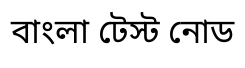

In [ ]:
from IPython.display import display
display(_label_image("বাংলা টেস্ট নোড"))

##7.Final Orchestration

Verification Status: NO
[INFO] New event -- extracting triples for KG ingestion...
[INFO] ChromaDB updated: ART_e8eb29a6
[Retrain Monitor] 6/100 new articles ingested.


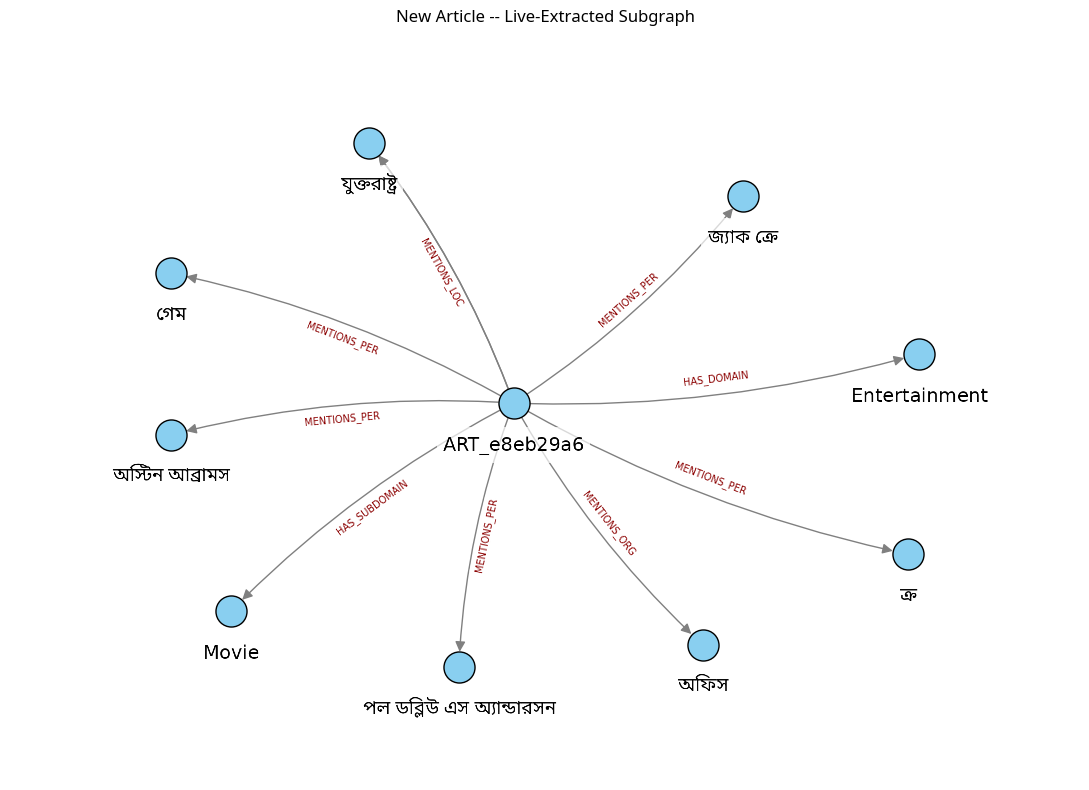

In [ ]:
if 'incoming_ques' in locals() and 'results' in locals():
    top_match_id = results['ids'][0][0] if results['ids'] else None
    top_match_text = results['documents'][0][0] if results['documents'] else ""

    # 1. Verify with Try-Except Fallback
    try:
        verif = verify_duplicate_event(incoming_ques, top_match_text)
        if 'error' in verif:
            print(f"[WARN] Gemini API Failed (Quota/Network). Treating as a NEW article for safety. Error: {verif['error']}")
            verif = {'same_news': 'NO'}
    except Exception as e:
        print(f"[WARN] Verification process encountered an exception: {e}. Treating as a NEW article.")
        verif = {'same_news': 'NO'}

    print(f"Verification Status: {verif.get('same_news')}")

    # 2. Route
    sub_g = handle_new_article(incoming_ques, verif, matched_article_id=top_match_id)

    # 3. Visualize
    if sub_g.number_of_nodes() > 0:
        title = ("Existing Article -- Trained KG Subgraph"
                  if verif.get('same_news') == 'YES'
                  else "New Article -- Live-Extracted Subgraph")
        visualize_subgraph(sub_g, title=title)
    else:
        print(f"[KG] No nodes to show for match ID: {top_match_id}")
else:
    print("Error: Search results or query not found. Age retrieval cell run koro.")

#Removing Ingested Nodes

In [ ]:
# import networkx as nx

# # গ্রাফের বর্তমান অবস্থা বিশ্লেষণ
# total_nodes = G.number_of_nodes()
# total_edges = G.number_of_edges()

# # নতুন ইনজেস্ট করা আর্টিক্যালগুলোর সংখ্যা দেখা (যেগুলো UUID দিয়ে শুরু হয়েছে)
# new_ingested_articles = [n for n in G.nodes() if str(n).startswith('ART_') and len(str(n)) > 10]
# original_articles = [n for n in G.nodes() if str(n).startswith('ART_') and len(str(n)) <= 10]

# print(f"--- Knowledge Graph Statistics ---")
# print(f"মোট নোড সংখ্যা: {total_nodes}")
# print(f"মোট রিলেশন (Edges) সংখ্যা: {total_edges}")
# print(f"পুরানো আর্টিক্যাল নোড: {len(original_articles)}")
# print(f"নতুন ডাইনামিকালি ইনজেস্ট করা নোড: {len(new_ingested_articles)}")

# if new_ingested_articles:
#     print(f"\nসর্বশেষ ইনজেস্ট করা নোড আইডি: {new_ingested_articles[-1]}")

In [ ]:
# import pickle
# import os

# # ১. ডাইনামিক নোডগুলো চিহ্নিত করা (length > 10)
# new_ingested_nodes = [n for n in G.nodes() if str(n).startswith('ART_') and len(str(n)) > 10]

# # ২. সর্বশেষ ৬টি নোড সিলেক্ট করা (যদি থাকে)
# nodes_to_remove = new_ingested_nodes[-6:]

# print(f"মুছে ফেলার জন্য নির্ধারিত নোডসমূহ: {nodes_to_remove}")

# # ৩. গ্রাফ থেকে নোডগুলো মুছে ফেলা
# for node in nodes_to_remove:
#     if G.has_node(node):
#         G.remove_node(node)
#         print(f"Node {node} removed.")

# # ৪. পরিবর্তিত গ্রাফটি ডিস্কে সেভ করা
# with open(KG_GRAPH_PATH, 'wb') as f:
#     pickle.dump(G, f)

# print(f"\nগ্রাফ আপডেট করা হয়েছে। বর্তমান নোড সংখ্যা: {G.number_of_nodes()}")

# # ৫. ইনজেশন কাউন্টার রিসেট করা (ঐচ্ছিক, ট্র্যাকিং ঠিক রাখার জন্য)
# if os.path.exists(COUNTER_PATH):
#     with open(COUNTER_PATH, 'w') as f:
#         import json
#         json.dump({"count": 0}, f)
#     print("Ingestion counter reset to 0.")

### Analyze Similarity Score Distribution

To determine an optimal similarity threshold, it's helpful to visualize the distribution of similarity scores across your dataset. This section will:

1. Select a few random documents from your DataFrame (`df`) to act as sample 'queries'.
2. Calculate the cosine similarity of each sample 'query' against all other documents in the dataset.
3. Plot a histogram and Kernel Density Estimate (KDE) of these similarity scores to show their distribution.

<a name="eval"></a>
### 8. Evaluation & Diagnostics

Calculating similarities for 50 sample queries...
Total similarity scores collected: 538050


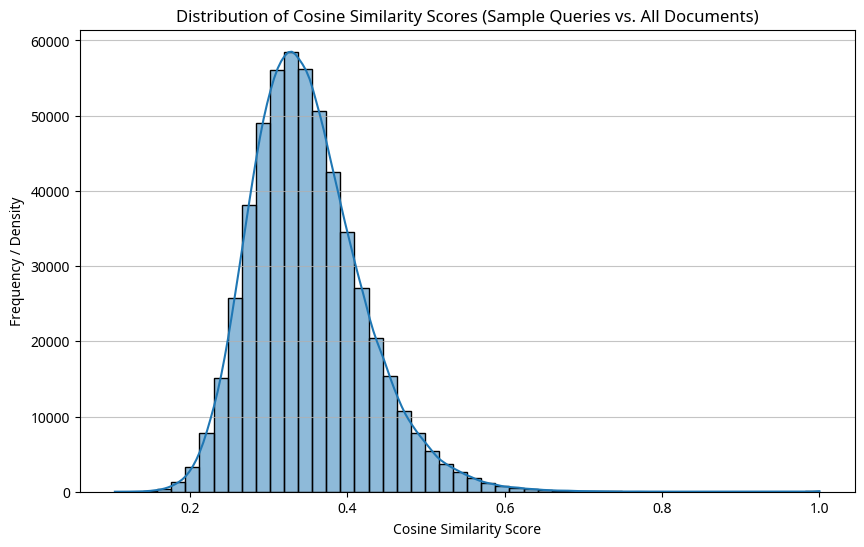


Based on this distribution, you can observe where most of your relevant and irrelevant scores fall to help decide on a threshold. For example, if you see a clear drop-off or gap, that might be a good candidate for your threshold.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Assuming 'df' and 'vectors' (or 'document_embeddings') are already defined and loaded
# from previous cells.
# 'document_embeddings' was defined in cell 'f69379ab'

# If document_embeddings is not yet defined, create it from vectors
if 'document_embeddings' not in locals() or document_embeddings is None:
    document_embeddings = np.array(vectors)

# Number of random documents to use as sample queries
num_sample_queries = 50 # Let's pick 50 random documents as queries for a good sample

# Get random indices for sample queries
random_indices = np.random.choice(len(df), num_sample_queries, replace=False)

all_similarities = []

print(f"Calculating similarities for {num_sample_queries} sample queries...")

for idx in random_indices:
    # Get the embedding for the current sample document (acting as a query)
    sample_query_embedding = document_embeddings[idx].reshape(1, -1)

    # Calculate similarities against all documents in the dataset
    # Exclude self-similarity if desired, or keep it as it's typically 1.0
    similarities = cosine_similarity(sample_query_embedding, document_embeddings)[0]

    # Add all similarities to the list, potentially excluding the self-similarity
    # For distribution, including it is fine, but for thresholding, we might want to see how queries relate to *other* documents.
    # Let's include all for a general distribution view.
    all_similarities.extend(similarities.tolist())

print(f"Total similarity scores collected: {len(all_similarities)}")

# Plot the distribution
fig = plt.figure(figsize=(10, 6))
sns.histplot(all_similarities, bins=50, kde=True)
plt.title('Distribution of Cosine Similarity Scores (Sample Queries vs. All Documents)')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Frequency / Density')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nBased on this distribution, you can observe where most of your relevant and irrelevant scores fall to help decide on a threshold. For example, if you see a clear drop-off or gap, that might be a good candidate for your threshold.")

### Searching at the Segment Level
To show multiple matches from the same file, we will now embed every individual segment separately rather than grouping them by filename.

In [ ]:
import numpy as np
import pandas as pd

# 1. Create the segment DataFrame from existing data
all_segments = []
for idx, row in df.head(len(vectors)).iterrows():
    all_segments.append({
        'original_index': idx,
        'Language': row['Language'],
        'text': row['Text'],
        'domain': row['Domain'],     # Added 'Domain' column
        'sub-domain': row['Sub-Domain'] # Added 'Sub-Domain' column
    })

segment_df = pd.DataFrame(all_segments)

# 2. Re-use existing vectors instead of re-embedding everything
# This avoids the 'ResponseError' caused by sending too much data at once
if 'vectors' in locals() and len(vectors) == len(segment_df):
    print("Re-using existing pre-computed vectors...")
    # Convert list of vectors to a numpy array for similarity calculations
    # Filtering out any potential None values from failed rows
    valid_vectors = [v if v is not None else [0]*1024 for v in vectors]
    seg_vectors = np.array(valid_vectors)
else:
    print("Existing vectors not found or size mismatch. Embedding in batches...")
    # Fallback: Batch processing to prevent connection errors
    batch_size = 32
    all_embs = []
    for i in range(0, len(segment_df), batch_size):
        batch_text = segment_df['text'].iloc[i:i+batch_size].tolist()
        res = ollama.embed(model='bge-m3', input=batch_text)
        all_embs.extend(res['embeddings'])
    seg_vectors = np.array(all_embs)

print(f"Total individual segments ready for search: {len(seg_vectors)}")

Re-using existing pre-computed vectors...
Total individual segments ready for search: 10761


Now we can perform a search that returns specific parts of a file, even multiple times from the same source.

In [ ]:
# Reshape query for similarity calculation
query_vec = np.array(query_embedding).reshape(1, -1)

# Calculate similarities
# We use seg_vectors which was generated in the previous cell
seg_similarities = cosine_similarity(query_vec, seg_vectors)[0]

# Add scores to our segment dataframe
segment_df['similarity_score'] = seg_similarities

# Sort and show top 10 results
# We display 'Language' and 'text' since 'filename' is not present in the data
top_segments = segment_df.sort_values(by='similarity_score', ascending=False).head(10)

print(f"Query: {incoming_ques[:100]}...")
display(top_segments[['Language', 'text','domain','sub-domain','similarity_score']])

Query: 
‘ব্যাকরুমস’ থেকে ‘অবসেশন’—চলতি বছর বক্স অফিসে সাফল্য পেয়েছে একের পর এক হরর সিনেমা। সম্ভবত সেই তালিক...


,Language,text,domain,sub-domain,similarity_score
7849,bn,মুক্তির পর থেকে আলোচনায় এই সিরিজ। ৮.৬ রেটিং নি...,বিনোদন,সিনেমা,0.666262
2156,bn,নতুন বছরে বক্স অফিসে শক্ত অবস্থান ধরে রেখেছে ‘...,বিনোদন,সিনেমা,0.663281
1285,bn,মুক্তির পর থেকে আলোচনায় এই সিরিজ। ৮.৬ রেটিং নি...,বিনোদন,সিনেমা,0.656144
8950,bn,বিশ্বব্যাপী মুক্তির মাত্র ১৮ দিনের মাথায় ১ বি...,বিনোদন,সিনেমা,0.642728
9866,bn,প্রতিবছর সারা দুনিয়ায় নানা ধরনের সিনেমা হয়। তব...,বিনোদন,সিনেমা,0.636556
5375,bn,প্রেক্ষাগৃহে ‘সিনার্স’ মুক্তি পায় গত ১৭ এপ্রিল...,বিনোদন,সিনেমা,0.632964
1716,bn,বিশ্বব্যাপী মুক্তির মাত্র ১৮ দিনের মাথায় ১ বি...,বিনোদন,সিনেমা,0.628009
2155,bn,১. থান্ডারবোল্টস*বিশ্বব্যাপী প্রায় ৪০০ মিলিয়ন ...,বিনোদন,সিনেমা,0.627382
4816,bn,ক্রিস্টোফার নোলানের ‘ওপেনহাইমার’–এর সঙ্গে আপনা...,বিনোদন,সিনেমা,0.624002
719,bn,"বড় তারকার উপস্থিতি, আলোচিত ফ্র্যাঞ্চাইজির নতুন...",বিনোদন,সিনেমা,0.623611


#

In [ ]:
def get_summary_context(incoming_ques, fallback_top_k=5):
    """LAST_NEW_ARTICLE_RETRIEVAL_DF ekhono current incoming_ques-er kina check kore,
    na hole stale bole dhore fallback kore -- Llama/Qwen/mT5 shob jaygay eki logic."""
    if (
        'LAST_NEW_ARTICLE_RETRIEVAL_DF' in globals()
        and not LAST_NEW_ARTICLE_RETRIEVAL_DF.empty
        and 'LAST_NEW_ARTICLE_TEXT' in globals()
        and LAST_NEW_ARTICLE_TEXT == incoming_ques
    ):
        return LAST_NEW_ARTICLE_RETRIEVAL_DF, 1

    if 'LAST_NEW_ARTICLE_RETRIEVAL_DF' in globals() and not LAST_NEW_ARTICLE_RETRIEVAL_DF.empty:
        print("[WARN] LAST_NEW_ARTICLE_RETRIEVAL_DF stale -- eta age-r query-r data. "
              "Cell 84 (Final Orchestration) notun incoming_ques diye abar run koro.")

    if 'top_segments' in globals() and not top_segments.empty:
        return top_segments, fallback_top_k

    return pd.DataFrame(), 1

#Llama 3.1:8b Summarizing Search Results with

In [ ]:
import ollama
import re

def summarize_with_llama31(query, results_df, model='llama3.1:8b', top_k=5):

    top_k_df = results_df.head(top_k)
    text_col = 'Text' if 'Text' in top_k_df.columns else 'text'

    # 1. Dominant language detect
    if 'Language' in top_k_df.columns:
        dominant_lang = top_k_df['Language'].mode()[0]
    else:
        sample_text = " ".join(top_k_df[text_col].astype(str).tolist())
        bn_chars = len(re.findall(r'[\u0980-\u09FF]', sample_text))
        en_chars  = len(re.findall(r'[a-zA-Z]', sample_text))
        dominant_lang = 'bn' if bn_chars > en_chars else 'en'

    lang_name = "Bengali" if dominant_lang == 'bn' else "English"
    print(f"Target Language for Summary: {lang_name}")

    # 2. Context তৈরি
    context_chunks = top_k_df[text_col].astype(str).tolist()
    context = "\n\n---\n\n".join([
        f"Article {i+1}:\n{text[:1200]}"
        for i, text in enumerate(context_chunks)
    ])

    # 3. Language-specific prompt
    if dominant_lang == 'bn':
        prompt = f"""তুমি একজন পেশাদার বাংলা সংবাদ সম্পাদক এবং তথ্যনির্ভর সংবাদ সারসংক্ষেপকারী।

নিচের সংবাদ নিবন্ধগুলো মনোযোগ দিয়ে পড়ো এবং ব্যবহারকারীর প্রশ্নের ভিত্তিতে একটি সংক্ষিপ্ত, নির্ভুল ও প্রাসঙ্গিক সারসংক্ষেপ তৈরি করো।

ব্যবহারকারীর প্রশ্ন:
"{query}"

সংবাদ নিবন্ধসমূহ:
{context}

নির্দেশনাবলী:
- অবশ্যই ৪ থেকে ৫টি পূর্ণাঙ্গ বাক্যে সারসংক্ষেপ লিখবে।
- ব্যবহারকারীর প্রশ্নের সঙ্গে সরাসরি সম্পর্কিত তথ্যকে অগ্রাধিকার দেবে।
- সংবাদটির মূল ঘটনা এবং সবচেয়ে গুরুত্বপূর্ণ তথ্যগুলো সংক্ষেপে তুলে ধরবে।
- গুরুত্বপূর্ণ ব্যক্তি, প্রতিষ্ঠান, স্থান, তারিখ, সংখ্যা ও পরিসংখ্যান থাকলে সেগুলো সঠিকভাবে উল্লেখ করবে।
- শুধুমাত্র প্রদত্ত সংবাদ নিবন্ধগুলোতে থাকা তথ্য ব্যবহার করবে।
- নিবন্ধগুলোতে নেই এমন কোনো তথ্য, ঘটনা, কারণ, মতামত বা ভবিষ্যৎ ফলাফল নিজে থেকে যোগ করবে না।
- কোনো তথ্য অনুমান করে লিখবে না।
- কোনো গুরুত্বপূর্ণ তথ্য সম্পর্কে নিশ্চিত না হলে তা তৈরি করে লিখবে না।
- নিবন্ধে Action Item বা করণীয় স্পষ্টভাবে উল্লেখ না থাকলে নিজে থেকে কোনো করণীয় তৈরি করবে না।
- একই তথ্য একাধিকবার পুনরাবৃত্তি করবে না।
- ভাষা হবে স্বাভাবিক, পরিষ্কার এবং সংক্ষিপ্ত বাংলা।
- কোনো শিরোনাম, ভূমিকা, ব্যাখ্যা বা অতিরিক্ত মন্তব্য লিখবে না।
- শুধুমাত্র চূড়ান্ত সারসংক্ষেপটি প্রদান করবে।

বাংলায় সারসংক্ষেপ:"""

    else:
        prompt = f"""You are a professional news editor and factual news summarization system.

Read the following news articles carefully and generate a concise, accurate, and relevant summary based on the user's query.

User's Query:
"{query}"

News Articles:
{context}

Rules:
- Write exactly 4 to 5 complete sentences.
- Prioritize information that is directly relevant to the user's query.
- Clearly summarize the main event and the most important facts.
- Preserve important names, organizations, locations, dates, numbers, and statistics accurately.
- Use only information explicitly supported by the provided news articles.
- Do not add any information, event, cause, opinion, prediction, or conclusion that is not supported by the articles.
- Do not make assumptions or guesses.
- If a fact is uncertain or conflicting in the articles, do not invent a resolution.
- Do not create action items unless they are explicitly mentioned in the articles.
- Avoid repeating the same information.
- Use clear, natural, concise English.
- Do not include a title, introduction, explanation, or additional commentary.
- Return only the final summary.

Summary in English:"""

    # 4. LLaMA call — settings tuned: low temp=faithful, repeat_penalty=1.15 (Bengali repeat-loop prone), stop tokens block context echo
    response = ollama.generate(
        model=model,
        prompt=prompt,
        options={
          'num_ctx': 8192,
          'temperature': 0.2,
          'top_p': 0.85,
          'top_k': 40,
          'repeat_penalty': 1.15,
          'num_predict': 350,
          'seed': 42,
          'stop': ['\n\n---', 'Article']
          }
    )
    return response['response']

# Run
context_df, tk = get_summary_context(incoming_ques)
if not context_df.empty:
    print("Generating Llama-3.1:8b summary...")
    summary_llama31 = summarize_with_llama31(incoming_ques, context_df, top_k=tk)
else:
    summary_llama31 = None
    print("Please run search/ingestion cell (84) first.")

if summary_llama31:
    print("\n=== Llama 3.1:8b Summary ===\n")
    print(summary_llama31)

Generating Llama-3.1:8b summary...
Target Language for Summary: Bengali

=== Llama 3.1:8b Summary ===

‘রেসিডেন্ট এভিল’-এর নতুন কিস্তি ৮৮ লাখ ডলার আয় করেছে। যা ‘রেসিদেন্ট এভিল’-এর ফ্র্যাঞ্চাইজির প্রিভিউ থেকে আয় করা সর্বোচ্চ। নির্মাতা জ্যাক ক্রেগারের এই হরর সিনেমাটি ৭ কোটি ৫০ লাখ ডলার বাজেটে তৈরি। ‘রেসিডেন্ট এভিল’-এর নতুন কিস্তি ১৯৯৬ সালে শুরু হওয়া ফ্র্যাঞ্চাইজির প্রথম নতুন কিস্তি। 

‘রেসিডেন্ট এভিল’-এর ন


#Gemini 3.6 Flash API

In [ ]:
# import json
# import re
# import time
# import random
# from google.genai import types


# def summarize_with_gemini(
#     results_df,               # FIX: raw text na, DataFrame -- ekhon exact article summarize hobe
#     query=None,
#     top_k=1,                  # FIX: pipeline-e already exact single article (matched/new) thake
#     num_sentences=4,
#     force_lang=None,
#     model="gemini-3.6-flash",
#     max_retries=4,
# ):
#     """
#     Summarize Bengali / English / mixed-language news text with Gemini.
#     results_df: DataFrame with 'Text'/'text' column (from get_article_by_id / retrieval).
#     Returns dict: {"language": "bn"|"en"|"mixed", "summary": "...", "key_points": [...]}
#     """
#     if client is None:
#         return {"error": "Client not initialized. Check API Key."}

#     if results_df is None or results_df.empty:
#         return {"error": "No article text provided -- results_df empty."}

#     top_k_df = results_df.head(top_k)
#     text_col = 'Text' if 'Text' in top_k_df.columns else 'text'
#     text = "\n\n".join(top_k_df[text_col].astype(str).tolist())

#     if force_lang not in (None, 'bn', 'en'):
#         force_lang = None   # FIX: invalid value hole age English-e fixed hoye jeto, ekhon auto-detect fallback

#     lang_instruction = (
#         f"Write the summary in {'Bengali' if force_lang == 'bn' else 'English'}."
#         if force_lang else
#         "Detect the dominant language of the input (Bengali or English). "
#         "Write the summary in that SAME dominant language. "
#         "If the input is genuinely mixed with no dominant language, summarize in Bengali."
#     )

#     query_line = (
#         f'\nUser query for context (do NOT summarize this line, only the article below): "{query}"\n'
#         if query else ""
#     )

#     prompt = f"""
# You are a professional multilingual news summarizer for Bengali and English news.

# The input text may be:
# - Pure Bengali (বাংলা)
# - Pure English
# - Code-mixed Bengali-English (common in Bangladeshi news/social text)

# {lang_instruction}
# {query_line}
# RULES:
# - Do NOT translate the content into a different language than instructed above.
# - Do NOT invent facts, numbers, names, or dates not present in the input.
# - Preserve proper nouns (names, organizations, places) exactly as written in the input.
# - Be factual and neutral -- no opinions, no added commentary.
# - Summary should be exactly {num_sentences} sentences, capturing WHO, WHAT, WHERE, WHEN, WHY if available.
# - Also extract 3-5 short key points (bullet-style facts), in the same language as the summary.

# ========================
# INPUT TEXT
# ========================
# {text}

# ========================
# OUTPUT FORMAT
# ========================
# Return ONLY valid JSON, no markdown, no explanation:
# {{
#   "language": "bn" | "en" | "mixed",
#   "summary": "...",
#   "key_points": ["...", "...", "..."]
# }}
# """

#     for attempt in range(max_retries + 1):
#         raw = None
#         try:
#             response = client.models.generate_content(
#                 model=model,
#                 contents=prompt,
#                 config=types.GenerateContentConfig(
#                     response_mime_type="application/json",
#                     temperature=0.2,
#                 ),
#             )
#             raw = response.text.strip()
#             raw = re.sub(r"^```(json)?|```$", "", raw, flags=re.MULTILINE).strip()
#             return json.loads(raw)

#         except json.JSONDecodeError as e:
#             # FIX: age immediately return hoye jeto -- ekhon retry loop-e dhuke abar try kore
#             if attempt < max_retries:
#                 print(f"[RETRY] JSON parse failed -- attempt {attempt + 1}/{max_retries}, retrying...")
#                 time.sleep(1)
#                 continue
#             return {"error": f"JSON parse failed: {e}", "raw": raw}

#         except Exception as e:
#             err_str = str(e)
#             transient = any(tag in err_str for tag in ("503", "UNAVAILABLE", "429", "RESOURCE_EXHAUSTED"))
#             if transient and attempt < max_retries:
#                 wait = min(2 ** attempt, 30) + random.uniform(0, 1)
#                 print(f"[RETRY] Gemini overloaded -- attempt {attempt + 1}/{max_retries}, waiting {wait:.1f}s...")
#                 time.sleep(wait)
#                 continue
#             return {"error": err_str}

#     return {"error": "Max retries exhausted."}


# # Usage: exact matched/new article (1-row df) summarize -- query context hishebe pathano hocche, summarize hocche na
# if 'LAST_NEW_ARTICLE_RETRIEVAL_DF' in locals() and not LAST_NEW_ARTICLE_RETRIEVAL_DF.empty:
#     result = summarize_with_gemini(LAST_NEW_ARTICLE_RETRIEVAL_DF, query=incoming_ques, num_sentences=4)
# elif 'top_segments' in locals() and not top_segments.empty:
#     result = summarize_with_gemini(top_segments, query=incoming_ques, num_sentences=4)
# else:
#     result = {"error": "No article/context available -- run search/ingestion cell first."}

# if "error" in result:
#     print(f"Error occurred during summarization: {result['error']}")
#     if "raw" in result:
#         print(f"Raw response: {result['raw']}")
# else:
#     print(result["summary"])
#     print(result["key_points"])

# # যুক্তরাষ্ট্রের গ্রীষ্মকালীন বক্স অফিসে ১ মে থেকে ৭ সেপ্টেম্বর পর্যন্ত রেকর্ড ৪ দশমিক ৭৬ বিলিয়ন ডলার আয় হয়েছে, যা ২০১৩ সালের সর্বোচ্চ রেকর্ডকে পেছনে ফেলেছে। ইতিহাসে প্রথমবারের মতো এই মৌসুমে মে থেকে আগস্ট পর্যন্ত টানা চার মাসের প্রতিটিতেই আয় ১ বিলিয়ন ডলার অতিক্রম করেছে। ফ্র্যাঞ্চাইজিভিত্তিক সিনেমা যেমন সনির মার্ভেল ছবি ‘স্পাইডার–ম্যান: ব্র্যান্ড নিউ ডে’ এবং ক্রিস্টোফার নোলানের ‘দ্য অডিসি’ এই রেকর্ড আয়ে সবচেয়ে বড় ভূমিকা রেখেছে। তবে ডিজনির লাইভ–অ্যাকশন ‘মোয়ানা’ ও ডিসির ‘সুপারগার্ল’–এর মতো কিছু বড় বাজেটের ছবি প্রত্যাশিত ব্যবসা করতে পারেনি।
# # ['গ্রীষ্মকালীন বক্স অফিসে সর্বকালের রেকর্ড ৪.৭৬ বিলিয়ন ডলার আয় হয়েছে।', 'ইতিহাসে প্রথমবার মে থেকে আগস্ট পর্যন্ত টানা চার মাসের প্রতিটিতেই আয় ১ বিলিয়ন ডলার ছাড়িয়েছে।', '‘স্পাইডার–ম্যান: ব্র্যান্ড নিউ ডে’ বিশ্বব্যাপী প্রায় ২.৪ বিলিয়ন ডলার আয় করে শীর্ষে রয়েছে।', 'ক্রিস্টোফার নোলানের ‘দ্য অডিসি’ বিশ্বব্যাপী ১.৬২ বিলিয়ন ডলার আয় করেছে।']

#Llama 3.2 Summarizing Search Results with

This cell takes the top results from your search, constructs a prompt including all retrieved context, and uses the `llama3.2:3b` model to generate a concise summary.

In [ ]:
import ollama
import re

def summarize_with_llama32(query, results_df, model='llama3.2:3b', top_k=5):

    top_k_df = results_df.head(top_k)                              # FIX: top_k param, blind 5 na
    text_col = 'Text' if 'Text' in top_k_df.columns else 'text'     # FIX: column-casing fallback

    # 1. Dominant language detect
    if 'Language' in top_k_df.columns:
        dominant_lang = top_k_df['Language'].mode()[0]
    else:
        sample_text = " ".join(top_k_df[text_col].astype(str).tolist())
        bn_chars = len(re.findall(r'[\u0980-\u09FF]', sample_text))
        en_chars  = len(re.findall(r'[a-zA-Z]', sample_text))
        dominant_lang = 'bn' if bn_chars > en_chars else 'en'

    lang_name = "Bengali" if dominant_lang == 'bn' else "English"
    print(f"Target Language for Summary: {lang_name}")

    # 2. Context তৈরি
    context_chunks = top_k_df[text_col].astype(str).tolist()
    context = "\n\n---\n\n".join([
        f"Article {i+1}:\n{text[:1200]}"
        for i, text in enumerate(context_chunks)
    ])

    # 3. Language-specific prompt
    if dominant_lang == 'bn':
        prompt = f"""তুমি একজন দক্ষ বাংলা সংবাদ সম্পাদক।
নিচের সংবাদ নিবন্ধগুলো পড়ো এবং ব্যবহারকারীর প্রশ্নের ওপর ভিত্তি করে একটি চমৎকার সারসংক্ষেপ লেখো।

ব্যবহারকারীর প্রশ্ন: "{query}"

সংবাদ নিবন্ধসমূহ:
{context}

নির্দেশনাবলী:
- অবশ্যই কমপক্ষে ৪টি এবং সর্বোচ্চ ৫টি পূর্ণ বাক্যে সারসংক্ষেপ লিখবে।
- ব্যবহারকারীর প্রশ্নের সঠিক উত্তর দেওয়ার চেষ্টা করবে।
- শুধু নিবন্ধে যা আছে তাই লিখবে, নিজে থেকে কিছু বানিয়ে লিখবে না।
- তথ্য, নাম, সংখ্যা এবং তারিখ যেন সঠিক থাকে।

বাংলায় সারসংক্ষেপ:"""
    else:
        prompt = f"""You are a professional news editor.
Read the following news articles and write an excellent summary based on the user's query.

User's Query: "{query}"

News Articles:
{context}

Rules:
- Write exactly 4 to 5 complete sentences.
- Focus on answering the user's query.
- Only include information from the articles — do not add anything new.
- Keep names, numbers, and dates accurate.

Summary in English:"""

    # 4. LLaMA call — settings tuned: low temp=faithful, repeat_penalty=1.15 (Bengali repeat-loop prone), stop tokens block context echo
    response = ollama.generate(
        model=model,
        prompt=prompt,
        options={
          'num_ctx': 8192,
          'temperature': 0.3,
          'top_p': 0.85,
          'top_k': 40,
          'repeat_penalty': 1.15,
          'num_predict': 350,
          'seed': 42,
          'stop': ['\n\n---', 'Article']
          }
    )
    return response['response']

# Run
context_df, tk = get_summary_context(incoming_ques)
if not context_df.empty:
    print("Generating Llama-3.2:3b summary...")
    summary_llama32 = summarize_with_llama32(incoming_ques, context_df, top_k=tk)
else:
    summary_llama32 = None
    print("Please run search/ingestion cell (84) first.")

if summary_llama32:
    print("\n=== Llama 3.2:3b Summary ===\n")
    print(summary_llama32)

Generating Llama-3.2:3b summary...
Target Language for Summary: Bengali

=== Llama 3.2:3b Summary ===

‘রেসিডেন্ট এভিল’-এর নতুন কিস্তি ‘ব্যাকরুমস’ থেকে ‘অবসেশন’—চলতি বছর বক্স অফিসে সাফল্য পেয়েছে। নির্মাতা জ্যাক ক্রেগারের এই নতুন হরর সিনেমাটি ভিডিও গেম অবলম্বনে তৈরি। প্রিভিউ প্রদর্শনী থেকেই ৮৮ লাখ ডলার আয় করেছে।


#Qwen 2.5:14b

In [ ]:
# Paste into Colab cell 104 (replaces old Qwen cell).
import ollama
import re
import subprocess

QWEN_MODEL = 'qwen2.5:14b'   # Ollama tag qwen2.5:14b IS the instruct model. No separate download.

# Pull only if model is missing from the Ollama store (Drive-backed OLLAMA_MODELS)
try:
    ollama.show(QWEN_MODEL)
    print(f"{QWEN_MODEL} found in Ollama store.")
except Exception:
    print(f"{QWEN_MODEL} not found, pulling...")
    subprocess.run(['ollama', 'pull', QWEN_MODEL], check=True)


def summarize_with_qwen14(query, results_df, model=QWEN_MODEL, top_k=5,
                          max_context_chars=3000, min_chars=60):

    top_k_df = results_df.head(top_k)
    text_col = 'Text' if 'Text' in top_k_df.columns else 'text'

    # 1. Dominant language detect
    if 'Language' in top_k_df.columns:
        dominant_lang = top_k_df['Language'].mode()[0]
    else:
        sample_text = " ".join(top_k_df[text_col].astype(str).tolist())
        bn_chars = len(re.findall(r'[\u0980-\u09FF]', sample_text))
        en_chars = len(re.findall(r'[a-zA-Z]', sample_text))
        dominant_lang = 'bn' if bn_chars > en_chars else 'en'

    lang_name = "Bengali" if dominant_lang == 'bn' else "English"
    print(f"Target Language for Summary: {lang_name}")

    # 2. Context: one fixed char budget split across articles.
    #    Qwen tokenizer spends many tokens per Bengali char, so keep it small.
    context_chunks = top_k_df[text_col].astype(str).tolist()
    per_article = max(800, max_context_chars // max(1, len(context_chunks)))
    context = "\n\n---\n\n".join(
        f"[News {i+1}]\n{text[:per_article]}" for i, text in enumerate(context_chunks)
    )

    # 3. New-article path: query IS the article. Do not paste it twice.
    q = str(query).strip()
    query_is_article = any(q[:200] == t.strip()[:200] for t in context_chunks)
    query_block = "" if query_is_article else f'User query: "{q[:500]}"\n\n'

    # 4. English instructions (cheap tokens, Qwen follows well), output language forced.
    system_msg = (
        "You are a professional news editor and factual summarizer. "
        f"Always write the final summary in {lang_name}."
    )
    user_msg = f"""{query_block}News:
{context}

Rules:
- Write 4 to 5 complete sentences.
- Main event and most important facts first.
- Keep names, organizations, places, dates and numbers exact.
- Use only facts stated in the news. No guesses, no added causes, opinions or predictions.
- Do not repeat the same fact.
- No title, no introduction, no commentary. Output only the summary in {lang_name}."""

    messages = [
        {'role': 'system', 'content': system_msg},
        {'role': 'user', 'content': user_msg},
    ]

    def _call(temperature, seed):
        # FIX: temperature was 2 (Llama cells use 0.2/0.3). Stop list removed
        # (copied from Llama cell; 'Article' can cut the output). num_predict 350 -> 1200.
        r = ollama.chat(
            model=model,
            messages=messages,
            options={
                'num_ctx': 16384,
                'temperature': temperature,
                'top_p': 0.9,
                'top_k': 40,
                'repeat_penalty': 1.05,   # Qwen2.5 official default
                'num_predict': 1200,
                'seed': seed,
            },
        )
        print(f"[debug] prompt_tokens={r.get('prompt_eval_count')} "
              f"out_tokens={r.get('eval_count')} done_reason={r.get('done_reason')}")
        return r['message']['content'].strip()

    text = _call(temperature=0.2, seed=42)

    # Safety net: too-short output = failed generation. Retry once, slightly warmer.
    if len(text) < min_chars:
        print(f"[WARN] output only {len(text)} chars, retrying once...")
        text = _call(temperature=0.4, seed=7)
        if len(text) < min_chars:
            print("[WARN] still too short. Check [debug] line: prompt_tokens near 16384 = overflow "
                  "(lower max_context_chars); done_reason 'length' = raise num_predict.")

    return text


# Run — exact matched/new article priority, top_segments fallback
context_df, tk = get_summary_context(incoming_ques)
if not context_df.empty:
    print("Generating Qwen2.5-14 summary...")
    summary_qwen14 = summarize_with_qwen14(incoming_ques, context_df, top_k=tk)
else:
    summary_qwen14 = None
    print("Please run search/ingestion cell (84) first.")

if summary_qwen14:
    print("\n=== qwen14 Summary ===\n")
    print(summary_qwen14)

qwen2.5:14b not found, pulling...
Generating Qwen2.5-14 summary...
Target Language for Summary: Bengali
[debug] prompt_tokens=2474 out_tokens=424 done_reason=stop

=== qwen14 Summary ===

'রেসিডেন্ট এভিল' ফ্র্যাঞ্চাইজির নতুন কিস্তি 'রেসিডেন্ট এভিল' প্রিভিউ প্রদর্শনী থেকে ৮৮ লাখ ডলার আআইন করেছে। এটি 'রেসিডেন্ট এভিল' ফ্র্যাঞ্চাইজির সর্বোচ্চ প্রিভিউ আআইন এবং জ্যাক ক্রেগারের টানা দ্বিতীয় বড় ওপেনিং। সিনেমাটি ৭ কোটি ৫০ লাখ ডলার বাজেটে তৈরি হয়েছে এবং যুক্তরাষ্ট্রে প্রথম সপ্তাহান্তে চার থেকে পাঁচ কোটি ডলার আআইন করতে পারে। 'ওপেনস' মুক্তির আগে প্রিভিউ থেকে জ্যাক ক্রেগার আআইন করেছিল ৫৭ লাখ ডলার।


#using Mt5 Model.

<a name="summary"></a>
### 7. Summarization Engine

In [ ]:
import re
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

saved_model_path = '/content/drive/MyDrive/ollama_models/mt5-buet'

print("Loading model and tokenizer from Google Drive...")
mt5_tokenizer = AutoTokenizer.from_pretrained(saved_model_path)
mt5_model = AutoModelForSeq2SeqLM.from_pretrained(saved_model_path)
print("Loaded successfully!")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mt5_model = mt5_model.to(device)
mt5_model.eval()
print(f"mT5 loaded on: {device}")

WHITESPACE_HANDLER = lambda text: re.sub(
    r'\s+', ' ', re.sub(r'\n+', ' ', str(text).strip())
)

def summarize_with_mt5(query, results_df, top_k=3, max_input=512, max_new=300, min_new=120):
    """
    max_input=512   -> model original XLSum fine-tune length, mismatch dile quality drop
    max_new=100     -> XLSum concise-summary training-er kachakachi; 350 onek beshi silo
    min_new=25      -> floor set, ekdom short/empty output atkabe
    top_k=3         -> ekta na, kekhane article context-e dhukbe (1 hole retrieval miss = summary miss)
    """
    top_k_df = results_df.head(top_k)
    text_col = 'Text' if 'Text' in top_k_df.columns else 'text'   # FIX: language-detect-o casing fallback lagbe

    if 'Language' in top_k_df.columns:
        dominant_lang = top_k_df['Language'].mode()[0]
    else:
        sample = " ".join(top_k_df[text_col].astype(str).tolist())
        bn = len(re.findall(r'[\u0980-\u09FF]', sample))
        en = len(re.findall(r'[a-zA-Z]', sample))
        dominant_lang = 'bn' if bn > en else 'en'

    lang_name = "Bengali" if dominant_lang == 'bn' else "English"
    print(f"Target Language: {lang_name}")
    print(f"Articles found : {len(top_k_df)}")

    num_articles = max(1, len(top_k_df))
    char_budget = max(300, (max_input * 4) // num_articles)

    combined = ' '.join([
        WHITESPACE_HANDLER(str(row[text_col])[:char_budget])
        for _, row in top_k_df.iterrows()
    ])

    inputs = mt5_tokenizer(
        [combined],
        return_tensors='pt',
        truncation=True,
        max_length=max_input,
        padding=True
    )
    input_ids      = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad(): # Disables gradient calculation, reducing memory consumption and speeding up computation
        output_ids = mt5_model.generate(
            input_ids=input_ids, # Input token IDs to the model
            attention_mask=attention_mask, # Mask to avoid performing attention on padding token indices
            max_new_tokens=max_new, # Maximum number of tokens to generate in the summary
            min_new_tokens=min_new, # Minimum number of tokens to generate in the summary
            no_repeat_ngram_size=3, # Prevents the generation of repeating n-grams of size 3
            repetition_penalty=1.3, # Penalizes repeated tokens, encouraging diversity
            num_beams=4, # Number of beams for beam search, improving summary quality
            early_stopping=True, # Stops generation once all beam hypotheses have finished
            length_penalty=1.2 # Encourages longer summaries
        )[0]

    summary = mt5_tokenizer.decode(
        output_ids,
        skip_special_tokens=True,
        clean_up_token_ization_spaces=False
    )

    print(f"\n{'='*50}")
    print(f"Query   : {str(query)[:80]}...")
    print(f"{'='*50}")
    print(f"Summary :\n{summary}")
    print(f"{'='*50}")
    return summary

# ============================================================
# FIX: stale-check wala get_summary_context() use kora, mT5-er
# nijer variable/function naam-e (age Llama-3.1-er copy-paste chilo)
# ============================================================
context_df, tk = get_summary_context(incoming_ques)
if not context_df.empty:
    print("Generating mT5 summary...")
    summary_mt5 = summarize_with_mt5(incoming_ques, context_df, top_k=tk)
else:
    summary_mt5 = None
    print("Please run search/ingestion cell (84) first.")

if summary_mt5:
    print("\n=== mT5 Summary ===\n")
    print(summary_mt5)

Loading model and tokenizer from Google Drive...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loaded successfully!
mT5 loaded on: cuda
Generating mT5 summary...
Target Language: Bengali
Articles found : 1


[transformers] Both `max_new_tokens` (=300) and `max_length`(=84) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Query   : 
‘ব্যাকরুমস’ থেকে ‘অবসেশন’—চলতি বছর বক্স অফিসে সাফল্য পেয়েছে একের পর এক হরর সিনে...
Summary :
চলতি বছর বক্স অফিসে সাফল্য পেয়েছে একের পর এক হরর সিনেমা। এমনকি গত বছরের ‘ব্যাকরুমস’ থেকে ‘অবসেশন’—এর নতুন কিস্তিও মুক্তি পেয়েছে। কিন্তু এখন পর্যন্ত আয় করেছে প্রায় ৮৮ লাখ ডলার। যার পরিমাণ Kuni. (বাংলাদেশে বিক্রি হচ্ছে ১০৮ কোটি টাকা), আর বাংলাদেশে আয় করতে যাচ্ছে সবচেয়ে বড় ওপেনিং,

=== mT5 Summary ===

চলতি বছর বক্স অফিসে সাফল্য পেয়েছে একের পর এক হরর সিনেমা। এমনকি গত বছরের ‘ব্যাকরুমস’ থেকে ‘অবসেশন’—এর নতুন কিস্তিও মুক্তি পেয়েছে। কিন্তু এখন পর্যন্ত আয় করেছে প্রায় ৮৮ লাখ ডলার। যার পরিমাণ Kuni. (বাংলাদেশে বিক্রি হচ্ছে ১০৮ কোটি টাকা), আর বাংলাদেশে আয় করতে যাচ্ছে সবচেয়ে বড় ওপেনিং,


In [ ]:
def smart_summary_pipeline(query, search_results, threshold=0.5):
    # ১. চেক করা হচ্ছে টপ রেজাল্টের স্কোর থ্রেশহোল্ডের উপরে কি না
    if not search_results.empty and search_results.iloc[0]['similarity_score'] >= threshold:
        print(f"Relevant news found (Score: {search_results.iloc[0]['similarity_score']:.2f}). Summarizing results...")
        # সার্চ রেজাল্ট থেকে সামারি
        return summarize_with_mt5(query, search_results)
    else:
        print(f"No highly relevant news found (Score < {threshold}). Summarizing input query directly...")
        # সরাসরি ইনপুট নিউজ (query) সামারি করা
        # একটি ছোট 'dummy' ডাটাফ্রেম তৈরি করা হচ্ছে যাতে ফাংশনটি কাজ করে
        input_df = pd.DataFrame({'Text': [query], 'Language': ['bn']})
        return summarize_with_mt5(query, input_df)

# --- Execution ---
if 'top_results' in locals():
    final_output = smart_summary_pipeline(incoming_ques, top_results, threshold=0.5)
else:
    print("আগে সার্চ সেলটি রান করুন।")

আগে সার্চ সেলটি রান করুন।


### 🔧 FIX (V7): ChromaDB-Retrieved Summarization for the Newly Ingested Article
এখানে mT5 (ও `smart_summary_pipeline`) লোড হয়ে গেছে, তাই এখন উপরে `handle_new_article()`-এ সেট করা `LAST_NEW_ARTICLE_RETRIEVAL_DF` (ChromaDB থেকে retrieve করা) **অপরিবর্তিত** `smart_summary_pipeline()`-এ পাস করে ফাইনাল সামারি বানানো হচ্ছে। যদি সর্বশেষ ইনজেশন duplicate/same-news হয়ে থাকে, এই ধাপ স্কিপ হবে (সেক্ষেত্রে আগের KG-subgraph আউটপুটই যথেষ্ট, নতুন কিছু করার নেই)।

In [ ]:
# ==================== NEW: Final Summarization for Newly Ingested Article (ChromaDB-driven) ====================
if 'LAST_INGESTION_WAS_NEW' in globals() and LAST_INGESTION_WAS_NEW:
    if not LAST_NEW_ARTICLE_RETRIEVAL_DF.empty:
        print("[INFO] নতুন article ChromaDB-তে আপডেট হয়েছে — retrieved context থেকে সামারি বানানো হচ্ছে।")
        final_summary_new_article = smart_summary_pipeline(
            LAST_NEW_ARTICLE_TEXT, LAST_NEW_ARTICLE_RETRIEVAL_DF, threshold=0.5
        )
    else:
        print("[WARN] নতুন article ইনজেস্ট হয়েছে কিন্তু ChromaDB retrieval খালি এসেছে -- collection/where filter চেক করো।")
else:
    print("[INFO] সর্বশেষ ইনজেশন 'duplicate/same news' ছিল -- এই ChromaDB-summarization ধাপ স্কিপ হচ্ছে (KG subgraph আগেই দেখানো হয়েছে)।")
# ==================== END NEW ====================


[transformers] Both `max_new_tokens` (=300) and `max_length`(=84) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] নতুন article ChromaDB-তে আপডেট হয়েছে — retrieved context থেকে সামারি বানানো হচ্ছে।
Relevant news found (Score: 1.00). Summarizing results...
Target Language: Bengali
Articles found : 1

Query   : 
‘ব্যাকরুমস’ থেকে ‘অবসেশন’—চলতি বছর বক্স অফিসে সাফল্য পেয়েছে একের পর এক হরর সিনে...
Summary :
চলতি বছর বক্স অফিসে সাফল্য পেয়েছে একের পর এক হরর সিনেমা। এমনকি গত বছরের ‘ব্যাকরুমস’ থেকে ‘অবসেশন’—এর নতুন কিস্তিও মুক্তি পেয়েছে। কিন্তু এখন পর্যন্ত আয় করেছে প্রায় ৮৮ লাখ ডলার। যার পরিমাণ Kuni. (বাংলাদেশে বিক্রি হচ্ছে ১০৮ কোটি টাকা), আর বাংলাদেশে আয় করতে যাচ্ছে সবচেয়ে বড় ওপেনিং,


#Metrices

### Hallucination Rate Analysis
হ্যালুসিনেশন রেট সাধারণত NLI (Natural Language Inference) মডেল ব্যবহার করে বের করা হয়, যেখানে দেখা হয় সামারির তথ্যগুলো মূল টেক্সট দ্বারা সমর্থিত কি না। উপরে প্রাপ্ত ROUGE-L এবং BERTScore-এর মান যত কম হবে, হ্যালুসিনেশনের সম্ভাবনা তত বেশি বলে ধরে নেওয়া যায়।

In [ ]:
# ============================================================
# RAG SUMMARIZATION EVALUATION  --  v2 (no NaN, all models)
# ------------------------------------------------------------
# FIXES vs previous cell
# 1. Llama-3.1 / Llama-3.2 were "Failed": `summarize_results` does not exist.
#    Now calls the real functions (summarize_with_llama31 / _llama32).
# 2. ROUGE / BERTScore were NaN: there are no human reference summaries.
#    Now ALWAYS computed: grounding metrics vs the evidence + NLI support.
#    Reference metrics (ROUGE-F1, BERTScore vs human summary) are added
#    automatically as soon as human references exist.
# 3. rouge_score default tokenizer gives 0.0 for Bengali -> custom tokenizer.
# 4. Every model now gets the SAME input. Before: mT5 summarized the source
#    article, LLMs summarized 5 neighbour articles, NLI judged vs source.
# 5. Models are run one-by-one (model-major) so Ollama does not swap 14B/8B/3B
#    for every sample (latency was polluted by model loading).
# 6. Missing model (function not defined, model not pulled ...) is REPORTED,
#    not silently dropped. Too-short output (<40 chars) = Failed, not scored.
# 7. Gemini is commented out (search for 'GEMINI' to re-enable).
# ============================================================

!pip install -q rouge_score bert_score

import os, re, io, time, json, contextlib
import numpy as np
import pandas as pd
import torch
import ollama
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer, tokenizers
from bert_score import BERTScorer
from transformers import pipeline as hf_pipeline


# ============================================================
# 1. CONFIGURATION
# ============================================================

# "source" : every model summarizes the SAME source article
#            (= production new-article path, fair comparison, no retrieval needed)
# "rag"    : every model summarizes the SAME retrieved neighbours
#            (query article itself EXCLUDED from retrieval)
EVAL_MODE = "source"

SAMPLES_PER_DOMAIN = 5
RANDOM_STATE = 42

TOP_K = 5                    # only used when EVAL_MODE == "rag"
SIMILARITY_THRESHOLD = 0.6   # only used when EVAL_MODE == "rag"

# NLI thresholds: heuristic, report them in the thesis as such.
NLI_ENTAILMENT_THRESHOLD = 0.70
NLI_CONTRADICTION_THRESHOLD = 0.70
NLI_BATCH = 16

MIN_SUMMARY_CHARS = 40       # shorter output = failed generation (was 5)
MAX_ATTEMPTS = 2             # retry once on error / too-short output
# GEMINI_MIN_INTERVAL = 6.5  # GEMINI (disabled): seconds between Gemini calls (free-tier RPM)
VERBOSE = False              # True = show every model's own print output

# Human references (optional). Either a column in df, or a CSV
# with columns: vector_idx, Reference_Summary
REFERENCE_COL = "Reference_Summary"
REFERENCE_CSV = None         # e.g. "/content/drive/MyDrive/Thesis_eval/reference_filled.csv"

EVAL_DIR = "/content/drive/MyDrive/Thesis_eval" if os.path.isdir("/content/drive/MyDrive") else "."
os.makedirs(EVAL_DIR, exist_ok=True)


# ============================================================
# 2. HELPERS
# ============================================================

def bn_ratio(text):
    t = str(text)
    bn = len(re.findall(r'[\u0980-\u09FF]', t))
    en = len(re.findall(r'[A-Za-z]', t))
    return bn / max(1, bn + en)

def is_bengali(text):
    return bn_ratio(text) > 0.5

def split_sentences(text):
    """Bengali + English sentence split. Needs whitespace after the mark,
    so '10.5' or 'Md.Rahim' are not split."""
    parts = re.split(r'(?<=[।.!?])\s+|\n+', str(text).strip())
    return [p.strip() for p in parts if len(p.strip()) > 3]

def chunk_text(text, size, overlap=100, max_chunks=12):
    text = re.sub(r'\s+', ' ', str(text)).strip()
    if not text:
        return []
    if len(text) <= size:
        return [text]
    step = max(1, size - overlap)
    chunks = [text[i:i + size] for i in range(0, len(text), step)]
    chunks = [c for c in chunks if len(c) > overlap]
    return chunks[:max_chunks]

class BnTokenizer(tokenizers.Tokenizer):
    """rouge_score default tokenizer deletes every non [a-z0-9] char -> Bengali = 0.0.
    Keep the Bengali block + ZWJ/ZWNJ (needed inside conjuncts)."""
    def tokenize(self, text):
        text = re.sub(r'[^\w\u0980-\u09FF\u200c\u200d]+', ' ', str(text).lower())
        return [t for t in text.split() if t]

def _has(name):
    return name in globals() and callable(globals()[name])


# ============================================================
# 3. DATASET + REFERENCES
# ============================================================

assert "Text" in df.columns and "Domain" in df.columns, "df needs 'Text' and 'Domain' columns"

if EVAL_MODE == "rag":
    assert len(df) == len(vectors), "len(df) and len(vectors) must be identical."
    if not np.array_equal(df.index.to_numpy(), np.arange(len(df))):
        raise ValueError("df index must be 0..N-1 for vector_idx-based self-exclusion.")

ref_map = {}
if REFERENCE_COL in df.columns:
    for _i, _v in df[REFERENCE_COL].items():
        if pd.notna(_v) and str(_v).strip():
            ref_map[int(_i)] = str(_v).strip()
if REFERENCE_CSV and os.path.exists(REFERENCE_CSV):
    _ref_df = pd.read_csv(REFERENCE_CSV)
    for _, _r in _ref_df.iterrows():
        if pd.notna(_r.get("Reference_Summary")) and str(_r["Reference_Summary"]).strip():
            ref_map[int(_r["vector_idx"])] = str(_r["Reference_Summary"]).strip()

print(f"Dataset size : {len(df)}   | Domains: {df['Domain'].nunique()}   | Mode: {EVAL_MODE}")
print(f"Human references available: {len(ref_map)}")


# ============================================================
# 4. TEST SET (same sampling as before -> same 50 articles)
# ============================================================

test_set = []
for domain_name in sorted(df["Domain"].dropna().unique()):
    domain_indices = df.index[df["Domain"] == domain_name].tolist()
    if not domain_indices:
        continue
    rng = np.random.RandomState(RANDOM_STATE)
    picked = rng.choice(domain_indices, size=min(SAMPLES_PER_DOMAIN, len(domain_indices)), replace=False)
    for idx in picked:
        text = str(df.loc[idx, "Text"])
        test_set.append({
            "vector_idx": int(idx),
            "domain": domain_name,
            "lang": "bn" if is_bengali(text) else "en",
            "text": text,
            "reference": ref_map.get(int(idx)),
        })

print(f"Total test samples: {len(test_set)}  "
      f"(bn={sum(x['lang']=='bn' for x in test_set)}, en={sum(x['lang']=='en' for x in test_set)})")

with open(os.path.join(EVAL_DIR, "eval_queries.json"), "w", encoding="utf-8") as f:
    json.dump(test_set, f, ensure_ascii=False, indent=2)

# Template for human reference summaries (fill Reference_Summary, set REFERENCE_CSV, re-run)
if len(ref_map) < len(test_set):
    _tpl_path = os.path.join(EVAL_DIR, "reference_template.csv")
    pd.DataFrame([{"vector_idx": x["vector_idx"], "domain": x["domain"], "lang": x["lang"],
                   "source_text": x["text"],
                   "Reference_Summary": x["reference"] or ""} for x in test_set]
                 ).to_csv(_tpl_path, index=False, encoding="utf-8-sig")
    print(f"Reference template written: {_tpl_path}")


# ============================================================
# 5. METRIC MODELS
# ============================================================

print("\nLoading multilingual NLI model...")
try:
    nli_pipe = hf_pipeline("text-classification",
                           model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
                           device=0 if torch.cuda.is_available() else -1)
except Exception as e:
    print(f"NLI GPU loading failed: {e} -> CPU")
    nli_pipe = hf_pipeline("text-classification",
                           model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli", device=-1)

print("Loading multilingual BERTScore model...")
bert_scorer = BERTScorer(model_type="bert-base-multilingual-cased",
                         rescale_with_baseline=False,
                         device="cuda" if torch.cuda.is_available() else "cpu")

rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], tokenizer=BnTokenizer())
print("Metric models ready.")


# ============================================================
# 6. RETRIEVAL (only used in EVAL_MODE == "rag")
# ============================================================

def domain_aware_search_eval(query_text, top_k=10, threshold=0.6, exclude_vector_idx=None):
    domain_name = predict_domain(query_text, loaded_domain_model, loaded_domain_tokenizer,
                                 domain_label_encoder, MAX_LENGTH_DOMAIN)
    domain_id = ID_MAP.get(domain_name, -1)
    lang = "bn" if is_bengali(query_text) else "en"

    df_results = df.head(len(vectors)).copy()
    df_results["vector_idx"] = range(len(df_results))

    filtered = df_results[(df_results["Language"] == lang) &
                          (df_results["Domain_ID"] == domain_id)].copy()
    if filtered.empty:
        filtered = df_results[df_results["Language"] == lang].copy()
    if exclude_vector_idx is not None:
        filtered = filtered[filtered["vector_idx"] != exclude_vector_idx].copy()
    if filtered.empty:
        return pd.DataFrame()

    f_vectors = np.array([vectors[i] for i in filtered["vector_idx"].astype(int).tolist()])
    query_vec = np.array(ollama.embed(model="bge-m3", input=[query_text])["embeddings"][0]).reshape(1, -1)
    filtered["similarity_score"] = cosine_similarity(query_vec, f_vectors)[0]

    predicted_sub = predict_sub_domain(f"{domain_name} {query_text}", loaded_sub_domain_model,
                                       loaded_sub_domain_tokenizer, sub_domain_label_encoder,
                                       MAX_LENGTH_SUB_DOMAIN)
    sub_filtered = filtered[filtered["Sub-Domain"] == predicted_sub].copy()
    if sub_filtered.empty:
        sub_filtered = filtered.copy()

    return (sub_filtered[sub_filtered["similarity_score"] >= threshold]
            .sort_values("similarity_score", ascending=False).head(top_k))


# ============================================================
# 7. BUILD ONE SHARED CONTEXT PER SAMPLE (same for every model)
# ============================================================

def get_text_col(d):
    return "Text" if "Text" in d.columns else "text"

def prepare_context(item):
    if EVAL_MODE == "source":
        ctx_df = pd.DataFrame({"Text": [item["text"]], "Language": [item["lang"]],
                               "Domain": [item["domain"]], "similarity_score": [1.0]})
        per_doc = 5000
    else:
        ctx_df = domain_aware_search_eval(item["text"], top_k=TOP_K, threshold=SIMILARITY_THRESHOLD,
                                          exclude_vector_idx=item["vector_idx"])
        per_doc = 1500
        if ctx_df is None or ctx_df.empty:
            return None

    col = get_text_col(ctx_df)
    texts = [str(t) for t in ctx_df[col].tolist()]
    chunk_chars = 700 if bn_ratio(" ".join(texts)) > 0.5 else 1400   # keep NLI premise < 512 tokens
    chunks = []
    for t in texts:
        chunks += chunk_text(t[:per_doc], chunk_chars)
    return {"df": ctx_df,
            "evidence_text": "\n".join(t[:per_doc] for t in texts),
            "chunks": chunks}

print(f"\nPreparing shared context for {len(test_set)} samples ({EVAL_MODE} mode)...")
contexts, kept_items = {}, []
for item in test_set:
    c = prepare_context(item)
    if c is None:
        print(f"  [skip] no retrieval result for vector_idx={item['vector_idx']} ({item['domain']})")
        continue
    contexts[item["vector_idx"]] = c
    kept_items.append(item)
print(f"Samples used: {len(kept_items)}/{len(test_set)}")


# ============================================================
# 8. METRICS
# ============================================================

def nli_factuality(summary_text, chunks):
    """Sentence-level support vs evidence chunks (max over chunks).
    PROXY only: not a perfect hallucination detector."""
    nan = {"NLI Support Rate": np.nan, "NLI Contradiction Rate": np.nan,
           "NLI Uncertain Rate": np.nan, "NLI Unsupported Rate": np.nan}
    sents = split_sentences(summary_text)
    if not sents or not chunks:
        return nan

    pairs = [{"text": ch, "text_pair": s} for s in sents for ch in chunks]
    try:
        outs = nli_pipe(pairs, truncation=True, top_k=None, batch_size=NLI_BATCH)
    except Exception as e:
        print(f"    NLI error: {type(e).__name__}: {e}")
        return nan
    if outs and isinstance(outs[0], dict):
        outs = [[o] for o in outs]

    supported = contradicted = uncertain = 0
    n_ch = len(chunks)
    for si in range(len(sents)):
        best_ent = best_con = 0.0
        for ci in range(n_ch):
            for it in outs[si * n_ch + ci]:
                lab = str(it["label"]).lower()
                if "entail" in lab:
                    best_ent = max(best_ent, float(it["score"]))
                elif "contradict" in lab:
                    best_con = max(best_con, float(it["score"]))
        if best_ent >= NLI_ENTAILMENT_THRESHOLD:
            supported += 1
        elif best_con >= NLI_CONTRADICTION_THRESHOLD:
            contradicted += 1
        else:
            uncertain += 1

    n = len(sents)
    return {"NLI Support Rate": supported / n, "NLI Contradiction Rate": contradicted / n,
            "NLI Uncertain Rate": uncertain / n, "NLI Unsupported Rate": (contradicted + uncertain) / n}

def score_candidate(model_name, item, ctx, candidate, latency):
    ev_text = ctx["evidence_text"]
    row = {
        "Model": model_name, "Domain": item["domain"], "Lang": item["lang"],
        "vector_idx": item["vector_idx"], "Status": "Success",
        "Latency (s)": latency,
        "Output Words": len(candidate.split()),
        "Compression": len(candidate.split()) / max(1, len(ev_text.split())),
        "Lang Match": int(is_bengali(candidate) == (item["lang"] == "bn")),
    }

    # --- Grounding: how much of the summary is found in the evidence (reference-free) ---
    rs = rouge.score(ev_text, candidate)            # precision = share of SUMMARY n-grams in evidence
    row["Grounding ROUGE-1 P"] = rs["rouge1"].precision
    row["Grounding ROUGE-2 P"] = rs["rouge2"].precision
    row["Grounding ROUGE-L P"] = rs["rougeL"].precision
    if ctx["chunks"]:
        P, _, _ = bert_scorer.score([candidate] * len(ctx["chunks"]), ctx["chunks"],
                                    verbose=False, batch_size=8)
        row["Grounding BERTScore-P"] = float(P.max().item())

    # --- NLI factual support ---
    row.update(nli_factuality(candidate, ctx["chunks"]))

    # --- Reference metrics: only when a human summary exists ---
    if item["reference"]:
        ref = item["reference"]
        rr = rouge.score(ref, candidate)
        row["ROUGE-1"] = rr["rouge1"].fmeasure
        row["ROUGE-2"] = rr["rouge2"].fmeasure
        row["ROUGE-L"] = rr["rougeL"].fmeasure
        P, R, F = bert_scorer.score([candidate], [ref], verbose=False, batch_size=1)
        row["BERTScore-P"], row["BERTScore-R"], row["BERTScore-F1"] = P.item(), R.item(), F.item()
    return row

def generate_with_retry(generate_fn, query, ctx_df):
    """Returns (text, latency, error). Retries once. Too-short output counts as failure."""
    err = None
    for _ in range(MAX_ATTEMPTS):
        buf = io.StringIO()
        t0 = time.time()
        try:
            with contextlib.redirect_stdout(buf):
                out = generate_fn(query, ctx_df)
            lat = time.time() - t0
            out = "" if out is None else str(out).strip()
            if len(out) < MIN_SUMMARY_CHARS:
                err = f"SHORT: output only {len(out)} chars {out[:40]!r}"
                continue
            if VERBOSE:
                print(buf.getvalue())
            return out, lat, None
        except Exception as e:
            err = f"{type(e).__name__}: {e}"
    return None, None, err


# ============================================================
# 9. MODELS  (checked up-front, nothing is dropped silently)
# ============================================================

# ---- GEMINI (disabled) ----------------------------------------
# _last_gemini = [0.0]
# def gemini_throttle():
#     wait = GEMINI_MIN_INTERVAL - (time.time() - _last_gemini[0])
#     if wait > 0:
#         time.sleep(wait)
#     _last_gemini[0] = time.time()
#
# def gemini_wrapper(q, c):
#     res = summarize_with_gemini(c, query=q, num_sentences=4,
#                                 top_k=(TOP_K if EVAL_MODE == "rag" else 1),
#                                 model="gemini-3.6-flash")
#     if isinstance(res, dict):
#         if "error" in res:
#             raise RuntimeError(res["error"])
#         return res.get("summary", "")
#     return str(res)
# ---------------------------------------------------------------

# (display name, function that must exist, wrapper, ollama tag or None, is_api)
MODEL_SPECS = [
    ("mT5-XLSum",        "summarize_with_mt5",     lambda q, c: summarize_with_mt5(q, c),                               None,            False),
    ("Llama-3.1-8B",     "summarize_with_llama31", lambda q, c: summarize_with_llama31(q, c, model="llama3.1:8b"),      "llama3.1:8b",   False),
    ("Llama-3.2-3B",     "summarize_with_llama32", lambda q, c: summarize_with_llama32(q, c, model="llama3.2:3b"),      "llama3.2:3b",   False),
    ("Qwen-2.5-14B",     "summarize_with_qwen14",  lambda q, c: summarize_with_qwen14(q, c, model="qwen2.5:14b"),       "qwen2.5:14b",   False),
    # ("Gemini-3.6-Flash", "summarize_with_gemini",  gemini_wrapper,                                                    None,            True),   # GEMINI (disabled)
]

print("\n================ MODEL PRE-FLIGHT ================")
active_models, skipped = [], {}
_probe_item = kept_items[0]
_probe_ctx = contexts[_probe_item["vector_idx"]]["df"]

for name, fn_name, wrapper, tag, is_api in MODEL_SPECS:
    if not _has(fn_name):
        skipped[name] = f"function `{fn_name}` not defined -> run its cell first"
    # elif is_api and not ("client" in globals() and globals()["client"] is not None):   # GEMINI (disabled)
    #     skipped[name] = "Gemini `client` not defined -> run the API-key cell first"
    else:
        ok = True
        if tag:
            try:
                ollama.show(tag)
            except Exception as e:
                skipped[name] = f"Ollama model `{tag}` not available ({type(e).__name__}) -> !ollama pull {tag}"
                ok = False
        if ok:
            # if is_api:                     # GEMINI (disabled)
            #     gemini_throttle()
            out, _, err = generate_with_retry(wrapper, _probe_item["text"], _probe_ctx)   # warm-up, not scored
            if err and not err.startswith("SHORT:"):     # real error = skip; one short output = keep, log per sample
                skipped[name] = f"warm-up failed -> {err[:160]}"
            else:
                active_models.append((name, wrapper, is_api))
    print(f"  {'OK     ' if name not in skipped else 'SKIPPED'} {name}" +
          (f"  <- {skipped[name]}" if name in skipped else ""))

if not active_models:
    raise RuntimeError("No model is usable. Read the SKIPPED reasons above.")


# ============================================================
# 10. MAIN LOOP  (model-major: each model loaded once)
# ============================================================

all_results = []
for name, wrapper, is_api in active_models:
    print(f"\n================ {name} ================")
    for k, item in enumerate(kept_items, 1):
        ctx = contexts[item["vector_idx"]]
        # if is_api:                         # GEMINI (disabled)
        #     gemini_throttle()

        text, lat, err = generate_with_retry(wrapper, item["text"], ctx["df"])
        if err:
            all_results.append({"Model": name, "Domain": item["domain"], "Lang": item["lang"],
                                "vector_idx": item["vector_idx"], "Status": "Failed", "Error": err})
            print(f"  [{k:>2}/{len(kept_items)}] FAILED  {err[:110]}")
            continue

        row = score_candidate(name, item, ctx, text, lat)
        all_results.append(row)
        print(f"  [{k:>2}/{len(kept_items)}] ok  {lat:6.1f}s  {row['Output Words']:>3} words  "
              f"NLI-support={row['NLI Support Rate']:.2f}  ground-R1P={row['Grounding ROUGE-1 P']:.2f}")


# ============================================================
# 11. RESULTS
# ============================================================

results_df = pd.DataFrame(all_results)
success_df = results_df[results_df["Status"] == "Success"].copy()

if "Error" in results_df.columns:
    _failed = results_df[results_df["Status"] == "Failed"]
    if not _failed.empty:
        print("\n================ FAILED RUNS ================")
        display(_failed.groupby(["Model", "Error"]).size().rename("count").reset_index())
if skipped:
    print("\n================ MODELS NOT RUN ================")
    for k_, v_ in skipped.items():
        print(f"  {k_}: {v_}")

if success_df.empty:
    raise RuntimeError("Every run failed. Read FAILED RUNS / MODELS NOT RUN above.")

metric_columns = [
    "Grounding ROUGE-1 P", "Grounding ROUGE-2 P", "Grounding ROUGE-L P", "Grounding BERTScore-P",
    "NLI Support Rate", "NLI Contradiction Rate", "NLI Uncertain Rate", "NLI Unsupported Rate",
    "ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore-P", "BERTScore-R", "BERTScore-F1",
    "Lang Match", "Compression", "Output Words", "Latency (s)",
]
avail = [c for c in metric_columns if c in success_df.columns and success_df[c].notna().any()]
model_order = [m for m, _, _ in active_models]

def mean_std(s):
    s = s.dropna()
    if s.empty:
        return "-"
    return f"{s.mean():.3f} ± {s.std():.3f}" if len(s) > 1 else f"{s.mean():.3f}"

overall = pd.DataFrame({c: success_df.groupby("Model")[c].apply(mean_std) for c in avail})
overall = overall.reindex(model_order).fillna("-")        # models with 0 successes stay visible
overall.insert(0, "n (ok/total)", [f"{(success_df.Model == m).sum()}/{(results_df.Model == m).sum()}" for m in overall.index])

print("\n================ OVERALL (mean ± std) ================")
display(overall)

per_lang = success_df.groupby(["Model", "Lang"])[avail].mean().round(4)
print("\n================ PER LANGUAGE (mean) ================")
display(per_lang)

per_domain = success_df.groupby(["Model", "Domain"])[avail].mean().round(4)
print("\n================ PER DOMAIN (mean) ================")
display(per_domain)

if not any(c in avail for c in ("ROUGE-1", "BERTScore-F1")):
    print("\nNOTE: ROUGE-1/2/L and BERTScore vs a HUMAN reference are not reported: no human reference summaries.")
    print("      Fill 'Reference_Summary' in reference_template.csv, set REFERENCE_CSV, re-run -> columns appear automatically.")

results_df.to_csv(os.path.join(EVAL_DIR, "eval_results_raw.csv"), index=False, encoding="utf-8-sig")
overall.to_csv(os.path.join(EVAL_DIR, "eval_overall_mean_std.csv"), encoding="utf-8-sig")
per_lang.to_csv(os.path.join(EVAL_DIR, "eval_per_language.csv"), encoding="utf-8-sig")
per_domain.to_csv(os.path.join(EVAL_DIR, "eval_per_domain.csv"), encoding="utf-8-sig")
print(f"\nSaved 4 CSV files in: {os.path.abspath(EVAL_DIR)}")

Dataset size : 10761   | Domains: 10   | Mode: source
Human references available: 0
Total test samples: 50  (bn=25, en=25)
Reference template written: /content/drive/MyDrive/Thesis_eval/reference_template.csv

Loading multilingual NLI model...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loading multilingual BERTScore model...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

...


================ PER LANGUAGE (mean) ================


Grounding ROUGE-1 P  Grounding ROUGE-2 P  \
Model        Lang                                             
Llama-3.1-8B bn                 0.6287               0.3012   
             en                 0.9013               0.6399   
Llama-3.2-3B bn                 0.7582               0.4236   
             en                 0.8781               0.6052   
Qwen-2.5-14B bn                 0.7007               0.3607   
             en                 0.8844               0.5864   
mT5-XLSum    bn                 0.6558               0.3384   
             en                 0.6560               0.2745   

                   Grounding ROUGE-L P  Grounding BERTScore-P  \
Model        Lang                                               
Llama-3.1-8B bn                 0.4773                 0.7566   
             en                 0.6667                 0.8328   
Llama-3.2-3B bn                 0.5941                 0.8037   
             en                 0.6464                 0.8358   
Qwen-2.5-14B bn                 0.5064                 0.7738   
             en                 0.6497                 0.8251   
mT5-XLSum    bn                 0.4710                 0.7629   
             en                 0.3818                 0.7353   

                   NLI Support Rate  NLI Contradiction Rate  \
Model        Lang                                             
Llama-3.1-8B bn              0.2794                  0.2831   
             en              0.3540                  0.0880   
Llama-3.2-3B bn              0.4567                  0.2267   
             en              0.3680                  0.0780   
Qwen-2.5-14B bn              0.5449                  0.1307   
             en              0.4273                  0.1087   
mT5-XLSum    bn              0.2960                  0.2547   
             en              0.0667                  0.0833   

                   NLI Uncertain Rate  NLI Unsupported Rate  Lang Match  \
Model        Lang                                                         
Llama-3.1-8B bn                0.4375                0.7206         1.0   
             en                0.5580                0.6460         1.0   
Llama-3.2-3B bn                0.3167                0.5433         1.0   
             en                0.5540                0.6320         1.0   
Qwen-2.5-14B bn                0.3245                0.4551         1.0   
             en                0.4640                0.5727         1.0   
mT5-XLSum    bn                0.4493                0.7040         1.0   
             en                0.8500                0.9333         1.0   

                   Compression  Output Words  Latency (s)  
Model        Lang                                          
Llama-3.1-8B bn         0.1290         35.40       9.5830  
             en         0.3662        104.80       3.8265  
Llama-3.2-3B bn         0.0966         27.44       4.5984  
             en         0.3681        103.76       2.3844  
Qwen-2.5-14B bn         0.2354         69.08      22.4797  
             en         0.3913        114.28       7.3204  
mT5-XLSum    bn         0.1615         45.16       3.2089  
             en         0.2882         78.08       3.2180


================ PER DOMAIN (mean) ================


Grounding ROUGE-1 P  Grounding ROUGE-2 P  \
Model        Domain                                                    
Llama-3.1-8B Agriculture                 0.9034               0.6428   
             Business                    0.9146               0.6808   
             Crime                       0.9074               0.6458   
             Entertainment               0.8816               0.6313   
             Sports                      0.8996               0.5988   
             অপরাধ                       0.6431               0.3384   
             কৃষি                        0.6495               0.3689   
             খেলাধুলা                    0.5855               0.2173   
             বিনোদন                      0.6257               0.2504   
             ব্যবসা                      0.6398               0.3310   
Llama-3.2-3B Agriculture                 0.8580               0.5721   
             Business                    0.9117               0.7073   
             Crime                       0.8666               0.5876   
             Entertainment               0.8454               0.5666   
             Sports                      0.9089               0.5926   
             অপরাধ                       0.7653               0.4349   
             কৃষি                        0.7449               0.3889   
             খেলাধুলা                    0.5915               0.2745   
             বিনোদন                      0.8368               0.4589   
             ব্যবসা                      0.8526               0.5609   
Qwen-2.5-14B Agriculture                 0.8865               0.5953   
             Business                    0.9255               0.6813   
             Crime                       0.8604               0.5511   
             Entertainment               0.8643               0.5671   
             Sports                      0.8852               0.5371   
             অপরাধ                       0.7340               0.4482   
             কৃষি                        0.7570               0.3991   
             খেলাধুলা                    0.5859               0.2790   
             বিনোদন                      0.6449               0.2639   
             ব্যবসা                      0.7816               0.4135   
mT5-XLSum    Agriculture                 0.6460               0.2460   
             Business                    0.6405               0.2490   
             Crime                       0.6140               0.3080   
             Entertainment               0.6801               0.3011   
             Sports                      0.6994               0.2683   
             অপরাধ                       0.6484               0.4005   
             কৃষি                        0.6536               0.3210   
             খেলাধুলা                    0.6281               0.2616   
             বিনোদন                      0.6761               0.3977   
             ব্যবসা                      0.6725               0.3110   

                            Grounding ROUGE-L P  Grounding BERTScore-P  \
Model        Domain                                                      
Llama-3.1-8B Agriculture                 0.6919                 0.8316   
             Business                    0.6857                 0.8273   
             Crime                       0.6761                 0.8474   
             Entertainment               0.6322                 0.8437   
             Sports                      0.6476                 0.8138   
             অপরাধ                       0.4445                 0.7768   
             কৃষি                        0.5336                 0.7519   
             খেলাধুলা                    0.4258                 0.7623   
             বিনোদন                      0.4394                 0.7311   
             ব্যবসা                      0.5433                 0.7607   
Llama-3.2-3B Agriculture                 0.6516                 0.8316   
             Business                    


NOTE: ROUGE-1/2/L and BERTScore vs a HUMAN reference are not reported: no human reference summaries.
      Fill 'Reference_Summary' in reference_template.csv, set REFERENCE_CSV, re-run -> columns appear automatically.

Saved 4 CSV files in: /content/drive/MyDrive/Thesis_eval


In [ ]:
# # ============================================================
# # PROPER RAG SUMMARIZATION EVALUATION
# # ============================================================
# #
# # IMPORTANT:
# # 1. ROUGE/BERTScore require HUMAN reference summaries.
# # 2. Query document is excluded from retrieval to avoid
# #    self-retrieval / data leakage.
# # 3. NLI is reported as a factual-support proxy, not as
# #    a perfect hallucination detector.
# # 4. Overall results show MEAN + STD.
# # ============================================================

# !pip install -q rouge_score bert_score

# import re
# import time
# import json
# import numpy as np
# import pandas as pd
# import torch

# from rouge_score import rouge_scorer
# from bert_score import BERTScorer
# from transformers import pipeline as hf_pipeline


# # ============================================================
# # 1. CONFIGURATION
# # ============================================================

# SAMPLES_PER_DOMAIN = 5
# RANDOM_STATE = 42

# TOP_K = 5
# SIMILARITY_THRESHOLD = 0.6

# # NLI threshold:
# # This is a heuristic threshold.
# # For a research paper, ideally calibrate it using
# # manually labelled validation examples.
# NLI_ENTAILMENT_THRESHOLD = 0.70
# NLI_CONTRADICTION_THRESHOLD = 0.70

# EVAL_EXPORT_PATH = "eval_queries.json"

# # ------------------------------------------------------------
# # HUMAN REFERENCE SUMMARY COLUMN
# # ------------------------------------------------------------
# #
# # If your main dataframe already contains a human-written
# # summary, put its column name here.
# #
# # Example:
# #   "Summary"
# #   "Reference_Summary"
# #
# # If no such column exists, ROUGE/BERTScore will be skipped.
# # ------------------------------------------------------------

# REFERENCE_COL = "Reference_Summary"


# # ============================================================
# # 2. CHECK DATASET
# # ============================================================

# assert len(df) == len(vectors), \
#     "ERROR: len(df) and len(vectors) must be identical."

# # domain_aware_search_pretrained assumes vector index == df index
# if not np.array_equal(df.index.to_numpy(), np.arange(len(df))):
#     raise ValueError(
#         "df index is not 0..N-1. Reset/rebuild the dataframe index "
#         "before using vector_idx-based exclusion."
#     )

# print(f"Dataset size : {len(df)}")
# print(f"Domains      : {df['Domain'].nunique()}")

# if REFERENCE_COL in df.columns:
#     valid_ref_count = (
#         df[REFERENCE_COL]
#         .fillna("")
#         .astype(str)
#         .str.strip()
#         .ne("")
#         .sum()
#     )

#     print(
#         f"Human reference summaries found: "
#         f"{valid_ref_count}/{len(df)}"
#     )
# else:
#     print(
#         "\nWARNING:"
#         f" '{REFERENCE_COL}' column was not found."
#     )
#     print(
#         "ROUGE and BERTScore will NOT be reported as standard "
#         "summarization metrics."
#     )


# # ============================================================
# # 3. MULTILINGUAL NLI MODEL
# # ============================================================

# print("\nLoading multilingual NLI model...")

# try:
#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=0 if torch.cuda.is_available() else -1
#     )

# except Exception as e:
#     print(f"NLI GPU loading failed: {e}")
#     print("Falling back to CPU...")

#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=-1
#     )

# print("NLI model loaded.")


# # ============================================================
# # 4. BERTSCORE
# # ============================================================
# #
# # Bengali + English mixed evaluation-এর জন্য একটি fixed
# # multilingual model use করা হচ্ছে যাতে different language
# # অনুযায়ী model বদলে না যায়.
# # ============================================================

# bert_scorer = None

# reference_available = (
#     REFERENCE_COL in df.columns
#     and
#     df[REFERENCE_COL]
#     .fillna("")
#     .astype(str)
#     .str.strip()
#     .ne("")
#     .any()
# )

# if reference_available:

#     print("\nLoading multilingual BERTScore model...")

#     bert_scorer = BERTScorer(
#         model_type="bert-base-multilingual-cased",
#         rescale_with_baseline=False,
#         device="cuda" if torch.cuda.is_available() else "cpu"
#     )

#     print("BERTScore model loaded.")

# else:

#     print(
#         "\nBERTScore model skipped because "
#         "human reference summaries are unavailable."
#     )


# # ============================================================
# # 5. SENTENCE SPLITTER
# # ============================================================

# def split_sentences(text):
#     """
#     Bengali + English sentence splitting.
#     """

#     parts = re.split(
#         r'[।.!?]+\s*',
#         str(text)
#     )

#     return [
#         p.strip()
#         for p in parts
#         if len(p.strip()) > 3
#     ]


# # ============================================================
# # 6. BUILD EVIDENCE CONTEXT
# # ============================================================

# def build_evidence_context(query_text, results_df,
#                            max_chars_per_doc=1200):

#     evidence = []

#     # Original query/source article
#     if query_text:
#         evidence.append(
#             f"Original Source:\n{str(query_text)[:2000]}"
#         )

#     # Retrieved documents
#     if results_df is not None and not results_df.empty:

#         text_col = (
#             "Text"
#             if "Text" in results_df.columns
#             else "text"
#         )

#         for i, txt in enumerate(
#             results_df[text_col].astype(str).tolist()
#         ):

#             evidence.append(
#                 f"Retrieved Article {i+1}:\n"
#                 f"{txt[:max_chars_per_doc]}"
#             )

#     return evidence


# # ============================================================
# # 7. NLI-BASED FACTUAL SUPPORT
# # ============================================================
# #
# # IMPORTANT:
# # This is NOT a perfect hallucination detector.
# #
# # We measure:
# #
# # Supported      = evidence entails summary sentence
# # Contradicted   = evidence contradicts summary sentence
# # Uncertain      = neither strong entailment nor contradiction
# #
# # Therefore, "NLI Unsupported Rate" is a proxy.
# # ============================================================

# def nli_factuality(summary_text,
#                    evidence_texts,
#                    entail_threshold=NLI_ENTAILMENT_THRESHOLD,
#                    contradiction_threshold=NLI_CONTRADICTION_THRESHOLD):

#     sentences = split_sentences(summary_text)

#     if not sentences:
#         return {
#             "NLI Support Rate": np.nan,
#             "NLI Contradiction Rate": np.nan,
#             "NLI Uncertain Rate": np.nan,
#             "NLI Unsupported Rate": np.nan
#         }

#     supported = 0
#     contradicted = 0
#     uncertain = 0

#     for sentence in sentences:

#         if not evidence_texts:
#             uncertain += 1
#             continue

#         pairs = [
#             {
#                 "text": evidence,
#                 "text_pair": sentence
#             }
#             for evidence in evidence_texts
#         ]

#         try:

#             outputs = nli_pipe(
#                 pairs,
#                 truncation=True,
#                 top_k=None,
#                 batch_size=8
#             )

#             # Make sure output is a list for each pair
#             if outputs and isinstance(outputs[0], dict):
#                 outputs = [outputs]

#             best_entailment = 0.0
#             best_contradiction = 0.0

#             for pair_output in outputs:

#                 for item in pair_output:

#                     label = str(
#                         item["label"]
#                     ).lower()

#                     score = float(
#                         item["score"]
#                     )

#                     if "entail" in label:
#                         best_entailment = max(
#                             best_entailment,
#                             score
#                         )

#                     elif "contradict" in label:
#                         best_contradiction = max(
#                             best_contradiction,
#                             score
#                         )

#             if best_entailment >= entail_threshold:

#                 supported += 1

#             elif best_contradiction >= contradiction_threshold:

#                 contradicted += 1

#             else:

#                 uncertain += 1

#         except Exception as e:

#             print(
#                 f"NLI error for sentence: "
#                 f"{sentence[:80]}... -> {e}"
#             )

#             uncertain += 1

#     total = len(sentences)

#     return {
#         "NLI Support Rate": supported / total,
#         "NLI Contradiction Rate": contradicted / total,
#         "NLI Uncertain Rate": uncertain / total,
#         "NLI Unsupported Rate": (
#             (contradicted + uncertain) / total
#         )
#     }


# # ============================================================
# # 8. FIXED RETRIEVAL FUNCTION
# # ============================================================
# #
# # MAIN FIX:
# # exclude_vector_idx prevents the query article from
# # retrieving itself.
# # ============================================================

# def domain_aware_search_eval(
#         query_text,
#         top_k=10,
#         threshold=0.6,
#         exclude_vector_idx=None):

#     # --------------------------------------------------------
#     # Domain prediction
#     # --------------------------------------------------------

#     domain_name = predict_domain(
#         query_text,
#         loaded_domain_model,
#         loaded_domain_tokenizer,
#         domain_label_encoder,
#         MAX_LENGTH_DOMAIN
#     )

#     domain_id = ID_MAP.get(
#         domain_name,
#         -1
#     )

#     # --------------------------------------------------------
#     # Language detection
#     # --------------------------------------------------------

#     bn = len(
#         re.findall(
#             r'[\u0980-\u09FF]',
#             query_text
#         )
#     )

#     en = len(
#         re.findall(
#             r'[a-zA-Z]',
#             query_text
#         )
#     )

#     lang = "bn" if bn > en else "en"

#     # --------------------------------------------------------
#     # Master dataframe
#     # --------------------------------------------------------

#     df_results = df.head(
#         len(vectors)
#     ).copy()

#     df_results["vector_idx"] = range(
#         len(df_results)
#     )

#     # --------------------------------------------------------
#     # Domain + Language filter
#     # --------------------------------------------------------

#     filtered = df_results[
#         (df_results["Language"] == lang) &
#         (df_results["Domain_ID"] == domain_id)
#     ].copy()

#     # --------------------------------------------------------
#     # FALLBACK
#     # --------------------------------------------------------

#     if filtered.empty:

#         filtered = df_results[
#             df_results["Language"] == lang
#         ].copy()

#     # --------------------------------------------------------
#     # REMOVE SELF DOCUMENT
#     # --------------------------------------------------------

#     if exclude_vector_idx is not None:

#         filtered = filtered[
#             filtered["vector_idx"]
#             != exclude_vector_idx
#         ].copy()

#     if filtered.empty:

#         return pd.DataFrame()

#     # --------------------------------------------------------
#     # Semantic similarity
#     # --------------------------------------------------------

#     pool_indices = (
#         filtered["vector_idx"]
#         .astype(int)
#         .tolist()
#     )

#     f_vectors = np.array(
#         [vectors[i] for i in pool_indices]
#     )

#     query_vec = np.array(
#         ollama.embed(
#             model="bge-m3",
#             input=[query_text]
#         )["embeddings"][0]
#     ).reshape(1, -1)

#     sims = cosine_similarity(
#         query_vec,
#         f_vectors
#     )[0]

#     filtered["similarity_score"] = sims

#     # --------------------------------------------------------
#     # Sub-domain prediction
#     # --------------------------------------------------------

#     sub_domain_input = (
#         f"{domain_name} {query_text}"
#     )

#     predicted_sub_domain = predict_sub_domain(
#         sub_domain_input,
#         loaded_sub_domain_model,
#         loaded_sub_domain_tokenizer,
#         sub_domain_label_encoder,
#         MAX_LENGTH_SUB_DOMAIN
#     )

#     sub_filtered = filtered[
#         filtered["Sub-Domain"]
#         == predicted_sub_domain
#     ].copy()

#     # --------------------------------------------------------
#     # FALLBACK if sub-domain has no result
#     # --------------------------------------------------------

#     if sub_filtered.empty:

#         sub_filtered = filtered.copy()

#     # --------------------------------------------------------
#     # Threshold + ranking
#     # --------------------------------------------------------

#     result = (
#         sub_filtered[
#             sub_filtered["similarity_score"]
#             >= threshold
#         ]
#         .sort_values(
#             "similarity_score",
#             ascending=False
#         )
#         .head(top_k)
#     )

#     return result


# # ============================================================
# # 9. MODEL GENERATION WRAPPERS
# # ============================================================

# def llama_generate_fn(
#         query,
#         results_df,
#         model="llama3.1:8b"):

#     df_copy = results_df.copy()

#     if (
#         "text" not in df_copy.columns
#         and
#         "Text" in df_copy.columns
#     ):
#         df_copy["text"] = df_copy["Text"]

#     return summarize_results(
#         query,
#         df_copy,
#         model=model
#     )


# def qwen_generate_fn(
#         query,
#         results_df,
#         model="qwen2.5:14b"):

#     return summarize_with_qwen14(
#         query,
#         results_df,
#         model=model
#     )


# # def gemini_generate_fn(
# #         query,
# #         results_df,
# #         model="gemini-3.6-flash"):

# #     result = summarize_with_gemini(
# #         results_df,
# #         query=query,
# #         num_sentences=4,
# #         model=model
# #     )

# #     if "error" in result:
# #         raise RuntimeError(
# #             result["error"]
# #         )

# #     return result["summary"]


# # ============================================================
# # 10. SINGLE SAMPLE EVALUATION
# # ============================================================

# def evaluate_one(
#         model_name,
#         generate_fn,
#         query,
#         reference_summary,
#         top_results,
#         domain):

#     start_time = time.time()

#     # --------------------------------------------------------
#     # Generate summary
#     # --------------------------------------------------------

#     try:

#         candidate = generate_fn(
#             query,
#             top_results
#         )

#         if (
#             candidate is None
#             or
#             len(str(candidate).strip()) < 5
#         ):
#             raise ValueError(
#                 "Empty/invalid model output."
#             )

#         candidate = str(candidate).strip()

#     except Exception as e:

#         return {
#             "Model": model_name,
#             "Domain": domain,
#             "Status": "Failed",
#             "Error": str(e)
#         }

#     latency = (
#         time.time() - start_time
#     )

#     result = {
#         "Model": model_name,
#         "Domain": domain,
#         "Status": "Success",
#         "Latency (s)": latency,
#         "Output Words": len(
#             candidate.split()
#         )
#     }

#     # ========================================================
#     # A. ROUGE + BERTScore
#     # ========================================================

#     if (
#         reference_summary is not None
#         and
#         str(reference_summary).strip()
#     ):

#         reference_summary = str(
#             reference_summary
#         ).strip()

#         scorer = rouge_scorer.RougeScorer(
#             [
#                 "rouge1",
#                 "rouge2",
#                 "rougeL"
#             ],
#             use_stemmer=False
#         )

#         rouge_result = scorer.score(
#             reference_summary,
#             candidate
#         )

#         result["ROUGE-1"] = (
#             rouge_result["rouge1"].fmeasure
#         )

#         result["ROUGE-2"] = (
#             rouge_result["rouge2"].fmeasure
#         )

#         result["ROUGE-L"] = (
#             rouge_result["rougeL"].fmeasure
#         )

#         # BERTScore
#         P, R, F1 = bert_scorer.score(
#             [candidate],
#             [reference_summary],
#             batch_size=1
#         )

#         result["BERTScore-P"] = P.item()
#         result["BERTScore-R"] = R.item()
#         result["BERTScore-F1"] = F1.item()

#     else:

#         result["ROUGE-1"] = np.nan
#         result["ROUGE-2"] = np.nan
#         result["ROUGE-L"] = np.nan

#         result["BERTScore-P"] = np.nan
#         result["BERTScore-R"] = np.nan
#         result["BERTScore-F1"] = np.nan

#     # ========================================================
#     # B. FACTUAL CONSISTENCY / NLI
#     # ========================================================

#     evidence_texts = build_evidence_context(
#         query_text=query,
#         results_df=top_results,
#         max_chars_per_doc=1200
#     )

#     nli_result = nli_factuality(
#         candidate,
#         evidence_texts
#     )

#     result.update(
#         nli_result
#     )

#     return result


# # ============================================================
# # 11. BUILD FIXED TEST SET
# # ============================================================

# test_set = []

# for domain_name in sorted(
#     df["Domain"].dropna().unique()
# ):

#     domain_indices = df.index[
#         df["Domain"] == domain_name
#     ].tolist()

#     if not domain_indices:
#         continue

#     rng = np.random.RandomState(
#         RANDOM_STATE
#     )

#     sampled_indices = rng.choice(
#         domain_indices,
#         size=min(
#             SAMPLES_PER_DOMAIN,
#             len(domain_indices)
#         ),
#         replace=False
#     )

#     for idx in sampled_indices:

#         row = df.loc[idx]

#         reference_summary = None

#         if REFERENCE_COL in df.columns:

#             value = row.get(
#                 REFERENCE_COL,
#                 ""
#             )

#             if pd.notna(value):

#                 value = str(value).strip()

#                 if value:
#                     reference_summary = value

#         test_set.append(
#             {
#                 "vector_idx": int(idx),
#                 "domain": domain_name,
#                 "text": str(row["Text"]),
#                 "reference_summary":
#                     reference_summary
#             }
#         )


# print(
#     f"\nTotal test samples: "
#     f"{len(test_set)}"
# )

# print(
#     f"Domains evaluated: "
#     f"{len(set(x['domain'] for x in test_set))}"
# )


# # ============================================================
# # 12. EXPORT TEST SET
# # ============================================================

# with open(
#     EVAL_EXPORT_PATH,
#     "w",
#     encoding="utf-8"
# ) as f:

#     json.dump(
#         test_set,
#         f,
#         ensure_ascii=False,
#         indent=2
#     )

# print(
#     f"Evaluation queries exported to: "
#     f"{EVAL_EXPORT_PATH}"
# )


# # ============================================================
# # 13. MODEL LIST
# # ============================================================

# model_configs = [

#     (
#         "mT5-XLSum",
#         lambda q, r:
#             smart_summary_pipeline(
#                 q,
#                 r,
#                 threshold=1.1   # FIX: always fallback -> source(q) summarize hoy,
#                                 # Llama/Qwen-er moto source dekhe, neighbor-nirbhor thake na
#             )
#     ),

#     (
#         "Llama-3.1-8B",
#         lambda q, r:
#             llama_generate_fn(
#                 q,
#                 r,
#                 model="llama3.1:8b"
#             )
#     ),

#     (
#         "Llama-3.2-3B",
#         lambda q, r:
#             llama_generate_fn(
#                 q,
#                 r,
#                 model="llama3.2:3b"
#             )
#     ),

#     (
#         "Qwen-2.5-14B",
#         lambda q, r:
#             qwen_generate_fn(
#                 q,
#                 r,
#                 model="qwen2.5:14b"
#             )
#     )
#     # (
#     #     "Gemini-3.6-Flash",
#     #     lambda q, r:
#     #         gemini_generate_fn(
#     #             q,
#     #             r
#     #         )
#     # )
# ]


# # ============================================================
# # 14. MAIN EVALUATION
# # ============================================================

# all_results = []

# for i, item in enumerate(test_set):

#     query = item["text"]
#     domain = item["domain"]

#     exclude_idx = item[
#         "vector_idx"
#     ]

#     reference_summary = item[
#         "reference_summary"
#     ]

#     print(
#         f"\n{'=' * 70}"
#     )

#     print(
#         f"Evaluation "
#         f"{i+1}/{len(test_set)}"
#     )

#     print(
#         f"Domain: {domain}"
#     )

#     print(
#         f"Self document excluded: "
#         f"vector_idx={exclude_idx}"
#     )

#     print(
#         f"{'=' * 70}"
#     )

#     # --------------------------------------------------------
#     # Retrieval
#     # --------------------------------------------------------

#     try:

#         top_results_eval = (
#             domain_aware_search_eval(
#                 query_text=query,
#                 top_k=TOP_K,
#                 threshold=SIMILARITY_THRESHOLD,
#                 exclude_vector_idx=exclude_idx
#             )
#         )

#     except Exception as e:

#         print(
#             f"[Retrieval Error] {e}"
#         )

#         continue

#     if top_results_eval.empty:

#         print(
#             "[SKIP] No retrieval results."
#         )

#         continue

#     print(
#         f"Retrieved documents: "
#         f"{len(top_results_eval)}"
#     )

#     # --------------------------------------------------------
#     # Run every model on SAME retrieved context
#     # --------------------------------------------------------

#     for model_name, generate_fn in model_configs:

#         print(
#             f"\nRunning: {model_name}"
#         )

#         result = evaluate_one(
#             model_name=model_name,
#             generate_fn=generate_fn,
#             query=query,
#             reference_summary=reference_summary,
#             top_results=top_results_eval,
#             domain=domain
#         )

#         all_results.append(result)


# # ============================================================
# # 15. RESULTS DATAFRAME
# # ============================================================

# results_df = pd.DataFrame(
#     all_results
# )

# print(
#     "\n\n================ RAW RESULTS ================"
# )

# display(
#     results_df
# )


# # ============================================================
# # 16. SUCCESSFUL RESULTS ONLY
# # ============================================================

# success_df = results_df[
#     results_df["Status"] == "Success"
# ].copy()


# # ============================================================
# # 17. OVERALL RESULT: MEAN + STD
# # ============================================================

# metric_columns = [

#     "ROUGE-1",
#     "ROUGE-2",
#     "ROUGE-L",

#     "BERTScore-P",
#     "BERTScore-R",
#     "BERTScore-F1",

#     "NLI Support Rate",
#     "NLI Contradiction Rate",
#     "NLI Uncertain Rate",
#     "NLI Unsupported Rate",

#     "Latency (s)",
#     "Output Words"
# ]


# available_metrics = [
#     c
#     for c in metric_columns
#     if c in success_df.columns
# ]


# overall_metrics = (
#     success_df
#     .groupby("Model")[
#         available_metrics
#     ]
#     .agg(["mean", "std"])
#     .round(4)
# )


# print(
#     "\n\n================ OVERALL RESULT "
#     "(MEAN ± STD) ================"
# )

# display(
#     overall_metrics
# )


# # ============================================================
# # 18. PER-DOMAIN RESULT
# # ============================================================

# per_domain_metrics = (
#     success_df
#     .groupby(
#         ["Model", "Domain"]
#     )[available_metrics]
#     .mean()
#     .round(4)
# )

# print(
#     "\n\n================ PER-DOMAIN RESULT ================"
# )

# display(
#     per_domain_metrics
# )


# # ============================================================
# # 19. SAVE RESULTS
# # ============================================================

# RESULT_CSV = (
#     "proper_evaluation_results.csv"
# )

# results_df.to_csv(
#     RESULT_CSV,
#     index=False,
#     encoding="utf-8-sig"
# )

# print(
#     f"\nDetailed results saved to: "
#     f"{RESULT_CSV}"
# )

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.1 MB/s eta 0:00:00
Dataset size : 10761
Domains      : 10

ROUGE and BERTScore will NOT be reported as standard summarization metrics.

Loading multilingual NLI model...


config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  558MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...



================ OVERALL RESULT (MEAN ± STD) ================


ROUGE-1     ROUGE-2     ROUGE-L     BERTScore-P     BERTScore-R  \
                mean std    mean std    mean std        mean std        mean   
Model                                                                          
Qwen-2.5-14B     NaN NaN     NaN NaN     NaN NaN         NaN NaN         NaN   
mT5-XLSum        NaN NaN     NaN NaN     NaN NaN         NaN NaN         NaN   

                  ... NLI Contradiction Rate         NLI Uncertain Rate  \
             std  ...                   mean     std               mean   
Model             ...                                                     
Qwen-2.5-14B NaN  ...                 0.2141  0.2892             0.5763   
mT5-XLSum    NaN  ...                 0.2063  0.3165             0.7211   

                     NLI Unsupported Rate         Latency (s)          \
                 std                 mean     std        mean     std   
Model                                                                   
Qwen-2.5-14B  0.3379               0.7904  0.2346     14.6776  8.8688   
mT5-XLSum     0.3421               0.9274  0.1791      3.2039  0.0468   

             Output Words           
                     mean      std  
Model                               
Qwen-2.5-14B      88.3636  28.2523  
mT5-XLSum         62.4889  17.3593  

[2 rows x 24 columns]



================ PER-DOMAIN RESULT ================


ROUGE-1  ROUGE-2  ROUGE-L  BERTScore-P  \
Model        Domain                                                  
Qwen-2.5-14B Agriculture        NaN      NaN      NaN          NaN   
             Business           NaN      NaN      NaN          NaN   
             Crime              NaN      NaN      NaN          NaN   
             Entertainment      NaN      NaN      NaN          NaN   
             Sports             NaN      NaN      NaN          NaN   
             অপরাধ              NaN      NaN      NaN          NaN   
             কৃষি               NaN      NaN      NaN          NaN   
             খেলাধুলা           NaN      NaN      NaN          NaN   
             বিনোদন             NaN      NaN      NaN          NaN   
             ব্যবসা             NaN      NaN      NaN          NaN   
mT5-XLSum    Agriculture        NaN      NaN      NaN          NaN   
             Business           NaN      NaN      NaN          NaN   
             Crime              NaN      NaN      NaN          NaN   
             Entertainment      NaN      NaN      NaN          NaN   
             Sports             NaN      NaN      NaN          NaN   
             অপরাধ              NaN      NaN      NaN          NaN   
             কৃষি               NaN      NaN      NaN          NaN   
             খেলাধুলা           NaN      NaN      NaN          NaN   
             বিনোদন             NaN      NaN      NaN          NaN   
             ব্যবসা             NaN      NaN      NaN          NaN   

                            BERTScore-R  BERTScore-F1  NLI Support Rate  \
Model        Domain                                                       
Qwen-2.5-14B Agriculture            NaN           NaN            0.1650   
             Business               NaN           NaN            0.3133   
             Crime                  NaN           NaN            0.2200   
             Entertainment          NaN           NaN            0.1333   
             Sports                 NaN           NaN            0.2600   
             অপরাধ                  NaN           NaN            0.0625   
             কৃষি                   NaN           NaN            0.1714   
             খেলাধুলা               NaN           NaN            0.5375   
             বিনোদন                 NaN           NaN            0.0417   
             ব্যবসা                 NaN           NaN            0.1607   
mT5-XLSum    Agriculture            NaN           NaN            0.0000   
             Business               NaN           NaN            0.0500   
             Crime                  NaN           NaN            0.0500   
             Entertainment          NaN           NaN            0.0000   
             Sports                 NaN           NaN            0.1000   
             অপরাধ                  NaN           NaN            0.0500   
             কৃষি                   NaN           NaN            0.0000   
             খেলাধুলা               NaN           NaN            0.2733   
             বিনোদন                 NaN           NaN            0.0500   
             ব্যবসা                 NaN           NaN            0.1250   

                            NLI Contradiction Rate  NLI Uncertain Rate  \
Model        Domain                                                      
Qwen-2.5-14B Agriculture                    0.3259              0.5091   
             Business                       0.1000              0.5867   
             Crime                          0.3000              0.4800   
             Entertainment                  0.2500              0.6167   
             Sports                         0.4500              0.2900   
             অপরাধ                          0.1071              0.8304   
             কৃষি                           0.1786              0.6500   
             খেলাধুলা                       0.2500              0.2125   
             বিনোদন                         0.0500              0.9083   
             ব্যবসা   


Detailed results saved to: proper_evaluation_results.csv


## without gemini

In [ ]:
# # ============================================================
# # FIXED EVALUATION CELL — matched multi-domain, multi-sample
# # + adds Llama-3.1-8B alongside Llama-3.2-3B (both were being
# #   collapsed into 3.1:8b due to unbound model param — fixed)
# # + adds Qwen-2.5-14B — 4 models total now
# # ============================================================

# !pip install -q rouge_score bert_score
# import time, re, json
# import numpy as np
# import pandas as pd
# import torch
# from rouge_score import rouge_scorer
# from bert_score import score as bert_score_fn
# from transformers import pipeline as hf_pipeline

# SAMPLES_PER_DOMAIN = 5
# RANDOM_STATE = 42
# EVAL_EXPORT_PATH = "eval_queries.json"

# def is_bengali(text):
#     return bool(re.search(r'[\u0980-\u09FF]', str(text)))

# print("Loading multilingual NLI model for hallucination check...")
# try:
#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=0 if torch.cuda.is_available() else -1
#     )
# except Exception as e:
#     print(f"NLI Model loading failed: {e}. Falling back to CPU.")
#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=-1
#     )

# def split_sentences(text):
#     parts = re.split(r'[।.!?]\s*', str(text))
#     return [p.strip() for p in parts if len(p.strip()) > 3]

# def hallucination_rate(source_text, summary_text, max_chars=2000):
#     sentences = split_sentences(summary_text)
#     if not sentences:
#         return 1.0
#     unsupported = 0
#     premise = str(source_text)[:max_chars]
#     for sent in sentences:
#         res_list = nli_pipe({"text": premise, "text_pair": sent}, truncation=True)
#         result = res_list[0] if isinstance(res_list, list) else res_list
#         if 'entail' not in result['label'].lower():
#             unsupported += 1
#     return unsupported / len(sentences)

# # ------------------------------------------------------------
# # Llama wrapper — model param thread kora, sathik function pick kora
# # ------------------------------------------------------------
# def llama_generate_fn(query, results_df, model='llama3.1:8b'):
#     df_copy = results_df.copy()
#     if 'text' not in df_copy.columns and 'Text' in df_copy.columns:
#         df_copy['text'] = df_copy['Text']
#     fn = summarize_with_llama31 if '3.1' in model else summarize_with_llama32
#     return fn(query, df_copy, model=model)

# # ------------------------------------------------------------
# # Qwen wrapper
# # ------------------------------------------------------------
# def qwen_generate_fn(query, results_df, model='qwen2.5:14b'):
#     return summarize_with_qwen14(query, results_df, model=model)

# # ------------------------------------------------------------
# # Prediction functions — as-is
# # ------------------------------------------------------------
# def predict_domain(text, model, tokenizer, label_encoder, max_length):
#     model.eval()
#     inputs = tokenizer(
#         text, add_special_tokens=True, max_length=max_length,
#         padding='max_length', return_token_type_ids=True,
#         truncation=True, return_tensors='pt'
#     )
#     ids = inputs['input_ids'].to(device)
#     mask = inputs['attention_mask'].to(device)
#     token_type_ids = inputs['token_type_ids'].to(device)
#     with torch.no_grad():
#         outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
#         logits = outputs.logits
#     probabilities = torch.softmax(logits, dim=1).cpu().numpy()
#     predicted_class_idx = np.argmax(probabilities, axis=1)[0]
#     return label_encoder[predicted_class_idx]

# def predict_sub_domain(text, model, tokenizer, label_encoder, max_length):
#     model.eval()
#     inputs = tokenizer(
#         text, add_special_tokens=True, max_length=max_length,
#         padding='max_length', return_token_type_ids=True,
#         truncation=True, return_tensors='pt'
#     )
#     ids = inputs['input_ids'].to(device)
#     mask = inputs['attention_mask'].to(device)
#     token_type_ids = inputs['token_type_ids'].to(device)
#     with torch.no_grad():
#         outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
#         logits = outputs.logits
#     probabilities = torch.softmax(logits, dim=1).cpu().numpy()
#     predicted_class_idx = np.argmax(probabilities, axis=1)[0]
#     return label_encoder[predicted_class_idx]

# print("Prediction functions 'predict_domain' and 'predict_sub_domain' defined.")

# def domain_aware_search_pretrained(query_text, top_k=10, threshold=0.6):
#     domain_name = predict_domain(
#         query_text, loaded_domain_model, loaded_domain_tokenizer,
#         domain_label_encoder, MAX_LENGTH_DOMAIN
#     )
#     domain_id = ID_MAP.get(domain_name, -1)
#     print(f"Domain detected  : {domain_name} (pretrained model)")

#     bn = len(re.findall(r'[\u0980-\u09FF]', query_text))
#     en = len(re.findall(r'[a-zA-Z]', query_text))
#     lang = 'bn' if bn > en else 'en'
#     print(f"Language detected: {lang}")

#     df_results = df.head(len(vectors)).copy()
#     df_results['vector_idx'] = range(len(df_results))
#     filtered = df_results[
#         (df_results['Language'] == lang) &
#         (df_results['Domain_ID'] == domain_id)
#     ]
#     print(f"After domain+lang filter: {len(filtered)} articles")

#     if len(filtered) == 0:
#         print("No domain match — relaxing to language-only filter")
#         filtered = df_results[df_results['Language'] == lang]

#     f_vectors = np.array([vectors[i] for i in filtered['vector_idx']])
#     query_vec = np.array(
#         ollama.embed(model='bge-m3', input=[query_text])['embeddings'][0]
#     ).reshape(1, -1)
#     sims = cosine_similarity(query_vec, f_vectors)[0]
#     filtered = filtered.copy()
#     filtered['similarity_score'] = sims

#     sub_domain_input = f"{domain_name} {query_text}"
#     predicted_sub_domain = predict_sub_domain(
#         sub_domain_input, loaded_sub_domain_model, loaded_sub_domain_tokenizer,
#         sub_domain_label_encoder, MAX_LENGTH_SUB_DOMAIN
#     )
#     print(f"Sub-domain detected: {predicted_sub_domain} (pretrained model)")
#     sub_filtered = filtered[filtered['Sub-Domain'] == predicted_sub_domain]
#     print(f"After sub-domain filter: {len(sub_filtered)} articles")

#     if len(sub_filtered) == 0:
#         print("No sub-domain match — relaxing to domain-only filter")
#         sub_filtered = filtered

#     result = sub_filtered[
#         sub_filtered['similarity_score'] >= threshold
#     ].sort_values('similarity_score', ascending=False).head(top_k)
#     print(f"Results above threshold ({threshold}): {len(result)}")
#     return result

# def evaluate_one(model_name, generate_fn, query, reference_text, top_results, domain, tokenizer=None):
#     start = time.time()
#     try:
#         candidate = generate_fn(query, top_results)
#         if not candidate or len(str(candidate).strip()) < 5:
#             raise ValueError("Empty output")
#     except Exception as e:
#         return {'Model': model_name, 'Domain': domain, 'Status': 'Failed', 'Error': str(e)}

#     latency = time.time() - start
#     scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
#     rouge_res = scorer.score(str(reference_text), str(candidate))
#     lang = 'bn' if is_bengali(candidate) else 'en'
#     _, _, F1 = bert_score_fn([str(candidate)], [str(reference_text)], lang=lang, verbose=False)

#     out_tokens = len(tokenizer(str(candidate))['input_ids']) if tokenizer else len(str(candidate)) // 4

#     return {
#         'Model': model_name,
#         'Domain': domain,
#         'ROUGE-1': rouge_res['rouge1'].fmeasure,
#         'ROUGE-2': rouge_res['rouge2'].fmeasure,
#         'ROUGE-L': rouge_res['rougeL'].fmeasure,
#         'BERTScore-F1': F1.item(),
#         'Latency (s)': latency,
#         'Output Tokens': out_tokens,
#         'Hallucination Rate': hallucination_rate(reference_text, candidate),
#         'Status': 'Success'
#     }

# domains = df['Domain'].unique()
# test_set = []
# for d in domains:
#     pool = df[df['Domain'] == d]
#     n = min(SAMPLES_PER_DOMAIN, len(pool))
#     sampled = pool.sample(n, random_state=RANDOM_STATE)
#     for _, row in sampled.iterrows():
#         test_set.append({'domain': d, 'text': row['Text']})

# print(f"Total test samples: {len(test_set)} across {len(domains)} domains")

# with open(EVAL_EXPORT_PATH, 'w', encoding='utf-8') as f:
#     json.dump(test_set, f, ensure_ascii=False, indent=2)
# print(f"Exported matched test set -> {EVAL_EXPORT_PATH}")

# # ------------------------------------------------------------
# # Warm-up — 4 model-i warm up hoy, ekta fail hole baki-gulo skip hoy na
# # ------------------------------------------------------------
# _warmup_df = domain_aware_search_pretrained(test_set[0]['text'], top_k=5, threshold=0.6)
# if not _warmup_df.empty:
#     _warmups = [
#         ("mT5-XLSum",    lambda: smart_summary_pipeline(test_set[0]['text'], _warmup_df)),
#         ("Llama-3.1-8B", lambda: llama_generate_fn(test_set[0]['text'], _warmup_df, model='llama3.1:8b')),
#         ("Llama-3.2-3B", lambda: llama_generate_fn(test_set[0]['text'], _warmup_df, model='llama3.2:3b')),
#         ("Qwen-2.5-14B", lambda: qwen_generate_fn(test_set[0]['text'], _warmup_df)),
#     ]
#     for _name, _fn in _warmups:
#         try:
#             _fn()
#         except Exception as e:
#             print(f"[WARMUP][WARN] {_name} failed: {type(e).__name__}: {e}")

# # ------------------------------------------------------------
# # Main evaluation loop — 4 model per sample
# # ------------------------------------------------------------
# all_results = []
# for i, item in enumerate(test_set):
#     q, domain = item['text'], item['domain']
#     print(f"\n=== Evaluation Sample {i+1}/{len(test_set)} (Domain: {domain}) ===")

#     top_results_eval = domain_aware_search_pretrained(q, top_k=5, threshold=0.6)
#     if top_results_eval.empty:
#         print(f"  [skip] no retrieval results for this query")
#         continue

#     reference_text = q

#     all_results.append(evaluate_one(
#         "mT5-XLSum", lambda qq, tr: smart_summary_pipeline(qq, tr),
#         q, reference_text, top_results_eval, domain, tokenizer=mt5_tokenizer
#     ))
#     all_results.append(evaluate_one(
#         "Llama-3.1-8B", lambda qq, tr: llama_generate_fn(qq, tr, model='llama3.1:8b'),
#         q, reference_text, top_results_eval, domain
#     ))
#     all_results.append(evaluate_one(
#         "Llama-3.2-3B", lambda qq, tr: llama_generate_fn(qq, tr, model='llama3.2:3b'),
#         q, reference_text, top_results_eval, domain
#     ))
#     all_results.append(evaluate_one(
#         "Qwen-2.5-14B", lambda qq, tr: qwen_generate_fn(qq, tr),
#         q, reference_text, top_results_eval, domain
#     ))

# results_df = pd.DataFrame(all_results)
# display(results_df)

# if 'Error' in results_df.columns:
#     _failed = results_df[results_df['Status'] == 'Failed']
#     if not _failed.empty:
#         print("\n=== FAILED RUNS (Model x Error) ===")
#         display(_failed.groupby(['Model', 'Error']).size().rename('count').reset_index())

# if 'Domain' in results_df.columns:
#     per_domain = results_df[results_df['Status'] == 'Success'].groupby(['Model', 'Domain']).mean(numeric_only=True).round(4)
#     print("\n=== Per-Domain Metric Table ===")
#     display(per_domain)

# summary_table = results_df[results_df['Status'] == 'Success'].groupby('Model').mean(numeric_only=True).round(4)
# print("\n=== Final Metric Table (Overall) ===")
# display(summary_table)

##with gemini

In [ ]:
# # ============================================================
# # FIXED EVALUATION CELL — matched multi-domain, multi-sample
# # + adds Llama-3.1-8B alongside Llama-3.2-3B (both were being
# #   collapsed into 3.1:8b due to unbound model param — fixed)
# # + adds Qwen-2.5-14B and Gemini-3.6-Flash — 5 models total now
# # ============================================================

# !pip install -q rouge_score bert_score
# import time, re, json
# import numpy as np
# import pandas as pd
# import torch
# from rouge_score import rouge_scorer
# from bert_score import score as bert_score_fn
# from transformers import pipeline as hf_pipeline

# SAMPLES_PER_DOMAIN = 5
# RANDOM_STATE = 42
# EVAL_EXPORT_PATH = "eval_queries.json"

# def is_bengali(text):
#     return bool(re.search(r'[\u0980-\u09FF]', str(text)))

# print("Loading multilingual NLI model for hallucination check...")
# try:
#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=0 if torch.cuda.is_available() else -1
#     )
# except Exception as e:
#     print(f"NLI Model loading failed: {e}. Falling back to CPU.")
#     nli_pipe = hf_pipeline(
#         "text-classification",
#         model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
#         device=-1
#     )

# def split_sentences(text):
#     parts = re.split(r'[।.!?]\s*', str(text))
#     return [p.strip() for p in parts if len(p.strip()) > 3]

# def hallucination_rate(source_text, summary_text, max_chars=2000):
#     sentences = split_sentences(summary_text)
#     if not sentences:
#         return 1.0
#     unsupported = 0
#     premise = str(source_text)[:max_chars]
#     for sent in sentences:
#         res_list = nli_pipe({"text": premise, "text_pair": sent}, truncation=True)
#         result = res_list[0] if isinstance(res_list, list) else res_list
#         if 'entail' not in result['label'].lower():
#             unsupported += 1
#     return unsupported / len(sentences)

# # ------------------------------------------------------------
# # Llama wrapper — model param thread kora
# # ------------------------------------------------------------
# def llama_generate_fn(query, results_df, model='llama3.1:8b'):
#     # FIX: `summarize_results` kono cell-e define kora nai -> NameError -> evaluate_one
#     # 'Failed' mark kore -> Llama shob Success-filter-e bad porto.
#     # Ashol function: cell 95 (summarize_with_llama31) ar cell 98 (summarize_with_llama32).
#     df_copy = results_df.copy()
#     if 'text' not in df_copy.columns and 'Text' in df_copy.columns:
#         df_copy['text'] = df_copy['Text']
#     fn = summarize_with_llama31 if '3.1' in model else summarize_with_llama32
#     return fn(query, df_copy, model=model)

# # ------------------------------------------------------------
# # NEW: Qwen wrapper — summarize_with_qwen14 already text/Text fallback kore
# # ------------------------------------------------------------
# def qwen_generate_fn(query, results_df, model='qwen2.5:14b'):
#     return summarize_with_qwen14(query, results_df, model=model)

# # ------------------------------------------------------------
# # NEW: Gemini wrapper — dict return kore ({"summary":...} ba {"error":...}),
# # eval framework string expect kore, tai extract + error-e raise kora holo
# # ------------------------------------------------------------
# def gemini_generate_fn(query, results_df, model="gemini-3.6-flash"):
#     result = summarize_with_gemini(results_df, query=query, num_sentences=4, model=model)
#     if "error" in result:
#         raise RuntimeError(result["error"])
#     return result["summary"]

# # ------------------------------------------------------------
# # Prediction functions — as-is
# # ------------------------------------------------------------
# def predict_domain(text, model, tokenizer, label_encoder, max_length):
#     model.eval()
#     inputs = tokenizer(
#         text, add_special_tokens=True, max_length=max_length,
#         padding='max_length', return_token_type_ids=True,
#         truncation=True, return_tensors='pt'
#     )
#     ids = inputs['input_ids'].to(device)
#     mask = inputs['attention_mask'].to(device)
#     token_type_ids = inputs['token_type_ids'].to(device)
#     with torch.no_grad():
#         outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
#         logits = outputs.logits
#     probabilities = torch.softmax(logits, dim=1).cpu().numpy()
#     predicted_class_idx = np.argmax(probabilities, axis=1)[0]
#     return label_encoder[predicted_class_idx]

# def predict_sub_domain(text, model, tokenizer, label_encoder, max_length):
#     model.eval()
#     inputs = tokenizer(
#         text, add_special_tokens=True, max_length=max_length,
#         padding='max_length', return_token_type_ids=True,
#         truncation=True, return_tensors='pt'
#     )
#     ids = inputs['input_ids'].to(device)
#     mask = inputs['attention_mask'].to(device)
#     token_type_ids = inputs['token_type_ids'].to(device)
#     with torch.no_grad():
#         outputs = model(ids, attention_mask=mask, token_type_ids=token_type_ids)
#         logits = outputs.logits
#     probabilities = torch.softmax(logits, dim=1).cpu().numpy()
#     predicted_class_idx = np.argmax(probabilities, axis=1)[0]
#     return label_encoder[predicted_class_idx]

# print("Prediction functions 'predict_domain' and 'predict_sub_domain' defined.")

# def domain_aware_search_pretrained(query_text, top_k=10, threshold=0.6):
#     domain_name = predict_domain(
#         query_text, loaded_domain_model, loaded_domain_tokenizer,
#         domain_label_encoder, MAX_LENGTH_DOMAIN
#     )
#     domain_id = ID_MAP.get(domain_name, -1)
#     print(f"Domain detected  : {domain_name} (pretrained model)")

#     bn = len(re.findall(r'[\u0980-\u09FF]', query_text))
#     en = len(re.findall(r'[a-zA-Z]', query_text))
#     lang = 'bn' if bn > en else 'en'
#     print(f"Language detected: {lang}")

#     df_results = df.head(len(vectors)).copy()
#     df_results['vector_idx'] = range(len(df_results))
#     filtered = df_results[
#         (df_results['Language'] == lang) &
#         (df_results['Domain_ID'] == domain_id)
#     ]
#     print(f"After domain+lang filter: {len(filtered)} articles")

#     if len(filtered) == 0:
#         print("No domain match — relaxing to language-only filter")
#         filtered = df_results[df_results['Language'] == lang]

#     f_vectors = np.array([vectors[i] for i in filtered['vector_idx']])
#     query_vec = np.array(
#         ollama.embed(model='bge-m3', input=[query_text])['embeddings'][0]
#     ).reshape(1, -1)
#     sims = cosine_similarity(query_vec, f_vectors)[0]
#     filtered = filtered.copy()
#     filtered['similarity_score'] = sims

#     sub_domain_input = f"{domain_name} {query_text}"
#     predicted_sub_domain = predict_sub_domain(
#         sub_domain_input, loaded_sub_domain_model, loaded_sub_domain_tokenizer,
#         sub_domain_label_encoder, MAX_LENGTH_SUB_DOMAIN
#     )
#     print(f"Sub-domain detected: {predicted_sub_domain} (pretrained model)")
#     sub_filtered = filtered[filtered['Sub-Domain'] == predicted_sub_domain]
#     print(f"After sub-domain filter: {len(sub_filtered)} articles")

#     if len(sub_filtered) == 0:
#         print("No sub-domain match — relaxing to domain-only filter")
#         sub_filtered = filtered

#     result = sub_filtered[
#         sub_filtered['similarity_score'] >= threshold
#     ].sort_values('similarity_score', ascending=False).head(top_k)
#     print(f"Results above threshold ({threshold}): {len(result)}")
#     return result

# def evaluate_one(model_name, generate_fn, query, reference_text, top_results, domain, tokenizer=None):
#     start = time.time()
#     try:
#         candidate = generate_fn(query, top_results)
#         if not candidate or len(str(candidate).strip()) < 5:
#             raise ValueError("Empty output")
#     except Exception as e:
#         return {'Model': model_name, 'Domain': domain, 'Status': 'Failed', 'Error': str(e)}

#     latency = time.time() - start
#     scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
#     rouge_res = scorer.score(str(reference_text), str(candidate))
#     lang = 'bn' if is_bengali(candidate) else 'en'
#     _, _, F1 = bert_score_fn([str(candidate)], [str(reference_text)], lang=lang, verbose=False)

#     out_tokens = len(tokenizer(str(candidate))['input_ids']) if tokenizer else len(str(candidate)) // 4

#     return {
#         'Model': model_name,
#         'Domain': domain,
#         'ROUGE-1': rouge_res['rouge1'].fmeasure,
#         'ROUGE-2': rouge_res['rouge2'].fmeasure,
#         'ROUGE-L': rouge_res['rougeL'].fmeasure,
#         'BERTScore-F1': F1.item(),
#         'Latency (s)': latency,
#         'Output Tokens': out_tokens,
#         'Hallucination Rate': hallucination_rate(reference_text, candidate),
#         'Status': 'Success'
#     }

# domains = df['Domain'].unique()
# test_set = []
# for d in domains:
#     pool = df[df['Domain'] == d]
#     n = min(SAMPLES_PER_DOMAIN, len(pool))
#     sampled = pool.sample(n, random_state=RANDOM_STATE)
#     for _, row in sampled.iterrows():
#         test_set.append({'domain': d, 'text': row['Text']})

# print(f"Total test samples: {len(test_set)} across {len(domains)} domains")

# with open(EVAL_EXPORT_PATH, 'w', encoding='utf-8') as f:
#     json.dump(test_set, f, ensure_ascii=False, indent=2)
# print(f"Exported matched test set -> {EVAL_EXPORT_PATH}")

# # ------------------------------------------------------------
# # Warm-up — ekhon 5 model-i warm up hoy, latency kono ekta model-er
# # upor bias na hoy
# # ------------------------------------------------------------
# _warmup_df = domain_aware_search_pretrained(test_set[0]['text'], top_k=5, threshold=0.6)
# if not _warmup_df.empty:
#     # FIX: age ekta try-block chilo, `except: pass` -- Llama fail hole Qwen/Gemini warm-up
#     # skip hoto ar error dekha jeto na. Ekhon prottek model alada, error print hoy.
#     _warmups = [
#         ("mT5-XLSum",        lambda: smart_summary_pipeline(test_set[0]['text'], _warmup_df)),
#         ("Llama-3.1-8B",     lambda: llama_generate_fn(test_set[0]['text'], _warmup_df, model='llama3.1:8b')),
#         ("Llama-3.2-3B",     lambda: llama_generate_fn(test_set[0]['text'], _warmup_df, model='llama3.2:3b')),
#         ("Qwen-2.5-14B",     lambda: qwen_generate_fn(test_set[0]['text'], _warmup_df)),
#         ("Gemini-3.6-Flash", lambda: gemini_generate_fn(test_set[0]['text'], _warmup_df)),
#     ]
#     for _name, _fn in _warmups:
#         try:
#             _fn()
#         except Exception as e:
#             print(f"[WARMUP][WARN] {_name} failed: {type(e).__name__}: {e}")

# # ------------------------------------------------------------
# # Main evaluation loop — 5 model per sample ekhon
# # ------------------------------------------------------------
# all_results = []
# for i, item in enumerate(test_set):
#     q, domain = item['text'], item['domain']
#     print(f"\n=== Evaluation Sample {i+1}/{len(test_set)} (Domain: {domain}) ===")

#     top_results_eval = domain_aware_search_pretrained(q, top_k=5, threshold=0.6)
#     if top_results_eval.empty:
#         print(f"  [skip] no retrieval results for this query")
#         continue

#     reference_text = q

#     all_results.append(evaluate_one(
#         "mT5-XLSum", lambda qq, tr: smart_summary_pipeline(qq, tr),
#         q, reference_text, top_results_eval, domain, tokenizer=mt5_tokenizer
#     ))
#     all_results.append(evaluate_one(
#         "Llama-3.1-8B", lambda qq, tr: llama_generate_fn(qq, tr, model='llama3.1:8b'),
#         q, reference_text, top_results_eval, domain
#     ))
#     all_results.append(evaluate_one(
#         "Llama-3.2-3B", lambda qq, tr: llama_generate_fn(qq, tr, model='llama3.2:3b'),
#         q, reference_text, top_results_eval, domain
#     ))
#     all_results.append(evaluate_one(
#         "Qwen-2.5-14B", lambda qq, tr: qwen_generate_fn(qq, tr),
#         q, reference_text, top_results_eval, domain
#     ))
#     all_results.append(evaluate_one(
#         "Gemini-3.6-Flash", lambda qq, tr: gemini_generate_fn(qq, tr),
#         q, reference_text, top_results_eval, domain
#     ))

# results_df = pd.DataFrame(all_results)
# display(results_df)

# # FIX: Failed row gulo summary table-e dekha jay na -- alada kore error dekhai
# if 'Error' in results_df.columns:
#     _failed = results_df[results_df['Status'] == 'Failed']
#     if not _failed.empty:
#         print("\n=== FAILED RUNS (Model x Error) ===")
#         display(_failed.groupby(['Model', 'Error']).size().rename('count').reset_index())

# if 'Domain' in results_df.columns:
#     per_domain = results_df[results_df['Status'] == 'Success'].groupby(['Model', 'Domain']).mean(numeric_only=True).round(4)
#     print("\n=== Per-Domain Metric Table ===")
#     display(per_domain)

# summary_table = results_df[results_df['Status'] == 'Success'].groupby('Model').mean(numeric_only=True).round(4)
# print("\n=== Final Metric Table (Overall) ===")
# display(summary_table)

In [ ]:
# import pandas as pd

# # ১. ChromaDB থেকে সমস্ত আইডি নিয়ে আসা
# all_data = collection.get(include=[])
# all_ids = all_data['ids']

# # ২. অরিজিনাল DataFrame-এর বৈধ ইনডেক্স রেঞ্জ (০ থেকে ১০৭৬০)
# valid_indices = set(str(i) for i in range(len(df)))

# # ৩. অতিরিক্ত আইডিগুলো ফিল্টার করা (যেগুলো 'ART_' দিয়ে শুরু অথবা মূল ১0৭৬১ রেঞ্জের বাইরে)
# extra_ids = [doc_id for doc_id in all_ids if doc_id not in valid_indices or str(doc_id).startswith('ART_')]

# print(f"মোট অতিরিক্ত আইডি পাওয়া গেছে: {len(extra_ids)} টি")
# print(f"মুছে ফেলার জন্য নির্ধারিত আইডিগুলো: {extra_ids}")

# # ৪. অতিরিক্ত আইডিগুলো ChromaDB থেকে মুছে ফেলা
# if extra_ids:
#     collection.delete(ids=extra_ids)
#     print(f"সফলভাবে {len(extra_ids)} টি অতিরিক্ত ডাটা ChromaDB থেকে মুছে ফেলা হয়েছে।")
# else:
#     print("ChromaDB-তে বাড়তি কোনো ডাটা পাওয়া যায়নি।")

# # ৫. চূড়ান্ত কাউন্ট যাচাই
# print(f"\nDataFrame-এ মোট ডাটা: {len(df)} টি")
# print(f"আপডেটেড ChromaDB কালেকশনে মোট ডাটা: {collection.count()} টি")
# if len(df) == collection.count():
#     print("অভিনন্দন! আপনার ডাটাসেট এবং ChromaDB ইনডেক্স এখন সম্পূর্ণ এক।")